### Multi-Echo Pilot: Statistical Analysis & Visualization

This notebook contains the complete analysis pipeline for the multiecho pilot study.

**Structure:**
1. **Setup** — Imports, configuration, shared utility functions
2. **Demographics** — Subject filtering and sample characterization
3. **Shared Dependencies** — Smoothness data loading
4. **Spatial Smoothness** — Pre/post smoothness analysis (Fig. 3)
5. **Whole-Brain TSNR** — Temporal SNR with smoothness covariate (Fig. 4)
6. **ROI TSNR** — ROI-based TSNR analysis (Fig. 5)
7. **ROI Activation (EMMs)** — Beta & Z-stat analyses for VS, FFA, Motor (Fig. 6)
8. **Motor vs Cerebellum Comparison** — Dedicated ROI comparison analysis
9. **Weighted Activation (Inverse-Variance)** — Varcope-weighted analysis
10. **PPI Connectivity** — PPI-based analyses (Fig. 7)
11. **Design Matrices for FSL randomise** — Group-level design matrix generation (Fig. 8)
12. **TEDANA Denoising Efficacy** — Delta R² analyses
13. **Pairwise Comparisons** — Design matrices for pairwise acquisition contrasts
14. **SP Subject Analysis** — Special participant analyses (Fig. 9)

# Setup: Imports, Configuration & Shared Utility Functions

All imports, path configuration, ROI definitions, and reusable analysis/plotting functions.
This cell must be run first — all subsequent cells depend on it.

In [3]:
%matplotlib inline

# =============================================================================
# IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import re
import glob
import warnings
from pathlib import Path
from scipy import stats

from pymer4.models import Lmer

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, Formula
import rpy2.robjects.numpy2ri as numpy2ri
from rpy2.robjects.packages import importr

# Activate R conversions
numpy2ri.activate()
pandas2ri.activate()

# Import R packages
lme4 = importr('lme4')
lmerTest = importr('lmerTest')
emmeans = importr('emmeans')
r_base = importr('base')
r_stats = importr('stats')

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURATION
# =============================================================================

# Paths — adjust project_root if needed
project_root = Path(os.path.expanduser("~/Documents/GitHub/multiecho-pilot"))
extractions_dir = project_root / 'derivatives' / 'extractions'
smoothness_path = project_root / 'code' / 'smoothness-all.csv'
output_dir = project_root / 'derivatives' / 'plots'
output_dir.mkdir(parents=True, exist_ok=True)

# Standard acquisition parameters
ACQ_PARAMS = ["mb1me1", "mb3me1", "mb6me1", "mb1me4", "mb3me4", "mb6me4"]

# Standard analysis parameters
TYPE_VALUE = "act"
DENOISE_VALUE = "base"

# ROI definitions
ROI_CONFIGS = {
    "3roi": {
        "rois": ["VSconstrained", "rFFA", "bilateralMotor"],
        "labels": {
            "VSconstrained": "Ventral Striatum",
            "rFFA": "Right FFA",
            "bilateralMotor": "Motor Cortex"
        },
        "ylabels": {
            "VSconstrained": "Reward>Punishment",
            "rFFA": "Face>Non-Face",
            "bilateralMotor": "Button Press>Non-Press"
        }
    },
    "motor_cerebellum": {
        "rois": ["bilateralMotor", "bilateralCerebellum"],
        "labels": {
            "bilateralMotor": "Motor Cortex",
            "bilateralCerebellum": "Cerebellum"
        },
        "ylabels": {
            "bilateralMotor": "Button Press>Non-Press",
            "bilateralCerebellum": "Button Press>Non-Press"
        }
    }
}

# Plot styling
ME_COLORS = {'me1': 'royalblue', 'me4': 'darkorange'}

# Factor maps for converting R factor integers back to strings
MB_MAP = {1: 'mb1', 2: 'mb3', 3: 'mb6'}
ME_MAP = {1: 'me1', 2: 'me4'}
HC_MAP = {1: '20', 2: '64'}

# Standard effect names and df for the 3-factor model (HC * MB * ME + smoothness)
STANDARD_EFFECT_NAMES = {
    'headcoil': 'Head Coil', 'mb': 'Multiband', 'me': 'Multi-echo',
    'smoothness': 'Smoothness',
    'headcoil:mb': 'Head Coil × Multiband', 'headcoil:me': 'Head Coil × Multi-echo',
    'mb:me': 'Multiband × Multi-echo', 'headcoil:mb:me': 'Head Coil × Multiband × Multi-echo'
}
STANDARD_DF_DICT = {
    'Head Coil': 1, 'Multiband': 2, 'Multi-echo': 1, 'Smoothness': 1,
    'Head Coil × Multiband': 2, 'Head Coil × Multi-echo': 1,
    'Multiband × Multi-echo': 2, 'Head Coil × Multiband × Multi-echo': 2
}

# Extended effect names/df for 4-factor model (adds ROI)
ROI_COMPARISON_EFFECT_NAMES = {
    **STANDARD_EFFECT_NAMES,
    'roi': 'ROI',
    'headcoil:roi': 'Head Coil × ROI', 'mb:roi': 'Multiband × ROI',
    'me:roi': 'Multi-echo × ROI',
    'headcoil:mb:roi': 'Head Coil × Multiband × ROI',
    'headcoil:me:roi': 'Head Coil × Multi-echo × ROI',
    'mb:me:roi': 'Multiband × Multi-echo × ROI',
    'headcoil:mb:me:roi': 'Head Coil × Multiband × Multi-echo × ROI'
}
ROI_COMPARISON_DF_DICT = {
    **STANDARD_DF_DICT,
    'ROI': 1,
    'Head Coil × ROI': 1, 'Multiband × ROI': 2, 'Multi-echo × ROI': 1,
    'Head Coil × Multiband × ROI': 2, 'Head Coil × Multi-echo × ROI': 1,
    'Multiband × Multi-echo × ROI': 2, 'Head Coil × Multiband × Multi-echo × ROI': 2
}

# =============================================================================
# SHARED UTILITY FUNCTIONS
# =============================================================================

def extract_roi_data(base_dir, type_value, img_value, mask_value, denoise_value,
                     valid_subjects, headcoil_mapping, acq_params=None):
    """
    Extract ROI data from .txt files for any image type (beta, zstat, varcope, etc.).

    Parameters
    ----------
    base_dir : str or Path
        Directory containing extraction .txt files.
    type_value : str
        Analysis type (e.g., 'act', 'ppi_seed-VS_thr5').
    img_value : str
        Image type -- used for filename filtering AND as the value column name.
    mask_value : str
        ROI mask name.
    denoise_value : str
        Denoising label.
    valid_subjects : list
        Subject IDs to include.
    headcoil_mapping : dict
        subject_id -> headcoil string mapping.
    acq_params : list, optional
        Acquisition labels to include. Defaults to ACQ_PARAMS.

    Returns
    -------
    pd.DataFrame or None
    """
    if acq_params is None:
        acq_params = ACQ_PARAMS

    pattern = re.compile(
        r"ts_sub-(\d+)_acq_([^_]+)_type-((?:act|ppi_seed-VS_thr5))_img-([^_]+)_mask-([^_]+)_denoise_([^\.]+)\.txt"
    )
    data_records = []
    file_paths = glob.glob(os.path.join(str(base_dir), "*.txt"))

    for file_path in file_paths:
        filename = os.path.basename(file_path)
        match = pattern.match(filename)
        if not match:
            continue

        sub_id, acq, file_type, img, mask, denoise = match.groups()

        if (sub_id not in valid_subjects or
            file_type != type_value or
            img != img_value or
            mask != mask_value or
            denoise != denoise_value or
            acq not in acq_params):
            continue

        try:
            with open(file_path, 'r') as f:
                value = float(f.read().strip())

            mb_match = re.search(r'(mb\d)', acq)
            me_match = re.search(r'(me\d)', acq)

            data_records.append({
                'subject': sub_id,
                'headcoil': headcoil_mapping.get(sub_id, None),
                'mb': mb_match.group(1) if mb_match else None,
                'me': me_match.group(1) if me_match else None,
                'acq_combined': acq,
                img_value: value
            })
        except Exception as e:
            print(f"Error processing {filename}: {e}")

    if not data_records:
        return None

    df = pd.DataFrame(data_records)
    df['headcoil'] = pd.Categorical(df['headcoil'], categories=['20', '64'])
    df['mb'] = pd.Categorical(df['mb'], categories=['mb1', 'mb3', 'mb6'])
    df['me'] = pd.Categorical(df['me'], categories=['me1', 'me4'])
    df['subject'] = df['subject'].astype(str)
    df = df.dropna()
    return df


def load_smoothness_data(csv_path, valid_subjects, headcoil_mapping):
    """Load and process smoothness data with shift correction."""
    try:
        data = pd.read_csv(csv_path)
        data = data.rename(columns={data.columns[0]: 'path', 'Unnamed: 3': 'smoothness'})

        # Apply shift correction (smoothness value is offset by one row from its filepath)
        data['file_path'] = data['path'].shift(1)
        data = data[data['smoothness'].notnull() & data['file_path'].notnull()]

        data['subject'] = data['file_path'].str.extract(r'sub-(\d+)')
        data['acq'] = data['file_path'].str.extract(r'acq-(mb\dme\d)')
        data['mb'] = data['acq'].str[:3]
        data['me'] = data['acq'].str[3:]

        data = data[data['subject'].isin(valid_subjects)]
        data['headcoil'] = data['subject'].map(headcoil_mapping)
        data['acq_combined'] = data['mb'].astype(str) + data['me'].astype(str)
        data = data[['subject', 'headcoil', 'mb', 'me', 'acq_combined', 'smoothness']]

        data['headcoil'] = pd.Categorical(data['headcoil'], categories=['20', '64'])
        data['mb'] = pd.Categorical(data['mb'], categories=['mb1', 'mb3', 'mb6'])
        data['me'] = pd.Categorical(data['me'], categories=['me1', 'me4'])
        data = data.dropna()
        return data

    except Exception as e:
        print(f"Error processing smoothness data: {str(e)}")
        return None


def identify_complete_subjects(data_df, value_col, expected_acq=None):
    """
    Identify subjects with complete data across all expected acquisitions.

    Parameters
    ----------
    data_df : pd.DataFrame
    value_col : str
        Column to check for completeness.
    expected_acq : list, optional
        Acquisition labels to require. Defaults to ACQ_PARAMS.
    """
    if expected_acq is None:
        expected_acq = ACQ_PARAMS

    pivot = data_df.pivot_table(
        values=value_col, index='subject',
        columns='acq_combined', aggfunc='first'
    ).reindex(columns=expected_acq)
    return pivot.dropna().index.tolist()


def build_apa_table(model, anova_results, effect_names, df_dict):
    """
    Build an APA-style ANOVA table from pymer4 model results.

    Parameters
    ----------
    model : pymer4 Lmer model (fitted)
    anova_results : pd.DataFrame from model.anova()
    effect_names : dict mapping raw effect names to display names.
    df_dict : dict mapping display names to numerator df values.

    Returns
    -------
    pd.DataFrame
    """
    apa_data = []
    for effect in anova_results.index:
        if effect in ['(Intercept)', 'Residuals']:
            continue
        effect_name = effect_names.get(effect, effect)
        apa_data.append({
            'Effect': effect_name,
            'Sum Sq': anova_results.loc[effect, 'SS'] if 'SS' in anova_results.columns else np.nan,
            'Mean Sq': anova_results.loc[effect, 'MS'] if 'MS' in anova_results.columns else np.nan,
            'Num df': df_dict.get(effect_name, np.nan),
            'Den df': anova_results.loc[effect, 'DenomDF'] if 'DenomDF' in anova_results.columns else np.nan,
            'F': anova_results.loc[effect, 'F-stat'] if 'F-stat' in anova_results.columns else np.nan,
            'p': anova_results.loc[effect, 'P-val'] if 'P-val' in anova_results.columns else np.nan,
            'Partial eta_sq': np.nan
        })

    # Compute partial eta-squared
    try:
        residual_var = model.ranef_var.loc[model.ranef_var['Name'] == '', 'Var'].iloc[0]
    except (KeyError, IndexError):
        residual_var = model.ranef_var.iloc[1]['Var']

    for i, row in enumerate(apa_data):
        ss_effect = row['Sum Sq']
        denom_df = row['Den df']
        if pd.notna(ss_effect) and pd.notna(residual_var) and pd.notna(denom_df):
            apa_data[i]['Partial eta_sq'] = ss_effect / (ss_effect + (residual_var * denom_df))

    apa_table = pd.DataFrame(apa_data)
    apa_table['Sum Sq'] = apa_table['Sum Sq'].round(2)
    apa_table['Mean Sq'] = apa_table['Mean Sq'].round(2)
    apa_table['Num df'] = apa_table['Num df'].astype('Int64').fillna(pd.NA)
    apa_table['Den df'] = apa_table['Den df'].round(2)
    apa_table['F'] = apa_table['F'].round(2)
    apa_table['p'] = apa_table['p'].apply(
        lambda x: '< .001' if pd.notna(x) and x < 0.001 else f'{x:.3f}' if pd.notna(x) else 'N/A'
    )
    apa_table['Partial eta_sq'] = apa_table['Partial eta_sq'].round(3)
    return apa_table


def run_lme_analysis(merged_data, img_value, roi_name):
    """
    Run LME analysis: img_value ~ headcoil * mb * me + smoothness + (1 | subject)

    Returns (apa_table, model_data).
    """
    model_data = merged_data.copy()
    model = Lmer(f'{img_value} ~ headcoil * mb * me + smoothness + (1 | subject)',
                 data=model_data)
    model.fit()
    anova_results = model.anova()
    apa_table = build_apa_table(model, anova_results, STANDARD_EFFECT_NAMES, STANDARD_DF_DICT)
    return apa_table, model_data


def compute_emms(data, img_value, roi_name):
    """
    Compute estimated marginal means via R's emmeans package.

    Parameters
    ----------
    data : pd.DataFrame
        Merged data with subject, headcoil, mb, me, smoothness, and the DV column.
    img_value : str
        Name of the dependent variable column (e.g., 'beta', 'zstat').
    roi_name : str
        ROI identifier (used for R variable naming).

    Returns
    -------
    pd.DataFrame with columns: MB, ME, HC, emmean, SE, df, lower.CL, upper.CL
    """
    # Use a generic DV name in R to avoid issues with special characters
    dv_name = 'DV'

    data_r = data.rename(columns={
        'subject': 'Subj', 'headcoil': 'HC', 'mb': 'MB', 'me': 'ME',
        img_value: dv_name
    })
    data_r = data_r.dropna(subset=[dv_name, 'MB', 'ME', 'HC', 'Subj', 'smoothness'])
    for col in ['Subj', 'MB', 'ME', 'HC']:
        data_r[col] = data_r[col].astype(str)

    r_df_temp = pandas2ri.py2rpy(data_r)
    r_df_name = f"temp_emm_{roi_name}"
    ro.globalenv[r_df_name] = r_df_temp

    ro.r('levels_MB <- c("mb1", "mb3", "mb6"); levels_ME <- c("me1", "me4"); levels_HC <- c("20", "64")')
    r_df = ro.r(f'transform({r_df_name}, MB=factor(MB, levels=levels_MB), ME=factor(ME, levels=levels_ME), HC=factor(HC, levels=levels_HC))')
    del ro.globalenv[r_df_name]

    formula = Formula(f'{dv_name} ~ HC * MB * ME + smoothness + (1 | Subj)')
    model = lme4.lmer(formula, data=r_df)
    emm = emmeans.emmeans(model, 'MB', by=ro.StrVector(['HC', 'ME']))
    emm_df = pandas2ri.rpy2py(ro.r('as.data.frame')(emm))

    # Convert R factor integers back to strings
    if emm_df['MB'].dtype in ['int64', 'int32', 'float64']:
        emm_df['MB'] = emm_df['MB'].map(MB_MAP)
    if emm_df['ME'].dtype in ['int64', 'int32', 'float64']:
        emm_df['ME'] = emm_df['ME'].map(ME_MAP)
    if emm_df['HC'].dtype in ['int64', 'int32', 'float64']:
        emm_df['HC'] = emm_df['HC'].map(HC_MAP)

    return emm_df


def plot_emm_panel(ax, emm_df, headcoil, n_subjects, me_colors=None):
    """
    Plot EMM data for a single headcoil on a single axis.

    Parameters
    ----------
    ax : matplotlib Axes
    emm_df : pd.DataFrame with MB, ME, HC, emmean, SE columns
    headcoil : str ('20' or '64')
    n_subjects : int
    me_colors : dict, optional
    """
    if me_colors is None:
        me_colors = ME_COLORS

    coil_data = emm_df[emm_df['HC'] == headcoil]
    if coil_data.empty:
        ax.set_title(f"{headcoil}-Channel (n=0)", fontsize=38)
        return

    x_positions = {'mb1': 0, 'mb3': 1, 'mb6': 2}
    jitter = 0.05
    me_jitter = {'me1': -jitter, 'me4': jitter}

    for me in ['me1', 'me4']:
        me_data = coil_data[coil_data['ME'] == me]
        me_data = me_data.sort_values('MB', key=lambda x: x.str.extract(r'mb(\d+)')[0].astype(int))
        x_vals = [x_positions[mb] + me_jitter[me] for mb in me_data['MB']]

        ax.plot(x_vals, me_data['emmean'], marker='o', color=me_colors[me],
                label=me, linewidth=5, markersize=15)
        ax.errorbar(x_vals, me_data['emmean'], yerr=me_data['SE'],
                    fmt='none', color=me_colors[me], capsize=8, capthick=4, elinewidth=3)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['mb1', 'mb3', 'mb6'])
    ax.set_title(f"{headcoil}-Channel (n={n_subjects})", fontsize=38)
    ax.tick_params(axis='both', which='major', labelsize=29)


def compute_emm_ylimits(emm_results_dict):
    """Compute shared y-limits across a dict of {roi: emm_df}."""
    all_y, all_e = [], []
    for emm_df in emm_results_dict.values():
        all_y.extend(emm_df['emmean'].values)
        all_e.extend(emm_df['SE'].values)
    if all_y:
        y_max = max(v + e for v, e in zip(all_y, all_e))
        y_min = min(v - e for v, e in zip(all_y, all_e))
        margin = (y_max - y_min) * 0.1
        return (y_min - margin, y_max + margin)
    return (-1, 1)


def generate_emm_grid_plot(rois, roi_labels, roi_ylabels, roi_results, emm_results,
                           img_value, plot_filename, fig_ylabel=None, legend_loc='lower right'):
    """
    Generate the standard N_ROI x 2-headcoil EMM grid plot.

    Parameters
    ----------
    rois : list of str
    roi_labels : dict
    roi_ylabels : dict
    roi_results : dict with keys per ROI containing 'n_20ch', 'n_64ch'
    emm_results : dict {roi: emm_df}
    img_value : str ('beta' or 'zstat')
    plot_filename : str or Path
    fig_ylabel : str, optional
    legend_loc : str
    """
    plt.rcParams.update({'font.size': 38})
    n_rois = len(rois)
    fig, axes = plt.subplots(n_rois, 2, figsize=(16, 8 * n_rois))

    # Handle single-ROI case (axes won't be 2D)
    if n_rois == 1:
        axes = axes.reshape(1, -1)

    y_limits = compute_emm_ylimits(emm_results)

    for roi_idx, roi in enumerate(rois):
        if roi not in emm_results:
            continue

        emm_df = emm_results[roi]
        roi_data = roi_results[roi]

        plot_emm_panel(axes[roi_idx, 0], emm_df, '20', roi_data['n_20ch'])
        axes[roi_idx, 0].set_ylim(y_limits)

        plot_emm_panel(axes[roi_idx, 1], emm_df, '64', roi_data['n_64ch'])
        axes[roi_idx, 1].set_ylim(y_limits)

        axes[roi_idx, 0].set_ylabel(roi_ylabels.get(roi, ''), fontsize=29)

    axes[0, 1].legend(title='Multi-echo', fontsize=29, title_fontsize=29, loc=legend_loc)

    if fig_ylabel is None:
        label_map = {'beta': 'Betas', 'zstat': 'ZStats'}
        fig_ylabel = f'Task-Relevant Activation (Estimated Marginal Means, {label_map.get(img_value, img_value)})'
    fig.text(0.001, 0.5, fig_ylabel, va='center', rotation='vertical', fontsize=38)
    fig.supxlabel('Multiband Factor', fontsize=38, y=0.04)

    plt.tight_layout()
    fig.subplots_adjust(top=0.88, left=0.12, hspace=0.35)

    for roi_idx, roi in enumerate(rois):
        if roi in emm_results:
            bbox = axes[roi_idx, 0].get_position()
            fig.text(0.5, bbox.y1 + 0.03, roi_labels[roi],
                     ha='center', fontsize=42, fontweight='bold', transform=fig.transFigure)

    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved to '{plot_filename}'")
    plt.show()

    return fig


def load_and_merge_roi_data(rois, img_value, smoothness_data, complete_smoothness,
                             valid_subjects, headcoil_mapping):
    """
    Load ROI data, merge with smoothness, and identify complete subjects for each ROI.

    Returns roi_results dict.
    """
    roi_results = {}

    for roi in rois:
        print(f"\nProcessing {roi}...")
        roi_data = extract_roi_data(extractions_dir, TYPE_VALUE, img_value,
                                     roi, DENOISE_VALUE, valid_subjects, headcoil_mapping)
        if roi_data is None:
            print(f"  Warning: No data found for {roi}")
            continue

        complete_roi = identify_complete_subjects(roi_data, img_value)
        print(f"  Complete {roi} subjects: {len(complete_roi)}")

        common_complete = sorted(list(set(complete_roi) & set(complete_smoothness)))
        print(f"  Common complete subjects: {len(common_complete)}")

        if roi == "bilateralMotor" and len(common_complete) < len(complete_smoothness):
            missing = sorted(list(set(complete_smoothness) - set(complete_roi)))
            print(f"  Subjects missing from Motor Cortex: {missing}")

        if not common_complete:
            print(f"  No common complete subjects for {roi}")
            continue

        roi_filtered = roi_data[roi_data['subject'].isin(common_complete)].copy()
        smoothness_filtered = smoothness_data[smoothness_data['subject'].isin(common_complete)].copy()

        merged = pd.merge(
            roi_filtered[['subject', 'headcoil', 'mb', 'me', img_value]],
            smoothness_filtered[['subject', 'mb', 'me', 'smoothness']],
            on=['subject', 'mb', 'me'], how='inner'
        ).dropna()

        roi_results[roi] = {
            'data': merged,
            'n_subjects': merged['subject'].nunique(),
            'n_20ch': len(merged[merged['headcoil'] == '20']['subject'].unique()),
            'n_64ch': len(merged[merged['headcoil'] == '64']['subject'].unique())
        }

    return roi_results


def run_full_roi_analysis(img_value, roi_config_key, valid_subjects, headcoil_mapping,
                          smoothness_data, complete_smoothness, legend_loc='lower right'):
    """
    Run the complete ROI analysis pipeline for a given image type.

    Parameters
    ----------
    img_value : str ('beta' or 'zstat')
    roi_config_key : str (key into ROI_CONFIGS)
    valid_subjects, headcoil_mapping : from demographics
    smoothness_data, complete_smoothness : from smoothness loading
    legend_loc : str

    Returns
    -------
    roi_results, emm_results
    """
    config = ROI_CONFIGS[roi_config_key]
    rois = config['rois']
    roi_labels = config['labels']
    roi_ylabels = config['ylabels']

    label_map = {'beta': 'Beta', 'zstat': 'Z-Stat'}
    label = label_map.get(img_value, img_value)

    print("=" * 80)
    print(f"MULTI-ROI {label.upper()} ANALYSIS PIPELINE WITH SMOOTHNESS COVARIATE AND EMMs")
    print("=" * 80)
    print(f"Processing {img_value} values for ROIs: {', '.join(rois)}")

    # Part 1: Load data
    print("\n" + "=" * 80)
    print("PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS")
    print("=" * 80)

    roi_results = load_and_merge_roi_data(
        rois, img_value, smoothness_data, complete_smoothness,
        valid_subjects, headcoil_mapping
    )

    # Part 2: LME analyses
    print("\n" + "=" * 80)
    print("PART 2: LINEAR MIXED EFFECTS ANALYSES")
    print("=" * 80)

    emm_results = {}
    for roi in rois:
        if roi not in roi_results:
            continue

        print(f"\n=== {roi_labels[roi]} ({roi}) ===")
        rd = roi_results[roi]
        print(f"N = {rd['n_subjects']} subjects ({rd['n_20ch']} 20-ch, {rd['n_64ch']} 64-ch)")

        apa_table, _ = run_lme_analysis(rd['data'], img_value, roi)
        print(f"\nAPA-Style ANOVA Table:")
        print(f"Model: {img_value} ~ headcoil * mb * me + smoothness + (1 | subject)")
        print(f"Data: {roi_labels[roi]} ROI\n")
        print(apa_table.to_string(index=False))

        anova_file = output_dir / f'{roi}_{img_value}_lme_anova_with_smoothness.csv'
        apa_table.to_csv(anova_file, index=False)
        print(f"\nSaved to '{anova_file.name}'")

        emm_df = compute_emms(rd['data'], img_value, roi)
        emm_results[roi] = emm_df

    # Part 3: Visualization
    print("\n" + "=" * 80)
    print("PART 3: GENERATING COMBINED EMM PLOTS")
    print("=" * 80)

    plot_file = output_dir / f'multi_roi_{img_value}_emm_plot.png'
    generate_emm_grid_plot(rois, roi_labels, roi_ylabels, roi_results, emm_results,
                           img_value, plot_file, legend_loc=legend_loc)

    # Summary
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE - SUMMARY")
    print("=" * 80)
    print(f"ROIs analyzed: {', '.join(rois)}")
    for roi in rois:
        if roi in roi_results:
            r = roi_results[roi]
            print(f"  {roi_labels[roi]}: {r['n_subjects']} total ({r['n_20ch']} 20-ch, {r['n_64ch']} 64-ch)")
    print("=" * 80)

    return roi_results, emm_results


print("Setup complete. All imports, configuration, and utility functions loaded.")


Setup complete. All imports, configuration, and utility functions loaded.


# Subject Demographics & Data Quality Analysis

Load demographics, apply quality filters, remove motion outliers, report final sample.

Loading demographics from: /Users/jameswyngaarden/Documents/GitHub/multiecho-pilot/code/multiecho-pilot_Demographics.xlsx

Initial separation:
- SP subjects (spSubs=1): 14 subjects
- Main subjects (spSubs=0): 50 subjects

=== MAIN POPULATION (spSubs=0) - ALL SUBJECTS ===
Total N: 50
Age: Mean = 28.8, SD = 13.4

=== AFTER REMOVING SixRuns=0 ===
Removed 9 subjects
Total N: 41
Age: Mean = 27.4, SD = 10.5

=== MOTION OUTLIER ANALYSIS ===
Loading outlier data from: /Users/jameswyngaarden/Documents/GitHub/multiecho-pilot/derivatives/Task-sharedreward_Level-Acq_Outlier-info_mriqc-0.16.1.tsv
Successfully loaded 718 rows

Total outlier runs identified: 32
Unique subjects with outlier runs: 7
Outlier subjects (cleaned IDs): ['10085', '10094', '10438', '10659sp', '10716', '10738', '10741sp']
Removed 3 subjects due to motion outliers

=== FINAL POPULATION (After All Filters) ===
Total N: 38
Age: Mean = 25.4, SD = 7.8
Gender breakdown:
- Female: 20
- Male: 18

Breakdown by Headcoil:
- Headcoil 20.0

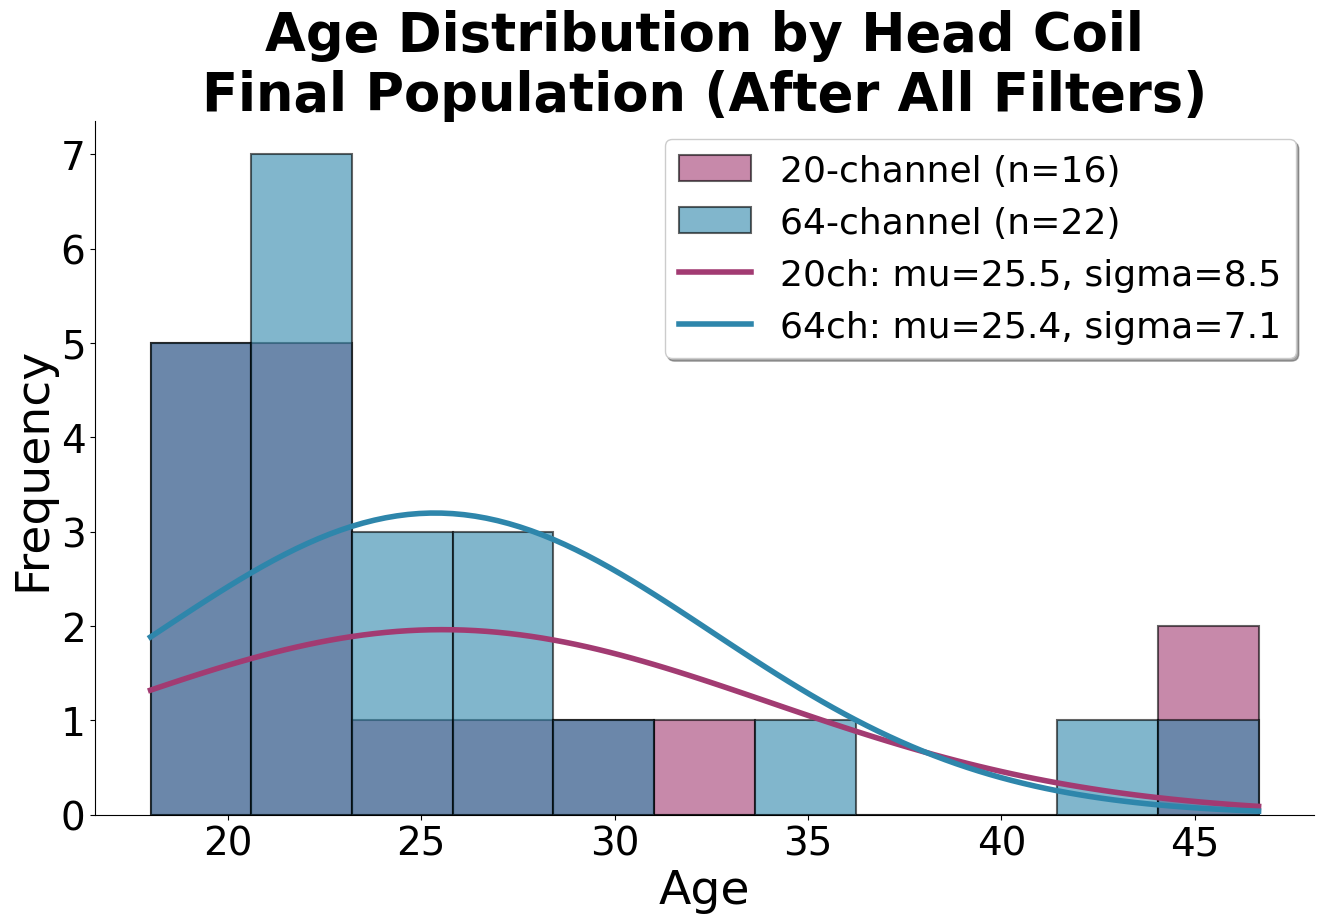


=== DATAFRAMES READY FOR NEXT STEPS ===
main_df_final: 38 subjects (filtered main population)
sp_df: 14 subjects (SP population for later use)


In [5]:
# =============================================================================
# SUBJECT DEMOGRAPHICS & DATA QUALITY FILTERING
# =============================================================================
# Produces: main_df_final, sp_df
# Dependencies: project_root (from Setup cell)

demographics_path = project_root / 'code' / 'multiecho-pilot_Demographics.xlsx'
outlier_path = project_root / 'derivatives' / 'Task-sharedreward_Level-Acq_Outlier-info_mriqc-0.16.1.tsv'

# Read the demographics Excel file
print(f"Loading demographics from: {demographics_path}")
df = pd.read_excel(demographics_path)

# Separate data based on spSubs column
sp_df = df[df['spSubs'] == 1].copy()
main_df = df[df['spSubs'] == 0].copy()

print(f"\nInitial separation:")
print(f"- SP subjects (spSubs=1): {len(sp_df)} subjects")
print(f"- Main subjects (spSubs=0): {len(main_df)} subjects")

# Print initial statistics for main population
print("\n=== MAIN POPULATION (spSubs=0) - ALL SUBJECTS ===")
print(f"Total N: {len(main_df)}")
print(f"Age: Mean = {main_df['Age'].mean():.1f}, SD = {main_df['Age'].std():.1f}")

# Filter 1: Remove subjects with SixRuns = 0
main_df_filtered = main_df[main_df['SixRuns'] != 0].copy()
subjects_removed_sixruns = len(main_df) - len(main_df_filtered)

print("\n=== AFTER REMOVING SixRuns=0 ===")
print(f"Removed {subjects_removed_sixruns} subjects")
print(f"Total N: {len(main_df_filtered)}")
print(f"Age: Mean = {main_df_filtered['Age'].mean():.1f}, SD = {main_df_filtered['Age'].std():.1f}")

# Filter 2: Remove subjects with motion outliers
print("\n=== MOTION OUTLIER ANALYSIS ===")
print(f"Loading outlier data from: {outlier_path}")

outlier_df = pd.read_csv(outlier_path, sep='\t')
print(f"Successfully loaded {len(outlier_df)} rows")

outlier_runs = outlier_df[outlier_df['outlier_acq_Custom1'] == True]
print(f"\nTotal outlier runs identified: {len(outlier_runs)}")

if len(outlier_runs) > 0:
    outlier_subjects_raw = outlier_runs['Sub'].unique()
    print(f"Unique subjects with outlier runs: {len(outlier_subjects_raw)}")

    outlier_subjects_clean = []
    for sub in outlier_subjects_raw:
        if sub.startswith('sub-'):
            clean_id = sub.replace('sub-', '')
            outlier_subjects_clean.append(clean_id)

    print(f"Outlier subjects (cleaned IDs): {sorted(outlier_subjects_clean)}")

    main_df_filtered['Subject_str'] = main_df_filtered['Subject'].astype(str)
    main_df_final = main_df_filtered[~main_df_filtered['Subject_str'].isin(outlier_subjects_clean)].copy()
    main_df_final = main_df_final.drop(columns=['Subject_str'])
    subjects_removed_outliers = len(main_df_filtered) - len(main_df_final)
    print(f"Removed {subjects_removed_outliers} subjects due to motion outliers")
else:
    print("No outlier runs found.")
    main_df_final = main_df_filtered.copy()
    subjects_removed_outliers = 0

# Print final statistics
print("\n=== FINAL POPULATION (After All Filters) ===")
print(f"Total N: {len(main_df_final)}")
print(f"Age: Mean = {main_df_final['Age'].mean():.1f}, SD = {main_df_final['Age'].std():.1f}")

if 'Gender' in main_df_final.columns:
    gender_counts = main_df_final['Gender'].value_counts()
    print(f"Gender breakdown:")
    for gender_type, count in gender_counts.items():
        print(f"- {gender_type}: {count}")
else:
    print("Warning: 'Gender' column not found in the final dataset.")

print(f"\nBreakdown by Headcoil:")
headcoil_counts = main_df_final['Headcoil'].value_counts().sort_index()
for headcoil, count in headcoil_counts.items():
    headcoil_ages = main_df_final[main_df_final['Headcoil'] == headcoil]['Age']
    print(f"- Headcoil {headcoil}: N = {count}, Age: Mean = {headcoil_ages.mean():.1f}, SD = {headcoil_ages.std():.1f}")

# Summary of filtering
print("\n=== FILTERING SUMMARY ===")
print(f"Initial main subjects: {len(main_df)}")
print(f"Removed due to SixRuns=0: {subjects_removed_sixruns}")
print(f"Removed due to motion outliers: {subjects_removed_outliers}")
print(f"Final sample size: {len(main_df_final)}")

# Age distribution histogram by headcoil
plt.rcParams.update({'font.size': 32})
fig, ax = plt.subplots(figsize=(14, 10))

hc_20 = main_df_final[main_df_final['Headcoil'] == 20]['Age']
hc_64 = main_df_final[main_df_final['Headcoil'] == 64]['Age']

color_64 = '#2E86AB'
color_20 = '#A23B72'

all_ages = main_df_final['Age']
bins = np.linspace(all_ages.min(), all_ages.max(), 12)

ax.hist(hc_20, bins=bins, alpha=0.6, color=color_20, edgecolor='black', linewidth=1.5,
        label=f'20-channel (n={len(hc_20)})')
ax.hist(hc_64, bins=bins, alpha=0.6, color=color_64, edgecolor='black', linewidth=1.5,
        label=f'64-channel (n={len(hc_64)})')

# Normal distribution fits
mu_20, sigma_20 = stats.norm.fit(hc_20)
x = np.linspace(all_ages.min(), all_ages.max(), 100)
y_20 = stats.norm.pdf(x, mu_20, sigma_20) * len(hc_20) * (bins[1] - bins[0])
ax.plot(x, y_20, color=color_20, linewidth=4, linestyle='-',
        label=f'20ch: mu={mu_20:.1f}, sigma={sigma_20:.1f}')

mu_64, sigma_64 = stats.norm.fit(hc_64)
y_64 = stats.norm.pdf(x, mu_64, sigma_64) * len(hc_64) * (bins[1] - bins[0])
ax.plot(x, y_64, color=color_64, linewidth=4, linestyle='-',
        label=f'64ch: mu={mu_64:.1f}, sigma={sigma_64:.1f}')

ax.set_xlabel('Age', fontsize=34)
ax.set_ylabel('Frequency', fontsize=34)
ax.set_title('Age Distribution by Head Coil\nFinal Population (After All Filters)', fontsize=38, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=28)
ax.legend(fontsize=26, loc='upper right', frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / 'age_distribution_by_headcoil.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== DATAFRAMES READY FOR NEXT STEPS ===")
print(f"main_df_final: {len(main_df_final)} subjects (filtered main population)")
print(f"sp_df: {len(sp_df)} subjects (SP population for later use)")

# Load Shared Data Dependencies

Derive subject lists from demographics and load smoothness data.
These are used by all subsequent ROI analyses.

In [7]:
# Derive valid_subjects and headcoil_mapping from demographics
valid_subjects = main_df_final['Subject'].astype(str).tolist()
headcoil_mapping = dict(zip(main_df_final['Subject'].astype(str),
                           main_df_final['Headcoil'].astype(int).astype(str)))

print(f"Valid subjects: {len(valid_subjects)}")

# Load smoothness data (shared across all ROI analyses)
smoothness_data = load_smoothness_data(smoothness_path, valid_subjects, headcoil_mapping)
if smoothness_data is None:
    raise Exception("Failed to load smoothness data")

complete_smoothness = identify_complete_subjects(smoothness_data, 'smoothness')
print(f"Complete smoothness subjects: {len(complete_smoothness)}")


Valid subjects: 38
Complete smoothness subjects: 38


# Spatial Smoothness Analysis (Fig. 3)
LME analysis of pre- and post-smoothing spatial smoothness across acquisition parameters. 2×2 bar plot output.

SMOOTHNESS ANALYSIS PIPELINE - PRE AND POST SMOOTHING

PRE-SMOOTHING DATA ANALYSIS

Pre-smoothing complete subjects: 38
  - 20-channel: 16
  - 64-channel: 22
Saved to 'complete_subjects_smoothness_pre_with_headcoil.csv'

Running LME analysis for Pre-smoothing data
Observations: 228, Subjects: 38
Linear mixed model fit by REML [’lmerMod’]
Formula: smoothness~headcoil*mb*me+(1|subject)

Family: gaussian	 Inference: parametric

Number of observations: 228	 Groups: {'subject': 38.0}

Log-likelihood: 266.879 	 AIC: -505.759

Random effects:

                 Name    Var    Std
subject   (Intercept)  0.024  0.155
Residual               0.002  0.045

No random effect correlations specified

Fixed effects:

SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)

APA-Style ANOVA Table for Pre-smoothing Data:
                            Effect  Sum Sq  Mean Sq  Num df  Den df       F      p  

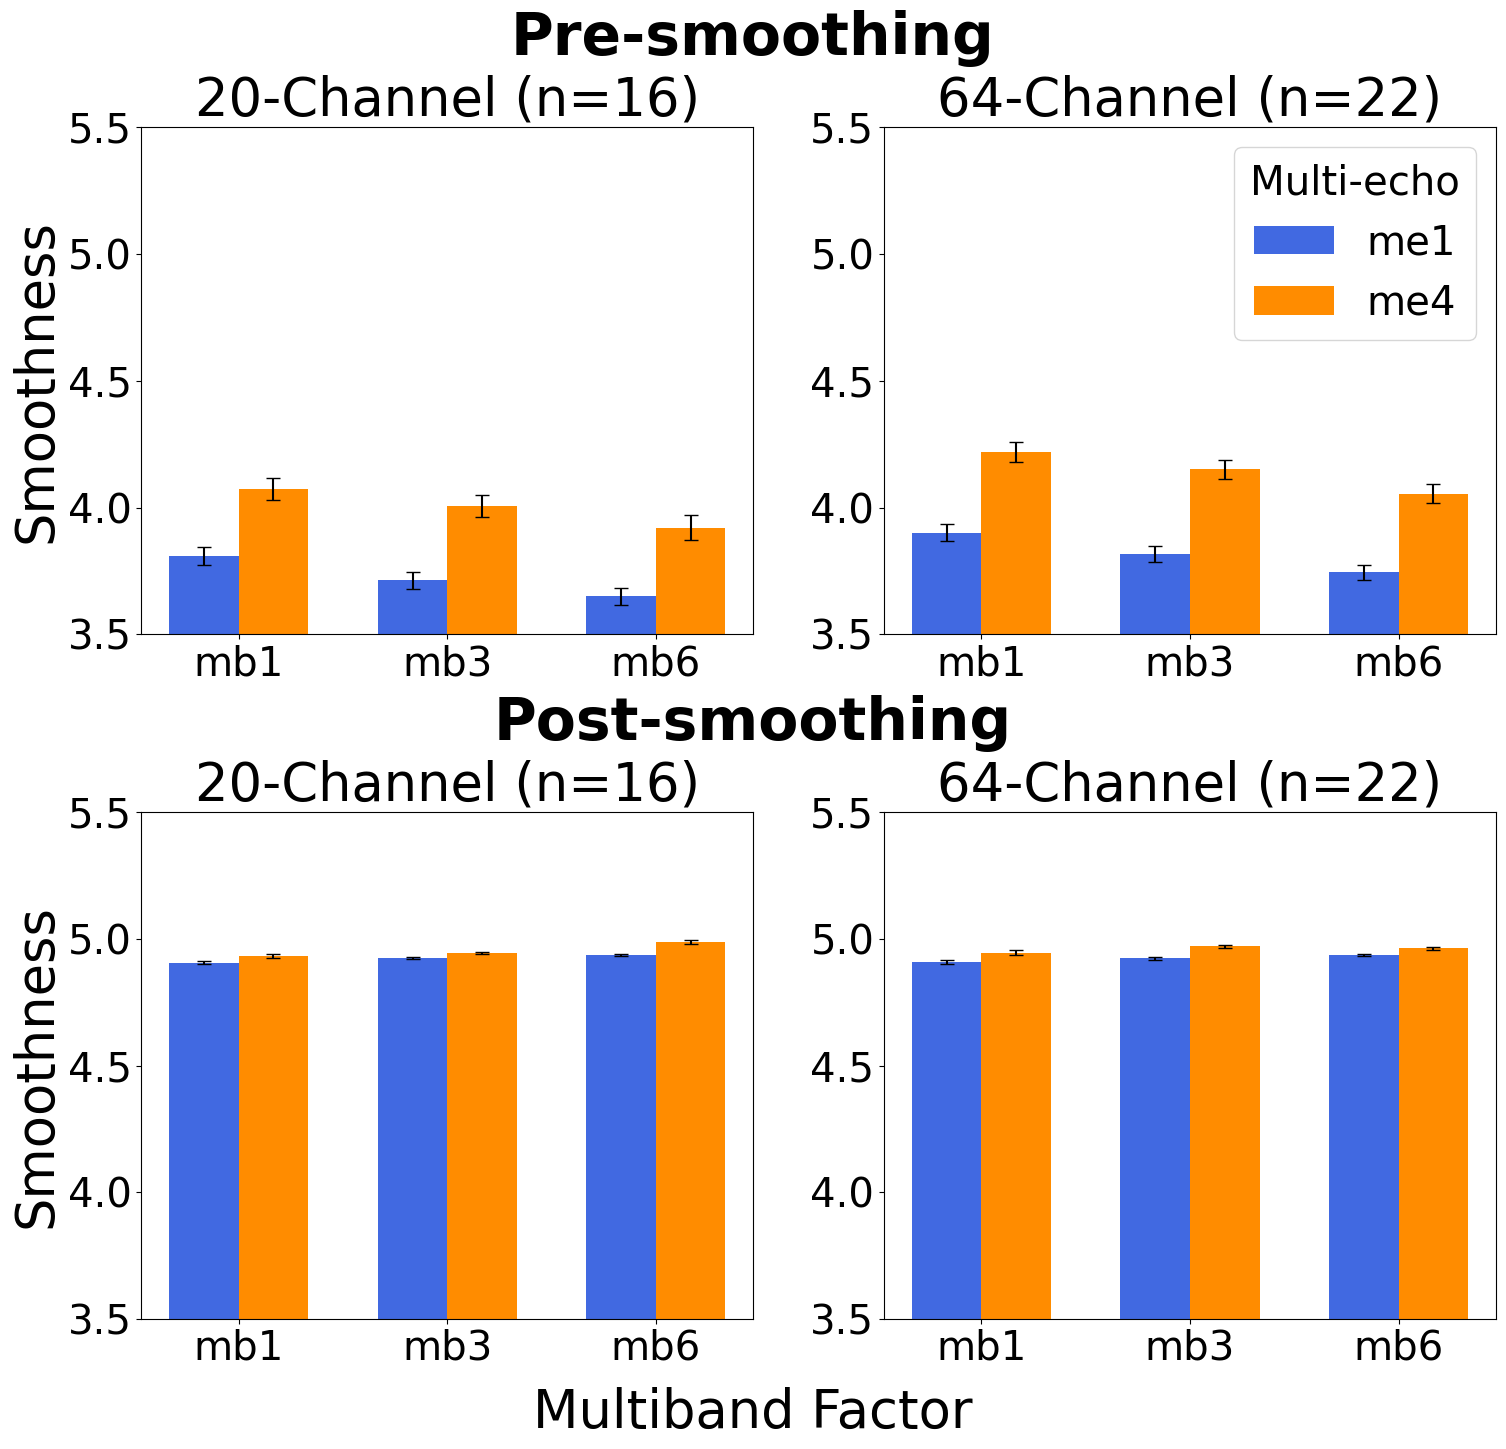


ANALYSIS COMPLETE - SUMMARY

Pre-smoothing: 38 complete subjects (16 20-ch, 22 64-ch)
Post-smoothing: 38 complete subjects (16 20-ch, 22 64-ch)

Files generated in /Users/jameswyngaarden/Documents/GitHub/multiecho-pilot/derivatives/plots:
  - complete_subjects_smoothness_pre_with_headcoil.csv
  - complete_subjects_smoothness_post_with_headcoil.csv
  - smoothness_pre_lme_anova_complete_subjects.csv
  - smoothness_post_lme_anova_complete_subjects.csv
  - smoothness_combined_bar_plot.png


In [9]:
# =============================================================================
# SPATIAL SMOOTHNESS ANALYSIS — PRE AND POST SMOOTHING (Fig. 3)
# =============================================================================
# Dependencies: project_root, output_dir, valid_subjects, headcoil_mapping,
#               load_smoothness_data, identify_complete_subjects (from Setup)
#
# NOTE: This analysis uses sum-to-zero headcoil encoding (20ch=-0.5, 64ch=0.5)
# and a different partial eta-squared formula than the activation analyses.
# These are intentional modeling choices for the smoothness DV.

print("=" * 80)
print("SMOOTHNESS ANALYSIS PIPELINE - PRE AND POST SMOOTHING")
print("=" * 80)

# --- Paths ---
csv_path_pre = project_root / 'code' / 'smoothness-all-zero.csv'
csv_path_post = project_root / 'code' / 'smoothness-all.csv'

# --- Output files ---
complete_subjects_file_pre = output_dir / 'complete_subjects_smoothness_pre_with_headcoil.csv'
complete_subjects_file_post = output_dir / 'complete_subjects_smoothness_post_with_headcoil.csv'
anova_table_file_pre = output_dir / 'smoothness_pre_lme_anova_complete_subjects.csv'
anova_table_file_post = output_dir / 'smoothness_post_lme_anova_complete_subjects.csv'
combined_plot_file = output_dir / 'smoothness_combined_bar_plot.png'

# =============================================================================
# LOCAL FUNCTIONS (unique to this analysis)
# =============================================================================

def run_smoothness_lme(data_complete, label):
    """
    Run LME for smoothness with sum-to-zero headcoil coding.
    Uses a different eta-squared formula than the activation analyses.
    """
    print(f"\nRunning LME analysis for {label} data")
    print(f"Observations: {len(data_complete)}, Subjects: {data_complete['subject'].nunique()}")

    model_data = data_complete.copy()
    model_data['headcoil'] = model_data['headcoil'].cat.codes - 0.5  # 20=-0.5, 64=0.5

    model = Lmer('smoothness ~ headcoil * mb * me + (1 | subject)', data=model_data)
    model.fit()
    anova_table = model.anova()

    effect_map = {
        'headcoil': 'Head Coil', 'mb': 'Multiband', 'me': 'Multi-echo',
        'headcoil:mb': 'Head Coil x Multiband', 'headcoil:me': 'Head Coil x Multi-echo',
        'mb:me': 'Multiband x Multi-echo', 'headcoil:mb:me': 'Head Coil x Multiband x Multi-echo'
    }
    df_dict = {
        'Head Coil': 1, 'Multiband': 2, 'Multi-echo': 1,
        'Head Coil x Multiband': 2, 'Head Coil x Multi-echo': 1,
        'Multiband x Multi-echo': 2, 'Head Coil x Multiband x Multi-echo': 2
    }

    apa_data = []
    for effect in anova_table.index:
        if effect in ['(Intercept)', 'Residuals']:
            continue
        effect_name = effect_map.get(effect, effect)
        apa_data.append({
            'Effect': effect_name,
            'Sum Sq': anova_table.loc[effect, 'SS'] if 'SS' in anova_table.columns else np.nan,
            'Mean Sq': anova_table.loc[effect, 'MS'] if 'MS' in anova_table.columns else np.nan,
            'Num df': df_dict.get(effect_name, np.nan),
            'Den df': anova_table.loc[effect, 'DenomDF'] if 'DenomDF' in anova_table.columns else np.nan,
            'F': anova_table.loc[effect, 'F-stat'] if 'F-stat' in anova_table.columns else np.nan,
            'p': anova_table.loc[effect, 'P-val'] if 'P-val' in anova_table.columns else np.nan,
            'Partial eta_sq': np.nan
        })

    # Partial eta-squared (smoothness formula: uses total residual SS)
    try:
        residual_var = model.ranef_var.loc[model.ranef_var['Name'] == '', 'Var'].iloc[0]
    except (KeyError, IndexError):
        residual_var = model.ranef_var.iloc[1]['Var']

    n_obs = len(model_data)
    n_fixed = sum(df_dict.values())
    n_subj = model_data['subject'].nunique()
    ss_residual = residual_var * (n_obs - n_fixed - n_subj)

    for i, row in enumerate(apa_data):
        ss_effect = row['Sum Sq']
        if pd.notna(ss_effect):
            apa_data[i]['Partial eta_sq'] = ss_effect / (ss_effect + ss_residual)

    apa_table = pd.DataFrame(apa_data)
    apa_table['Sum Sq'] = apa_table['Sum Sq'].round(2)
    apa_table['Mean Sq'] = apa_table['Mean Sq'].round(2)
    apa_table['Num df'] = apa_table['Num df'].astype('Int64').fillna(pd.NA)
    apa_table['Den df'] = apa_table['Den df'].round(2)
    apa_table['F'] = apa_table['F'].round(2)
    apa_table['p'] = apa_table['p'].apply(
        lambda x: '< .001' if pd.notna(x) and x < 0.001 else f'{x:.3f}' if pd.notna(x) else 'N/A'
    )
    apa_table['Partial eta_sq'] = apa_table['Partial eta_sq'].round(3)
    return apa_table


def process_data_for_plotting(data, value_column='smoothness'):
    """Calculate mean and standard error by multiband, multi-echo, and headcoil."""
    if data is None or data.empty:
        return pd.DataFrame()
    data = data.dropna(subset=['mb', 'me', 'headcoil', value_column])
    if data.empty:
        return pd.DataFrame()

    agg_data = data.groupby(['mb', 'me', 'headcoil'], observed=True).agg({
        value_column: 'mean', 'subject': 'nunique'
    }).reset_index()

    std_error = data.groupby(['mb', 'me', 'headcoil'], observed=True)[value_column].apply(
        lambda x: x.std() / np.sqrt(len(x))
    ).reset_index()
    std_error.columns = ['mb', 'me', 'headcoil', 'se']

    result = pd.merge(agg_data, std_error, on=['mb', 'me', 'headcoil'])
    result.columns = ['mb', 'me', 'headcoil', value_column, 'n_subjects', 'se']
    return result


def build_complete_subjects_table(data, complete_list, headcoil_mapping):
    """Build a complete-subjects pivot table with headcoil info for CSV output."""
    expected_cols = ['mb1me1', 'mb3me1', 'mb6me1', 'mb1me4', 'mb3me4', 'mb6me4']
    data_c = data[data['subject'].isin(complete_list)].copy()
    data_c['mb_me'] = data_c['mb'].astype(str) + data_c['me'].astype(str)

    pivot = data_c.pivot_table(values='smoothness', index='subject',
                                columns='mb_me', aggfunc='mean'
                                ).reindex(columns=expected_cols).round(3)

    hc_info = data_c[['subject', 'headcoil']].drop_duplicates().set_index('subject')
    pivot = pivot.join(hc_info)
    pivot = pivot[['headcoil'] + expected_cols]
    return pivot.sort_index()


def plot_smoothness_data(ax, data_processed, n_subjects_per_coil, headcoil, y_limits):
    """Plot smoothness bar chart for a specific headcoil."""
    width = 0.4
    x1 = [0, 1.2, 2.4]
    x2 = [x + width for x in x1]
    mb_levels = ['mb1', 'mb3', 'mb6']

    coil_data = data_processed[data_processed['headcoil'] == headcoil]
    if coil_data.empty:
        ax.set_title(f"{headcoil}-Channel (n=0)", fontsize=38)
        ax.set_ylim(y_limits)
        return

    me1_data = coil_data[coil_data['me'] == 'me1']
    me4_data = coil_data[coil_data['me'] == 'me4']

    me1_means = me1_data.set_index('mb')['smoothness'].reindex(mb_levels).fillna(0)
    me1_errors = me1_data.set_index('mb')['se'].reindex(mb_levels).fillna(0)
    me4_means = me4_data.set_index('mb')['smoothness'].reindex(mb_levels).fillna(0)
    me4_errors = me4_data.set_index('mb')['se'].reindex(mb_levels).fillna(0)

    ax.bar(x1, me1_means, width, color=ME_COLORS['me1'], label='me1', yerr=me1_errors, capsize=5)
    ax.bar(x2, me4_means, width, color=ME_COLORS['me4'], label='me4', yerr=me4_errors, capsize=5)

    ax.set_xticks([width/2, 1.2+width/2, 2.4+width/2])
    ax.set_xticklabels(mb_levels)
    ax.tick_params(axis='both', which='major', labelsize=29)

    n_subjects = n_subjects_per_coil.get(headcoil, 0)
    ax.set_title(f"{headcoil}-Channel (n={n_subjects})", fontsize=38)
    ax.set_ylim(y_limits)


# =============================================================================
# HELPER: process one smoothness dataset (pre or post)
# =============================================================================

def process_smoothness_dataset(csv_path, label, complete_subjects_file, anova_file):
    """Load, filter, save table, run LME for one smoothness dataset."""
    print(f"\n{'=' * 80}")
    print(f"{label.upper()} DATA ANALYSIS")
    print(f"{'=' * 80}")

    # Reuse shared loader (same CSV format for pre and post)
    data = load_smoothness_data(csv_path, valid_subjects, headcoil_mapping)
    if data is None:
        raise Exception(f"Failed to load {label} data from {csv_path}")

    # Identify complete subjects (shared function returns a list)
    complete_list = identify_complete_subjects(data, 'smoothness')

    # Build and save complete-subjects table
    table = build_complete_subjects_table(data, complete_list, headcoil_mapping)
    hc_counts = table['headcoil'].value_counts().reindex(['20', '64'], fill_value=0)

    print(f"\n{label} complete subjects: {len(table)}")
    print(f"  - 20-channel: {hc_counts['20']}")
    print(f"  - 64-channel: {hc_counts['64']}")

    table.to_csv(complete_subjects_file)
    print(f"Saved to '{complete_subjects_file.name}'")

    # Filter to complete subjects
    data_complete = data[data['subject'].isin(complete_list)]

    # Run LME
    apa_table = run_smoothness_lme(data_complete, label)
    print(f"\nAPA-Style ANOVA Table for {label} Data:")
    print(apa_table.to_string(index=False))
    apa_table.to_csv(anova_file, index=False)

    return data_complete, table, hc_counts


# =============================================================================
# PART 1 & 2: PROCESS PRE AND POST SMOOTHING DATA
# =============================================================================

data_complete_pre, table_pre, hc_pre = process_smoothness_dataset(
    csv_path_pre, "Pre-smoothing", complete_subjects_file_pre, anova_table_file_pre
)
data_complete_post, table_post, hc_post = process_smoothness_dataset(
    csv_path_post, "Post-smoothing", complete_subjects_file_post, anova_table_file_post
)

# =============================================================================
# PART 3: COMBINED VISUALIZATION
# =============================================================================

print(f"\n{'=' * 80}")
print("PART 3: GENERATING COMBINED BAR PLOTS")
print(f"{'=' * 80}")

smoothness_processed_pre = process_data_for_plotting(data_complete_pre)
smoothness_processed_post = process_data_for_plotting(data_complete_post)

n_per_coil_pre = data_complete_pre.groupby('headcoil', observed=True)['subject'].nunique().to_dict()
n_per_coil_post = data_complete_post.groupby('headcoil', observed=True)['subject'].nunique().to_dict()

plt.rcParams.update({'font.size': 38})
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

y_limits = (3.5, 5.5)

# Top row: Pre-smoothing
plot_smoothness_data(axes[0, 0], smoothness_processed_pre, n_per_coil_pre, '20', y_limits)
plot_smoothness_data(axes[0, 1], smoothness_processed_pre, n_per_coil_pre, '64', y_limits)

# Bottom row: Post-smoothing
plot_smoothness_data(axes[1, 0], smoothness_processed_post, n_per_coil_post, '20', y_limits)
plot_smoothness_data(axes[1, 1], smoothness_processed_post, n_per_coil_post, '64', y_limits)

axes[0, 0].set_ylabel('Smoothness', fontsize=38)
axes[1, 0].set_ylabel('Smoothness', fontsize=38)
axes[0, 1].legend(title='Multi-echo', fontsize=29, title_fontsize=29, loc='upper right')
fig.supxlabel('Multiband Factor', fontsize=38, y=0.06)

plt.tight_layout()
fig.subplots_adjust(top=0.88, hspace=0.35)

row_labels = ['Pre-smoothing', 'Post-smoothing']
for row_idx in range(2):
    bbox = axes[row_idx, 0].get_position()
    fig.text(0.5, bbox.y1 + 0.045, row_labels[row_idx],
             ha='center', fontsize=42, fontweight='bold', transform=fig.transFigure)

plt.savefig(combined_plot_file, dpi=300, bbox_inches='tight')
print(f"Combined plot saved to '{combined_plot_file}'")
plt.show()

# =============================================================================
# SUMMARY
# =============================================================================

print(f"\n{'=' * 80}")
print("ANALYSIS COMPLETE - SUMMARY")
print(f"{'=' * 80}")
print(f"\nPre-smoothing: {len(table_pre)} complete subjects "
      f"({hc_pre['20']} 20-ch, {hc_pre['64']} 64-ch)")
print(f"Post-smoothing: {len(table_post)} complete subjects "
      f"({hc_post['20']} 20-ch, {hc_post['64']} 64-ch)")
print(f"\nFiles generated in {output_dir}:")
for f in [complete_subjects_file_pre, complete_subjects_file_post,
          anova_table_file_pre, anova_table_file_post, combined_plot_file]:
    print(f"  - {f.name}")
print("=" * 80)

# Whole-Brain TSNR Analysis (Fig. 4)
LME analysis of median TSNR with smoothness covariate. Bar plot by MB factor, headcoil, and ME condition.

TSNR ANALYSIS PIPELINE WITH SMOOTHNESS COVARIATE

PART 1: IDENTIFYING COMMON COMPLETE SUBJECTS
Complete TSNR subjects: 38
Complete smoothness subjects: 38

Common complete subjects: 38

Final dataset: 38 subjects, 228 observations
  20-channel: 16
  64-channel: 22

Complete subjects table saved to 'complete_subjects_tsnr_common_with_headcoil.csv'

PART 2: LINEAR MIXED EFFECTS ANALYSIS
Linear mixed model fit by REML [’lmerMod’]
Formula: tsnrMedian~headcoil_encoded*mb*me+smoothness+(1|subject)

Family: gaussian	 Inference: parametric

Number of observations: 228	 Groups: {'subject': 38.0}

Log-likelihood: -582.411 	 AIC: 1194.821

Random effects:

                 Name    Var    Std
subject   (Intercept)  9.767  3.125
Residual               7.918  2.814

No random effect correlations specified

Fixed effects:

SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)

APA-Style ANOVA Tab

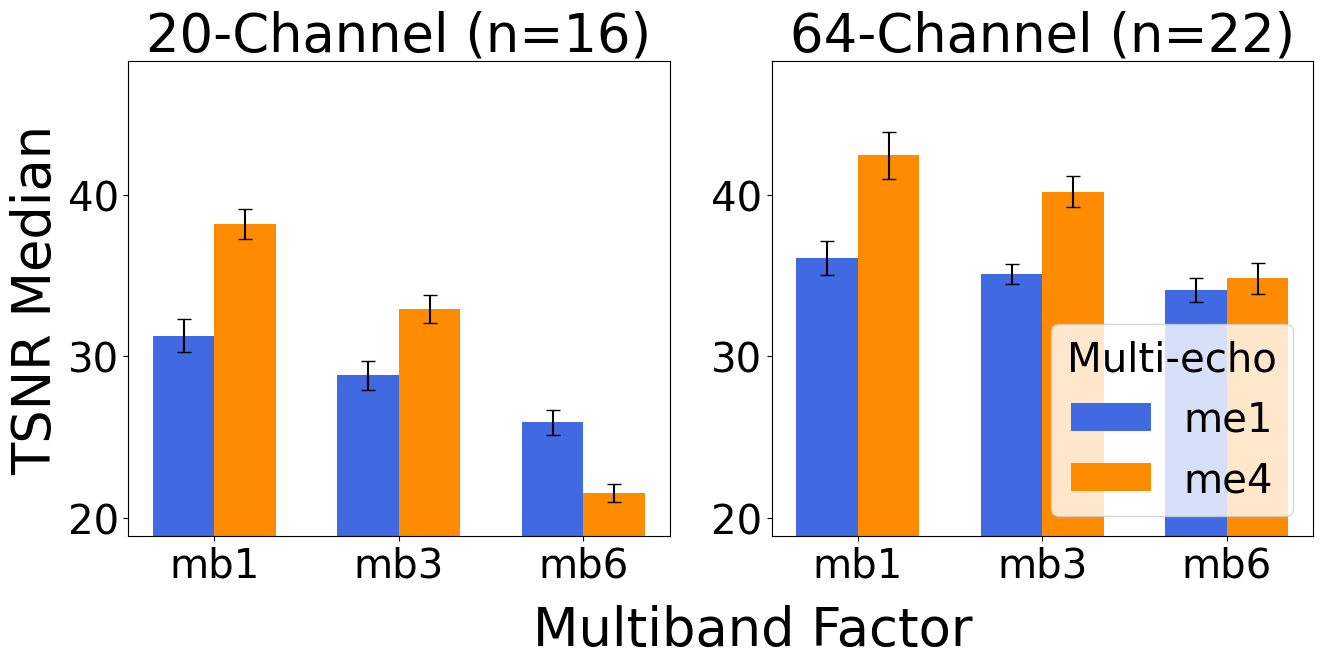


ANALYSIS COMPLETE - SUMMARY
Common complete subjects: 38
  - 20-channel: 16
  - 64-channel: 22

Files: complete_subjects_tsnr_common_with_headcoil.csv, tsnr_lme_anova_with_smoothness.csv, tsnr_bar_plot_median.png


In [11]:
# =============================================================================
# WHOLE-BRAIN TSNR ANALYSIS WITH SMOOTHNESS COVARIATE (Fig. 4)
# =============================================================================
# Dependencies: project_root, output_dir, valid_subjects, headcoil_mapping,
#               smoothness_data, complete_smoothness (from Shared Deps cell),
#               load_smoothness_data, identify_complete_subjects, ME_COLORS (from Setup)
#
# NOTE: Uses sum-to-zero headcoil encoding and residual-SS-based eta-squared,
# same as the smoothness analysis (different from activation analyses).

print("=" * 80)
print("TSNR ANALYSIS PIPELINE WITH SMOOTHNESS COVARIATE")
print("=" * 80)

# --- Paths & output files ---
tsnr_path = project_root / 'code' / 'outputs' / 'tables' / 'combined_tsnr_coil_output.csv'
complete_subjects_file = output_dir / 'complete_subjects_tsnr_common_with_headcoil.csv'
anova_table_file = output_dir / 'tsnr_lme_anova_with_smoothness.csv'
tsnr_plot_file = output_dir / 'tsnr_bar_plot_median.png'

# =============================================================================
# LOCAL FUNCTION: TSNR data loading (unique CSV format)
# =============================================================================

def load_and_process_tsnr_data(csv_path, valid_subjects, headcoil_mapping):
    """Load whole-brain TSNR data from combined_tsnr_coil_output.csv."""
    try:
        data = pd.read_csv(csv_path)
        data['Subject'] = data['Subject'].astype(str)
        data['AcquisitionType'] = data['AcquisitionType'].astype(str)
        data = data[data['Subject'].isin(valid_subjects)]

        data['mb'] = data['AcquisitionType'].str.extract(r'(mb\d)')
        data['me'] = data['AcquisitionType'].str.extract(r'(me\d)')
        data['headcoil'] = data['Subject'].map(headcoil_mapping).str.replace('.0', '', regex=False)
        data = data.rename(columns={'Subject': 'subject'})
        data['acq_combined'] = data['mb'].astype(str) + data['me'].astype(str)

        data = data[['subject', 'headcoil', 'mb', 'me', 'acq_combined', 'tsnrMean', 'tsnrMedian']]
        data['headcoil'] = pd.Categorical(data['headcoil'], categories=['20', '64'])
        data['mb'] = pd.Categorical(data['mb'], categories=['mb1', 'mb3', 'mb6'])
        data['me'] = pd.Categorical(data['me'], categories=['me1', 'me4'])
        data = data.dropna()
        return data

    except Exception as e:
        print(f"Error processing TSNR data: {str(e)}")
        return None


# =============================================================================
# PART 1: LOAD DATA AND IDENTIFY COMMON COMPLETE SUBJECTS
# =============================================================================

print("\n" + "=" * 80)
print("PART 1: IDENTIFYING COMMON COMPLETE SUBJECTS")
print("=" * 80)

tsnr_data = load_and_process_tsnr_data(tsnr_path, valid_subjects, headcoil_mapping)
if tsnr_data is None:
    raise Exception("Failed to load TSNR data")

# Use shared identify_complete_subjects
complete_tsnr = identify_complete_subjects(tsnr_data, 'tsnrMedian')
# complete_smoothness already available from Shared Deps cell

print(f"Complete TSNR subjects: {len(complete_tsnr)}")
print(f"Complete smoothness subjects: {len(complete_smoothness)}")

common_complete = sorted(list(set(complete_tsnr) & set(complete_smoothness)))
print(f"\nCommon complete subjects: {len(common_complete)}")

if not common_complete:
    raise Exception("No common complete subjects found")

# Filter and merge
tsnr_filtered = tsnr_data[tsnr_data['subject'].isin(common_complete)].copy()
smoothness_filtered = smoothness_data[smoothness_data['subject'].isin(common_complete)].copy()

merged_data = pd.merge(
    tsnr_filtered[['subject', 'headcoil', 'mb', 'me', 'tsnrMedian']],
    smoothness_filtered[['subject', 'mb', 'me', 'smoothness']],
    on=['subject', 'mb', 'me'], how='inner'
).dropna()

total_n = merged_data['subject'].nunique()
headcoil_counts = merged_data[['subject', 'headcoil']].drop_duplicates()['headcoil'].value_counts()

print(f"\nFinal dataset: {total_n} subjects, {len(merged_data)} observations")
print(f"  20-channel: {headcoil_counts.get('20', 0)}")
print(f"  64-channel: {headcoil_counts.get('64', 0)}")

# Save complete subjects table
tsnr_complete_table = tsnr_filtered.pivot_table(
    values='tsnrMean', index='subject', columns='acq_combined', aggfunc='mean'
).round(3)
hc_info = tsnr_filtered[['subject', 'headcoil']].drop_duplicates().set_index('subject')
tsnr_complete_table = pd.concat([hc_info, tsnr_complete_table], axis=1)
tsnr_complete_table.to_csv(complete_subjects_file)
print(f"\nComplete subjects table saved to '{complete_subjects_file.name}'")

# =============================================================================
# PART 2: LINEAR MIXED EFFECTS ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print("PART 2: LINEAR MIXED EFFECTS ANALYSIS")
print("=" * 80)

# Sum-to-zero headcoil encoding (same approach as smoothness analysis)
model_data = merged_data.copy()
model_data['headcoil_encoded'] = model_data['headcoil'].cat.codes - 0.5

model = Lmer('tsnrMedian ~ headcoil_encoded * mb * me + smoothness + (1 | subject)',
             data=model_data)
model.fit()
anova_results = model.anova()

# APA table with effect names matching the encoded variable
effect_names = {
    'headcoil_encoded': 'Head Coil', 'mb': 'Multiband', 'me': 'Multi-echo',
    'smoothness': 'Smoothness',
    'headcoil_encoded:mb': 'Head Coil x Multiband', 'headcoil_encoded:me': 'Head Coil x Multi-echo',
    'mb:me': 'Multiband x Multi-echo', 'headcoil_encoded:mb:me': 'Head Coil x Multiband x Multi-echo'
}
df_dict = {
    'Head Coil': 1, 'Multiband': 2, 'Multi-echo': 1, 'Smoothness': 1,
    'Head Coil x Multiband': 2, 'Head Coil x Multi-echo': 1,
    'Multiband x Multi-echo': 2, 'Head Coil x Multiband x Multi-echo': 2
}

apa_data = []
for effect in anova_results.index:
    if effect in ['(Intercept)', 'Residuals']:
        continue
    effect_name = effect_names.get(effect, effect)
    apa_data.append({
        'Effect': effect_name,
        'Sum Sq': anova_results.loc[effect, 'SS'] if 'SS' in anova_results.columns else np.nan,
        'Mean Sq': anova_results.loc[effect, 'MS'] if 'MS' in anova_results.columns else np.nan,
        'Num df': df_dict.get(effect_name, np.nan),
        'Den df': anova_results.loc[effect, 'DenomDF'] if 'DenomDF' in anova_results.columns else np.nan,
        'F': anova_results.loc[effect, 'F-stat'] if 'F-stat' in anova_results.columns else np.nan,
        'p': anova_results.loc[effect, 'P-val'] if 'P-val' in anova_results.columns else np.nan,
        'Partial eta_sq': np.nan
    })

# Residual-SS-based eta-squared
try:
    residual_var = model.ranef_var.loc[model.ranef_var['Name'] == '', 'Var'].iloc[0]
except (KeyError, IndexError):
    residual_var = model.ranef_var.iloc[1]['Var']

ss_residual = residual_var * (len(model_data) - sum(df_dict.values()) - model_data['subject'].nunique())

for i, row in enumerate(apa_data):
    if pd.notna(row['Sum Sq']):
        apa_data[i]['Partial eta_sq'] = row['Sum Sq'] / (row['Sum Sq'] + ss_residual)

apa_table = pd.DataFrame(apa_data)
apa_table['Sum Sq'] = apa_table['Sum Sq'].round(2)
apa_table['Mean Sq'] = apa_table['Mean Sq'].round(2)
apa_table['Num df'] = apa_table['Num df'].astype('Int64').fillna(pd.NA)
apa_table['Den df'] = apa_table['Den df'].round(2)
apa_table['F'] = apa_table['F'].round(2)
apa_table['p'] = apa_table['p'].apply(
    lambda x: '< .001' if pd.notna(x) and x < 0.001 else f'{x:.3f}' if pd.notna(x) else 'N/A'
)
apa_table['Partial eta_sq'] = apa_table['Partial eta_sq'].round(3)

print(f"\nAPA-Style ANOVA Table:")
print(f"Model: tsnrMedian ~ headcoil * mb * me + smoothness + (1 | subject)")
print(f"Data: Common complete subjects (N = {total_n})\n")
print(apa_table.to_string(index=False))

apa_table.to_csv(anova_table_file, index=False)
print(f"\nSaved to '{anova_table_file.name}'")

# =============================================================================
# PART 3: VISUALIZATION
# =============================================================================

print("\n" + "=" * 80)
print("PART 3: GENERATING BAR PLOTS")
print("=" * 80)

plot_data = tsnr_filtered.groupby(['mb', 'me', 'headcoil']).agg({
    'tsnrMedian': ['mean', 'sem']
}).reset_index()
plot_data.columns = ['mb', 'me', 'headcoil', 'mean', 'sem']

plt.rcParams.update({'font.size': 38})
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

width = 0.4
x_pos = np.array([0, 1.2, 2.4])

y_max = max(plot_data['mean'].values + plot_data['sem'].values) * 1.1
y_min = min(plot_data['mean'].values - plot_data['sem'].values) * 0.9
y_limits = (max(0, y_min), y_max)

for idx, (headcoil, ax) in enumerate(zip(['20', '64'], axes)):
    hc_data = plot_data[plot_data['headcoil'] == headcoil]

    for me_level in ['me1', 'me4']:
        me_data = hc_data[hc_data['me'] == me_level]
        means, sems = [], []
        for mb in ['mb1', 'mb3', 'mb6']:
            mb_data = me_data[me_data['mb'] == mb]
            if not mb_data.empty:
                means.append(mb_data['mean'].iloc[0])
                sems.append(mb_data['sem'].iloc[0])
            else:
                means.append(0)
                sems.append(0)

        offset = -width/2 if me_level == 'me1' else width/2
        ax.bar(x_pos + offset, means, width, label=me_level,
               color=ME_COLORS[me_level], yerr=sems, capsize=5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(['mb1', 'mb3', 'mb6'])
    ax.tick_params(axis='both', which='major', labelsize=29)
    ax.set_ylim(y_limits)

    n_subj = len(tsnr_filtered[tsnr_filtered['headcoil'] == headcoil]['subject'].unique())
    ax.set_title(f'{headcoil}-Channel (n={n_subj})', fontsize=38)

    if idx == 0:
        ax.set_ylabel('TSNR Median', fontsize=38)

axes[1].legend(title='Multi-echo', fontsize=29, title_fontsize=29, loc='lower right')
fig.supxlabel('Multiband Factor', fontsize=38, y=0.12)

plt.tight_layout()
fig.subplots_adjust(right=0.85)

plt.savefig(tsnr_plot_file, dpi=300, bbox_inches='tight')
print(f"Plot saved to '{tsnr_plot_file.name}'")
plt.show()

# =============================================================================
# SUMMARY
# =============================================================================

print(f"\n{'=' * 80}")
print("ANALYSIS COMPLETE - SUMMARY")
print(f"{'=' * 80}")
print(f"Common complete subjects: {total_n}")
print(f"  - 20-channel: {headcoil_counts.get('20', 0)}")
print(f"  - 64-channel: {headcoil_counts.get('64', 0)}")
print(f"\nFiles: {complete_subjects_file.name}, {anova_table_file.name}, {tsnr_plot_file.name}")
print("=" * 80)

# ROI-Based TSNR Analysis (Fig. 5)
Per-ROI TSNR analyses (VS, rFFA, Motor) plus combined ROI comparisons. 3×2 grid and VS-vs-Motor plots.

MULTI-ROI TSNR ANALYSIS PIPELINE WITH SMOOTHNESS COVARIATE
Processing TSNR for ROIs: VSconstrained, rFFA, bilateralMotor

PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS

Processing VSconstrained...
  Complete VSconstrained subjects: 38
  Common complete subjects: 38

Processing rFFA...
  Complete rFFA subjects: 38
  Common complete subjects: 38

Processing bilateralMotor...
  Complete bilateralMotor subjects: 38
  Common complete subjects: 38

PART 2: LINEAR MIXED EFFECTS ANALYSES

=== Ventral Striatum (VSconstrained) ===
N = 38 subjects (16 20-ch, 22 64-ch)
Linear mixed model fit by REML [’lmerMod’]
Formula: tsnr~headcoil_encoded*mb*me+smoothness+(1|subject)

Family: gaussian	 Inference: parametric

Number of observations: 228	 Groups: {'subject': 38.0}

Log-likelihood: -707.507 	 AIC: 1445.014

Random effects:

                 Name     Var    Std
subject   (Intercept)  45.444  6.741
Residual               23.723  4.871

No random effect correlations specified

Fixed effects:

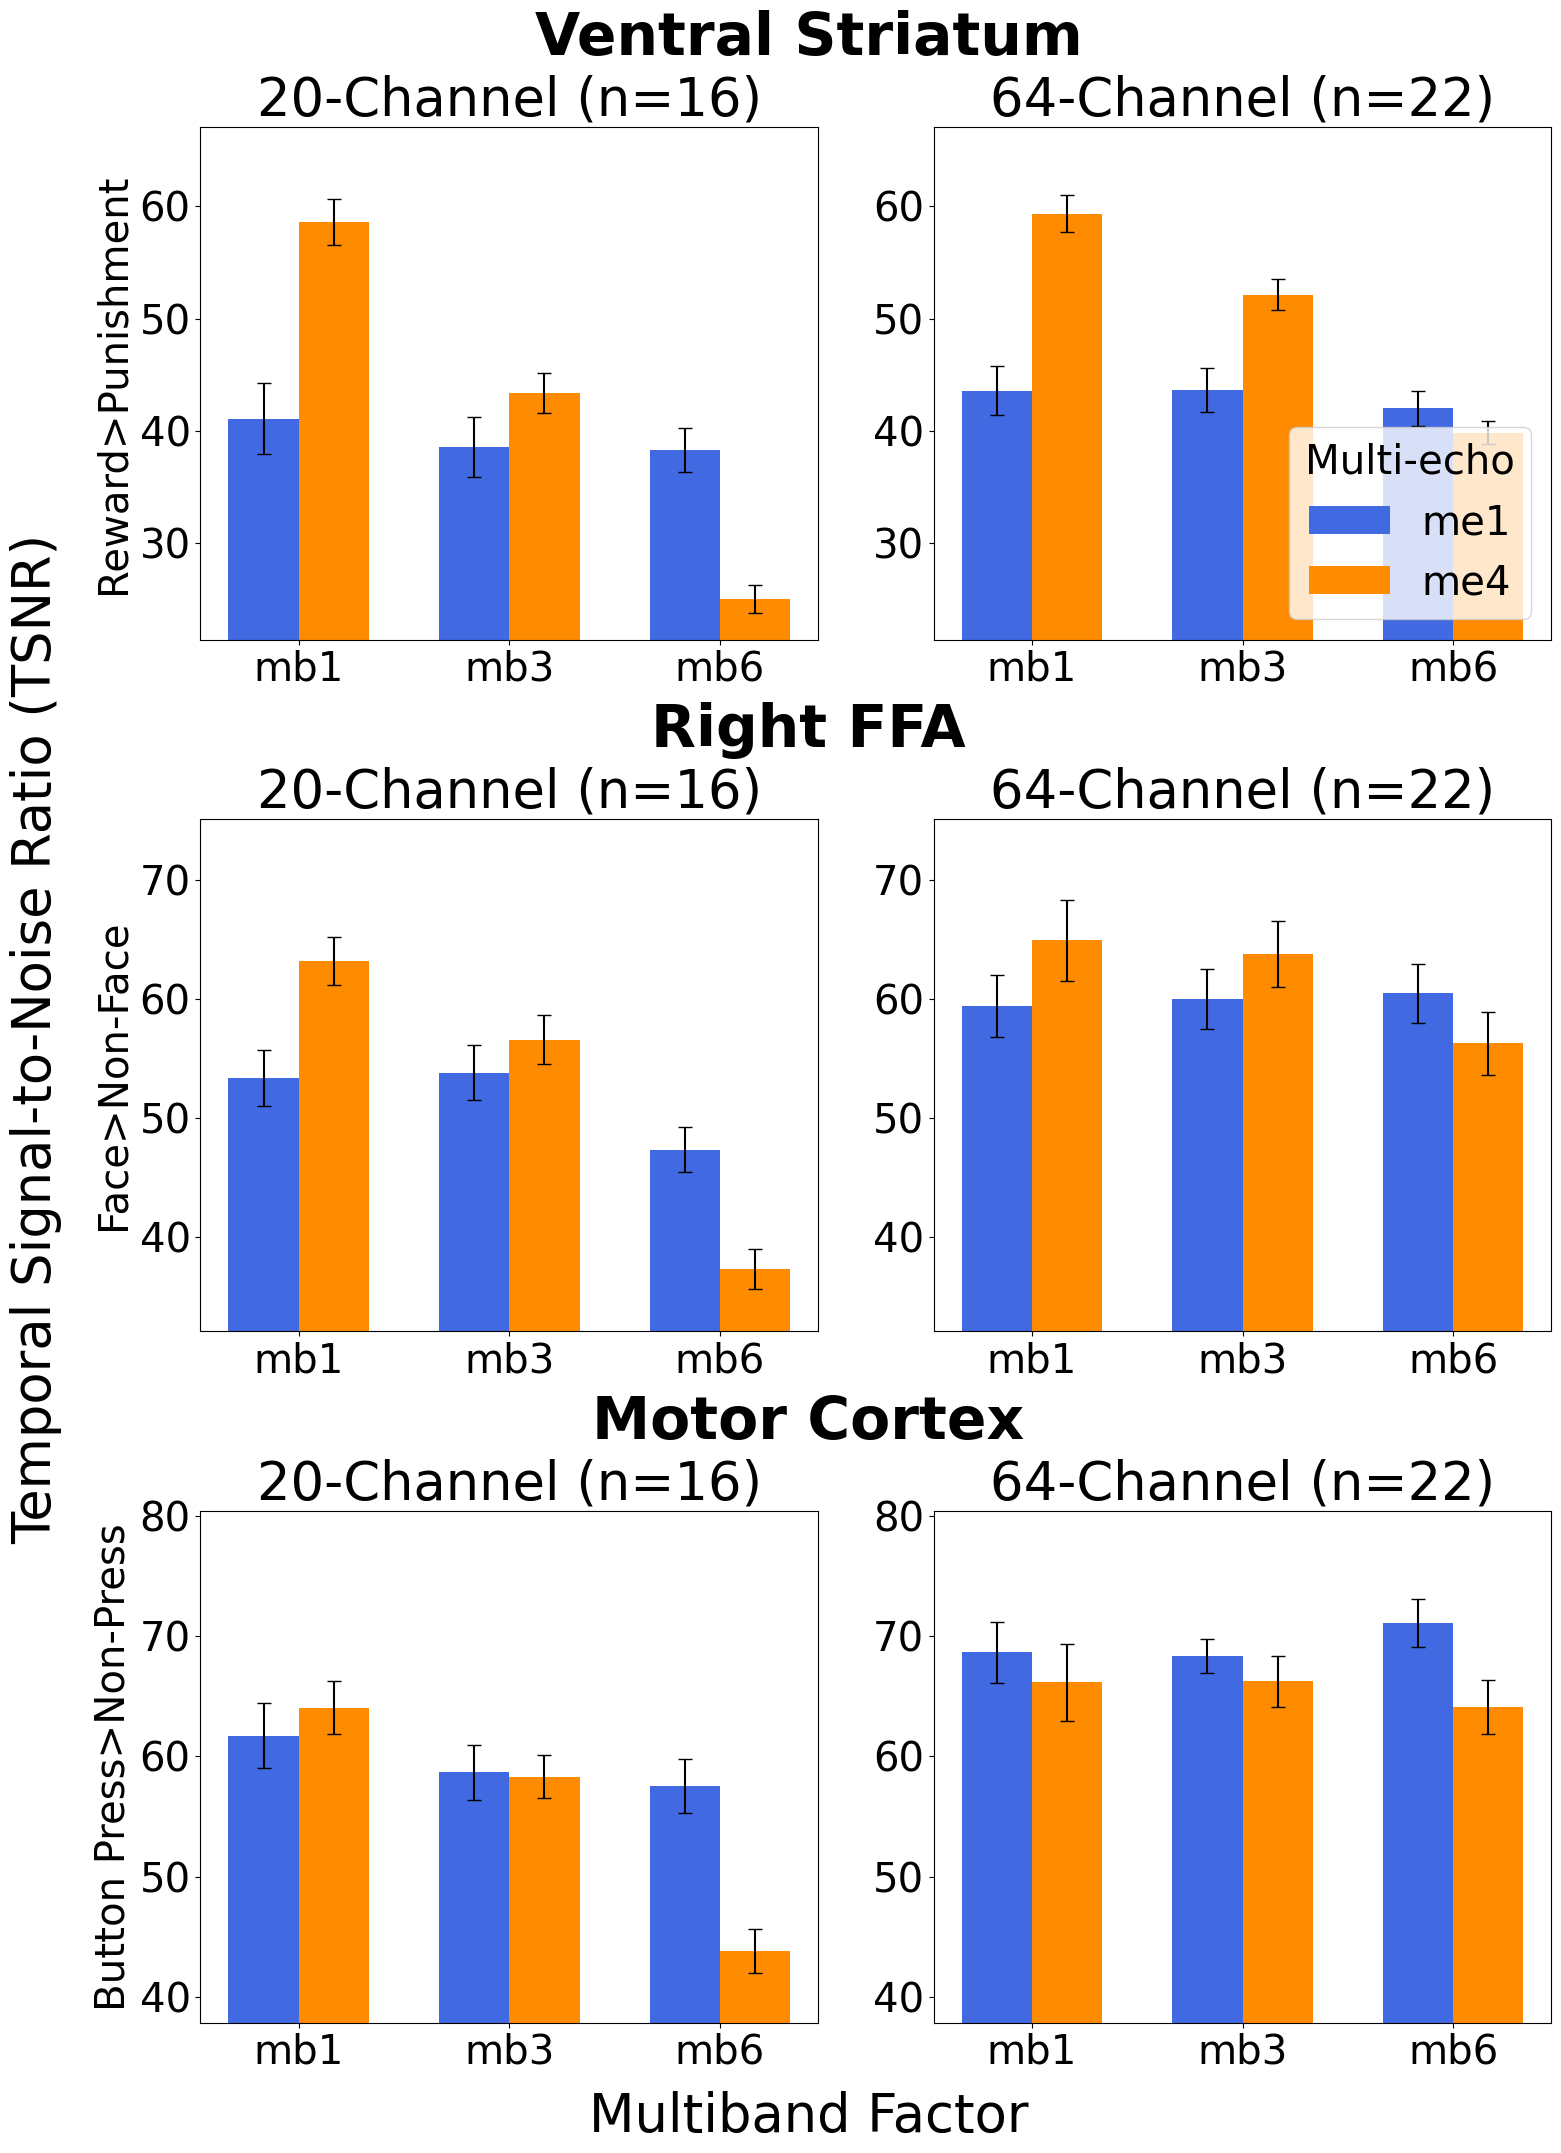


PART 4: VS VS MOTOR COMPARISON PLOTS
VS vs Motor comparison plot saved to 'vs_motor_tsnr_comparison_plot.png'


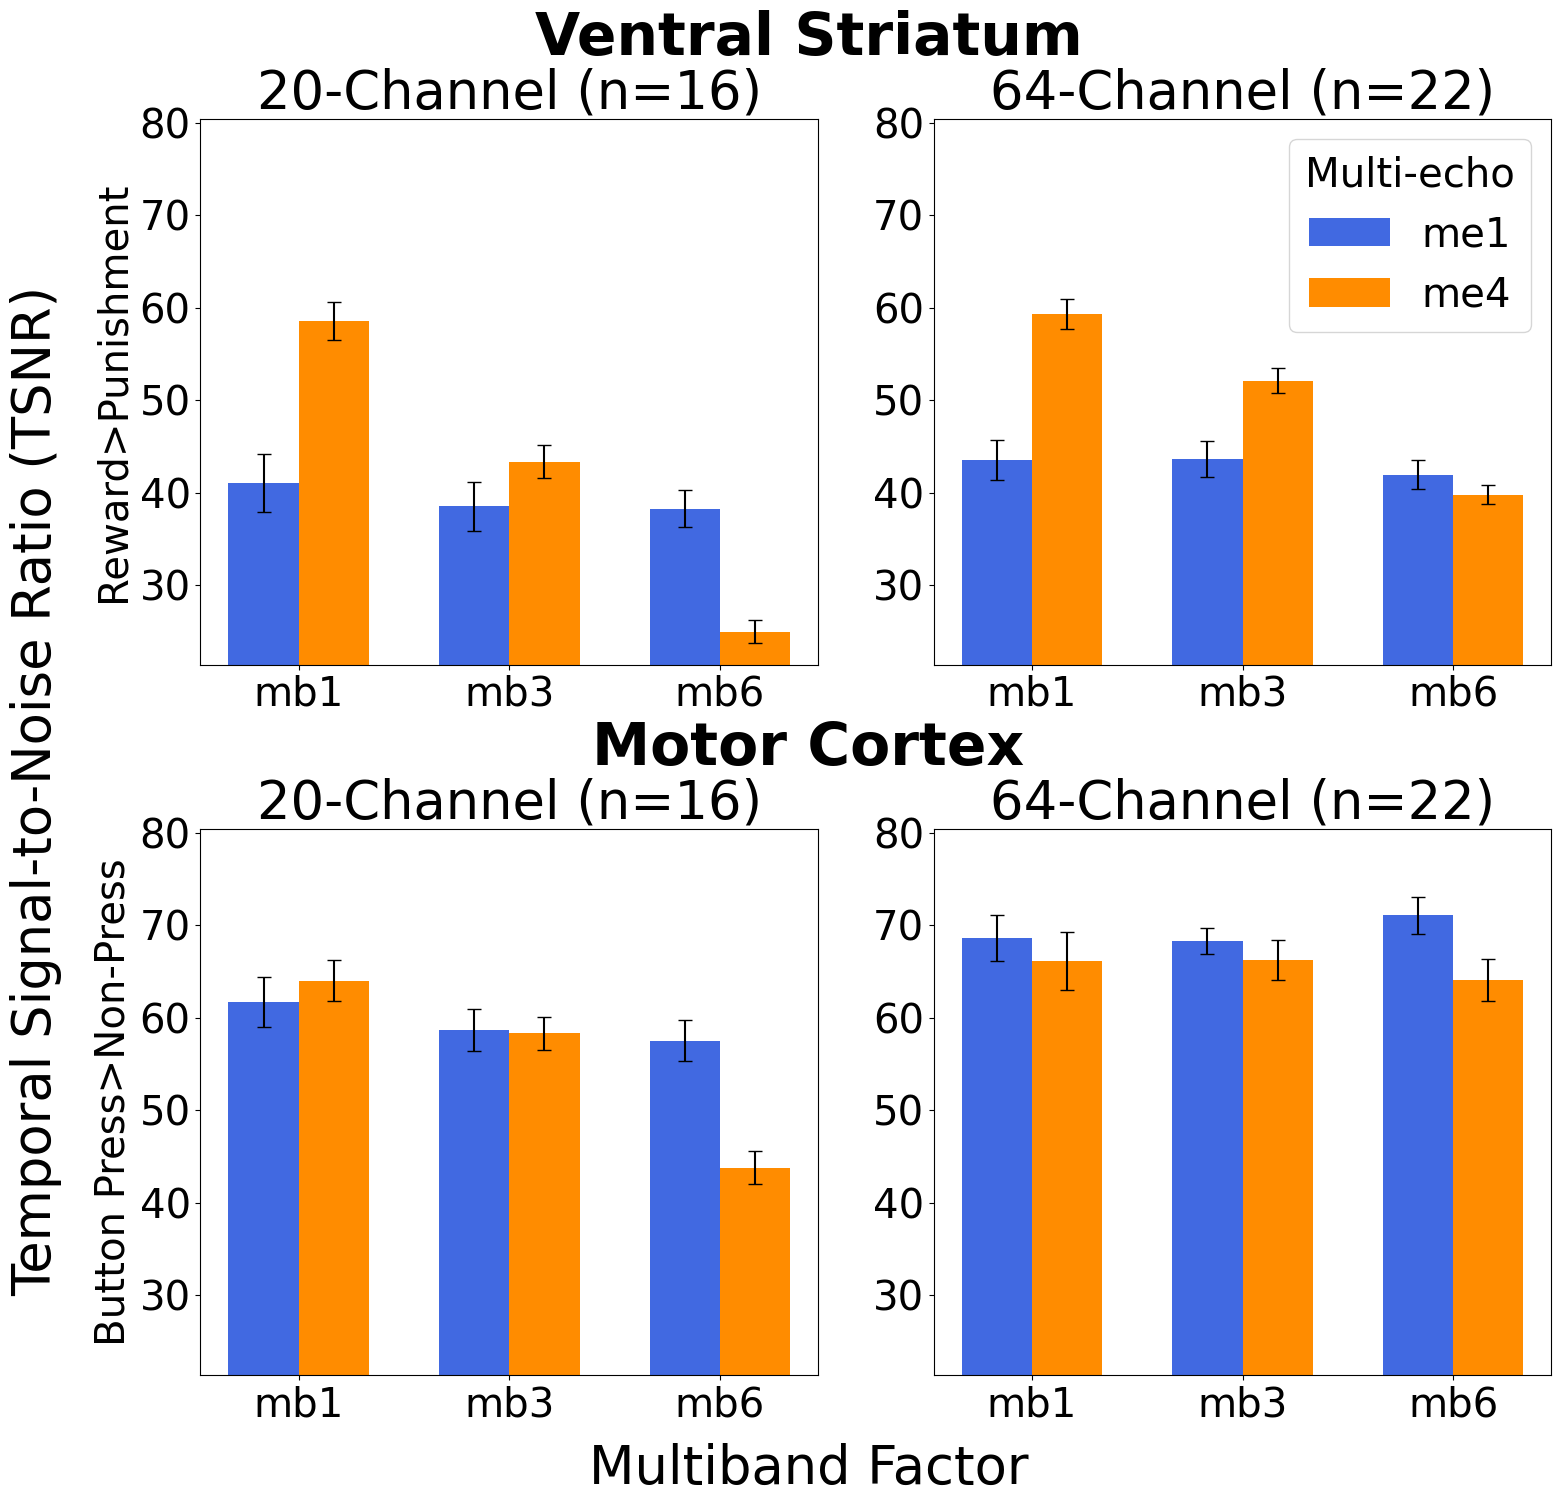


ANALYSIS COMPLETE - SUMMARY
ROIs analyzed: VSconstrained, rFFA, bilateralMotor
  Ventral Striatum: 38 total (16 20-ch, 22 64-ch)
  Right FFA: 38 total (16 20-ch, 22 64-ch)
  Motor Cortex: 38 total (16 20-ch, 22 64-ch)


In [13]:
# =============================================================================
# MULTI-ROI TSNR ANALYSIS WITH SMOOTHNESS COVARIATE (Fig. 5)
# =============================================================================
# Consolidates original Cells 8 + 9 (951 lines -> ~350 lines)
# Dependencies: project_root, output_dir, valid_subjects, headcoil_mapping,
#               smoothness_data, complete_smoothness (from Shared Deps),
#               extract_roi_data, identify_complete_subjects, ME_COLORS,
#               ROI_CONFIGS, STANDARD_EFFECT_NAMES (from Setup)
#
# NOTE: Uses sum-to-zero headcoil encoding and residual-SS eta-squared.

print("=" * 80)
print("MULTI-ROI TSNR ANALYSIS PIPELINE WITH SMOOTHNESS COVARIATE")
print("=" * 80)

# --- Config ---
IMG_VALUE_TSNR = "tsnr"
ROIS_TSNR = ROI_CONFIGS['3roi']['rois']
ROI_LABELS_TSNR = ROI_CONFIGS['3roi']['labels']

complete_subjects_file = output_dir / 'complete_subjects_multi_roi_tsnr_with_smoothness.csv'
combined_plot_file_tsnr = output_dir / 'multi_roi_tsnr_bar_plot.png'

print(f"Processing TSNR for ROIs: {', '.join(ROIS_TSNR)}")

# =============================================================================
# LOCAL FUNCTION: TSNR LME with headcoil_encoded
# =============================================================================

def run_tsnr_lme(merged_data, roi_name, effect_names, df_dict):
    """Run LME for TSNR with sum-to-zero headcoil encoding."""
    model_data = merged_data.copy()
    model_data['headcoil_encoded'] = model_data['headcoil'].cat.codes - 0.5

    model = Lmer(f'{IMG_VALUE_TSNR} ~ headcoil_encoded * mb * me + smoothness + (1 | subject)',
                 data=model_data)
    model.fit()
    anova_results = model.anova()

    apa_data = []
    for effect in anova_results.index:
        if effect in ['(Intercept)', 'Residuals']:
            continue
        effect_name = effect_names.get(effect, effect)
        apa_data.append({
            'Effect': effect_name,
            'Sum Sq': anova_results.loc[effect, 'SS'] if 'SS' in anova_results.columns else np.nan,
            'Mean Sq': anova_results.loc[effect, 'MS'] if 'MS' in anova_results.columns else np.nan,
            'Num df': df_dict.get(effect_name, np.nan),
            'Den df': anova_results.loc[effect, 'DenomDF'] if 'DenomDF' in anova_results.columns else np.nan,
            'F': anova_results.loc[effect, 'F-stat'] if 'F-stat' in anova_results.columns else np.nan,
            'p': anova_results.loc[effect, 'P-val'] if 'P-val' in anova_results.columns else np.nan,
            'Partial eta_sq': np.nan
        })

    try:
        residual_var = model.ranef_var.loc[model.ranef_var['Name'] == '', 'Var'].iloc[0]
    except (KeyError, IndexError):
        residual_var = model.ranef_var.iloc[1]['Var']

    ss_residual = residual_var * (len(model_data) - sum(df_dict.values()) - model_data['subject'].nunique())

    for i, row in enumerate(apa_data):
        if pd.notna(row['Sum Sq']):
            apa_data[i]['Partial eta_sq'] = row['Sum Sq'] / (row['Sum Sq'] + ss_residual)

    apa_table = pd.DataFrame(apa_data)
    apa_table['Sum Sq'] = apa_table['Sum Sq'].round(2)
    apa_table['Mean Sq'] = apa_table['Mean Sq'].round(2)
    apa_table['Num df'] = apa_table['Num df'].astype('Int64').fillna(pd.NA)
    apa_table['Den df'] = apa_table['Den df'].round(2)
    apa_table['F'] = apa_table['F'].round(2)
    apa_table['p'] = apa_table['p'].apply(
        lambda x: '< .001' if pd.notna(x) and x < 0.001 else f'{x:.3f}' if pd.notna(x) else 'N/A'
    )
    apa_table['Partial eta_sq'] = apa_table['Partial eta_sq'].round(3)
    return apa_table


# Effect names for headcoil_encoded models
tsnr_effect_names = {
    'headcoil_encoded': 'Head Coil', 'mb': 'Multiband', 'me': 'Multi-echo',
    'smoothness': 'Smoothness',
    'headcoil_encoded:mb': 'Head Coil x Multiband', 'headcoil_encoded:me': 'Head Coil x Multi-echo',
    'mb:me': 'Multiband x Multi-echo', 'headcoil_encoded:mb:me': 'Head Coil x Multiband x Multi-echo'
}
tsnr_df_dict = {
    'Head Coil': 1, 'Multiband': 2, 'Multi-echo': 1, 'Smoothness': 1,
    'Head Coil x Multiband': 2, 'Head Coil x Multi-echo': 1,
    'Multiband x Multi-echo': 2, 'Head Coil x Multiband x Multi-echo': 2
}

# Extended for 4-factor ROI model
tsnr_roi_effect_names = {
    **tsnr_effect_names,
    'roi': 'ROI',
    'headcoil_encoded:roi': 'Head Coil x ROI', 'mb:roi': 'Multiband x ROI',
    'me:roi': 'Multi-echo x ROI',
    'headcoil_encoded:mb:me': 'Head Coil x Multiband x Multi-echo',
    'headcoil_encoded:mb:roi': 'Head Coil x Multiband x ROI',
    'headcoil_encoded:me:roi': 'Head Coil x Multi-echo x ROI',
    'mb:me:roi': 'Multiband x Multi-echo x ROI',
    'headcoil_encoded:mb:me:roi': 'Head Coil x Multiband x Multi-echo x ROI'
}


def make_roi_df_dict(n_rois):
    """Build df_dict for ROI-factor model with given number of ROI levels."""
    k = n_rois - 1
    return {
        **tsnr_df_dict,
        'ROI': k,
        'Head Coil x ROI': k, 'Multiband x ROI': 2*k, 'Multi-echo x ROI': k,
        'Head Coil x Multiband x ROI': 2*k, 'Head Coil x Multi-echo x ROI': k,
        'Multiband x Multi-echo x ROI': 2*k, 'Head Coil x Multiband x Multi-echo x ROI': 2*k
    }


# =============================================================================
# LOCAL FUNCTION: TSNR bar plot
# =============================================================================

def plot_tsnr_bars(ax, plot_data, headcoil, n_subjects):
    """Plot TSNR bar chart for a specific headcoil."""
    width = 0.4
    x_pos = np.array([0, 1.2, 2.4])
    mb_levels = ['mb1', 'mb3', 'mb6']

    hc_data = plot_data[plot_data['headcoil'] == headcoil]
    if hc_data.empty:
        ax.set_title(f"{headcoil}-Channel (n=0)", fontsize=38)
        return

    for me_level in ['me1', 'me4']:
        me_data = hc_data[hc_data['me'] == me_level]
        means, sems = [], []
        for mb in mb_levels:
            mb_data = me_data[me_data['mb'] == mb]
            means.append(mb_data['mean'].iloc[0] if not mb_data.empty else 0)
            sems.append(mb_data['sem'].iloc[0] if not mb_data.empty else 0)

        offset = -width/2 if me_level == 'me1' else width/2
        ax.bar(x_pos + offset, means, width, label=me_level,
               color=ME_COLORS[me_level], yerr=sems, capsize=5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(mb_levels)
    ax.tick_params(axis='both', which='major', labelsize=29)
    ax.set_title(f"{headcoil}-Channel (n={n_subjects})", fontsize=38)


# =============================================================================
# PART 1: LOAD DATA AND IDENTIFY COMPLETE SUBJECTS
# =============================================================================

print("\n" + "=" * 80)
print("PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS")
print("=" * 80)

# smoothness_data and complete_smoothness already loaded in Shared Deps cell

roi_results_tsnr = {}
all_roi_data_tsnr = {}

for roi in ROIS_TSNR:
    print(f"\nProcessing {roi}...")

    # Use shared extract_roi_data with img_value='tsnr'
    roi_data = extract_roi_data(extractions_dir, TYPE_VALUE, IMG_VALUE_TSNR,
                                 roi, DENOISE_VALUE, valid_subjects, headcoil_mapping)
    if roi_data is None:
        print(f"  Warning: No data found for {roi}")
        continue

    complete_roi = identify_complete_subjects(roi_data, IMG_VALUE_TSNR)
    print(f"  Complete {roi} subjects: {len(complete_roi)}")

    common_complete = sorted(list(set(complete_roi) & set(complete_smoothness)))
    print(f"  Common complete subjects: {len(common_complete)}")

    if not common_complete:
        print(f"  No common complete subjects for {roi}")
        continue

    roi_filtered = roi_data[roi_data['subject'].isin(common_complete)].copy()
    smoothness_filtered = smoothness_data[smoothness_data['subject'].isin(common_complete)].copy()

    merged = pd.merge(
        roi_filtered[['subject', 'headcoil', 'mb', 'me', IMG_VALUE_TSNR]],
        smoothness_filtered[['subject', 'mb', 'me', 'smoothness']],
        on=['subject', 'mb', 'me'], how='inner'
    ).dropna()

    roi_results_tsnr[roi] = {
        'data': merged,
        'n_subjects': merged['subject'].nunique(),
        'n_20ch': len(merged[merged['headcoil'] == '20']['subject'].unique()),
        'n_64ch': len(merged[merged['headcoil'] == '64']['subject'].unique())
    }
    all_roi_data_tsnr[roi] = roi_filtered

# =============================================================================
# PART 2: PER-ROI LME ANALYSES
# =============================================================================

print("\n" + "=" * 80)
print("PART 2: LINEAR MIXED EFFECTS ANALYSES")
print("=" * 80)

for roi in ROIS_TSNR:
    if roi not in roi_results_tsnr:
        continue

    print(f"\n=== {ROI_LABELS_TSNR[roi]} ({roi}) ===")
    rd = roi_results_tsnr[roi]
    print(f"N = {rd['n_subjects']} subjects ({rd['n_20ch']} 20-ch, {rd['n_64ch']} 64-ch)")

    apa_table = run_tsnr_lme(rd['data'], roi, tsnr_effect_names, tsnr_df_dict)
    print(f"\nAPA-Style ANOVA Table:")
    print(f"Model: {IMG_VALUE_TSNR} ~ headcoil * mb * me + smoothness + (1 | subject)")
    print(f"Data: {ROI_LABELS_TSNR[roi]} ROI\n")
    print(apa_table.to_string(index=False))

    anova_file = output_dir / f'{roi}_{IMG_VALUE_TSNR}_lme_anova_with_smoothness.csv'
    apa_table.to_csv(anova_file, index=False)
    print(f"\nSaved to '{anova_file.name}'")

# =============================================================================
# PART 2.5: COMBINED ROI ANALYSES (VS+Motor, All 3 ROIs)
# =============================================================================

for rois_to_compare, label in [
    (['VSconstrained', 'bilateralMotor'], 'VS vs Motor'),
    (ROIS_TSNR, f'All {len(ROIS_TSNR)} ROIs')
]:
    print(f"\n{'=' * 80}")
    print(f"COMBINED LME: {label}")
    print(f"{'=' * 80}")

    combined_roi_data = []
    for roi in rois_to_compare:
        if roi in roi_results_tsnr:
            rd = roi_results_tsnr[roi]['data'].copy()
            rd['roi'] = roi
            combined_roi_data.append(rd)

    if len(combined_roi_data) < 2:
        print(f"Not enough ROI data for {label} comparison")
        continue

    combined_df = pd.concat(combined_roi_data, ignore_index=True)
    combined_df['roi'] = pd.Categorical(combined_df['roi'], categories=rois_to_compare)

    print(f"\nCombined dataset: {len(combined_df)} observations")
    print(f"Subjects: {combined_df['subject'].nunique()}")
    print(f"ROI breakdown: {combined_df['roi'].value_counts().to_dict()}")

    model_data_c = combined_df.copy()
    model_data_c['headcoil_encoded'] = model_data_c['headcoil'].cat.codes - 0.5

    model_c = Lmer(f'{IMG_VALUE_TSNR} ~ headcoil_encoded * mb * me * roi + smoothness + (1 | subject)',
                   data=model_data_c)
    model_c.fit()
    anova_c = model_c.anova()

    roi_df_dict = make_roi_df_dict(len(rois_to_compare))

    # Build APA table inline for the combined model (can't reuse run_tsnr_lme since model is different)
    apa_data_c = []
    for effect in anova_c.index:
        if effect in ['(Intercept)', 'Residuals']:
            continue
        effect_name = tsnr_roi_effect_names.get(effect, effect)
        apa_data_c.append({
            'Effect': effect_name,
            'Sum Sq': anova_c.loc[effect, 'SS'] if 'SS' in anova_c.columns else np.nan,
            'Mean Sq': anova_c.loc[effect, 'MS'] if 'MS' in anova_c.columns else np.nan,
            'Num df': roi_df_dict.get(effect_name, np.nan),
            'Den df': anova_c.loc[effect, 'DenomDF'] if 'DenomDF' in anova_c.columns else np.nan,
            'F': anova_c.loc[effect, 'F-stat'] if 'F-stat' in anova_c.columns else np.nan,
            'p': anova_c.loc[effect, 'P-val'] if 'P-val' in anova_c.columns else np.nan,
            'Partial eta_sq': np.nan
        })

    try:
        resvar_c = model_c.ranef_var.loc[model_c.ranef_var['Name'] == '', 'Var'].iloc[0]
    except (KeyError, IndexError):
        resvar_c = model_c.ranef_var.iloc[1]['Var']

    ss_res_c = resvar_c * (len(model_data_c) - sum(roi_df_dict.values()) - model_data_c['subject'].nunique())
    for i, row in enumerate(apa_data_c):
        if pd.notna(row['Sum Sq']):
            apa_data_c[i]['Partial eta_sq'] = row['Sum Sq'] / (row['Sum Sq'] + ss_res_c)

    apa_table_c = pd.DataFrame(apa_data_c)
    for col in ['Sum Sq', 'Mean Sq']:
        apa_table_c[col] = apa_table_c[col].round(2)
    apa_table_c['Num df'] = apa_table_c['Num df'].astype('Int64').fillna(pd.NA)
    apa_table_c['Den df'] = apa_table_c['Den df'].round(2)
    apa_table_c['F'] = apa_table_c['F'].round(2)
    apa_table_c['p'] = apa_table_c['p'].apply(
        lambda x: '< .001' if pd.notna(x) and x < 0.001 else f'{x:.3f}' if pd.notna(x) else 'N/A'
    )
    apa_table_c['Partial eta_sq'] = apa_table_c['Partial eta_sq'].round(3)

    print(f"\nAPA-Style ANOVA Table for {label}:")
    print(apa_table_c.to_string(index=False))

    fname = 'vs_motor' if len(rois_to_compare) == 2 else 'combined'
    anova_file_c = output_dir / f'{fname}_roi_{IMG_VALUE_TSNR}_lme_anova_with_smoothness.csv'
    apa_table_c.to_csv(anova_file_c, index=False)
    print(f"\nSaved to '{anova_file_c.name}'")

# =============================================================================
# PART 3: 3-ROI TSNR BAR PLOT VISUALIZATION
# =============================================================================

print("\n" + "=" * 80)
print("PART 3: GENERATING COMBINED BAR PLOTS")
print("=" * 80)

plot_data_by_roi = {}
for roi in ROIS_TSNR:
    if roi not in all_roi_data_tsnr:
        continue
    pd_roi = all_roi_data_tsnr[roi].groupby(['mb', 'me', 'headcoil']).agg({
        IMG_VALUE_TSNR: ['mean', 'sem']
    }).reset_index()
    pd_roi.columns = ['mb', 'me', 'headcoil', 'mean', 'sem']
    plot_data_by_roi[roi] = pd_roi

plt.rcParams.update({'font.size': 38})
fig, axes = plt.subplots(len(ROIS_TSNR), 2, figsize=(16, 8 * len(ROIS_TSNR)))

roi_ylabels_tsnr = ROI_CONFIGS['3roi']['ylabels']

for roi_idx, roi in enumerate(ROIS_TSNR):
    if roi not in plot_data_by_roi:
        continue

    pdata = plot_data_by_roi[roi]
    n_20 = len(all_roi_data_tsnr[roi][all_roi_data_tsnr[roi]['headcoil'] == '20']['subject'].unique()) if roi in all_roi_data_tsnr else 0
    n_64 = len(all_roi_data_tsnr[roi][all_roi_data_tsnr[roi]['headcoil'] == '64']['subject'].unique()) if roi in all_roi_data_tsnr else 0

    plot_tsnr_bars(axes[roi_idx, 0], pdata, '20', n_20)
    plot_tsnr_bars(axes[roi_idx, 1], pdata, '64', n_64)

    # Matched y-limits per row
    all_means = pdata['mean'].values
    all_sems = pdata['sem'].values
    y_max = max(all_means + all_sems) * 1.1
    y_min = min(all_means - all_sems) * 0.9
    y_lim = (max(0, y_min), y_max)
    axes[roi_idx, 0].set_ylim(y_lim)
    axes[roi_idx, 1].set_ylim(y_lim)

    axes[roi_idx, 0].set_ylabel(roi_ylabels_tsnr.get(roi, ''), fontsize=29)

axes[0, 1].legend(title='Multi-echo', fontsize=29, title_fontsize=29, loc='lower right')
fig.text(0.001, 0.5, 'Temporal Signal-to-Noise Ratio (TSNR)',
         va='center', rotation='vertical', fontsize=38)
fig.supxlabel('Multiband Factor', fontsize=38, y=0.04)

plt.tight_layout()
fig.subplots_adjust(top=0.88, left=0.12, hspace=0.35)

for roi_idx, roi in enumerate(ROIS_TSNR):
    if roi in plot_data_by_roi:
        bbox = axes[roi_idx, 0].get_position()
        fig.text(0.5, bbox.y1 + 0.03, ROI_LABELS_TSNR[roi],
                 ha='center', fontsize=42, fontweight='bold', transform=fig.transFigure)

plt.savefig(combined_plot_file_tsnr, dpi=300, bbox_inches='tight')
print(f"Combined plot saved to '{combined_plot_file_tsnr.name}'")
plt.show()

# =============================================================================
# PART 4: VS vs MOTOR COMPARISON PLOT
# =============================================================================

print("\n" + "=" * 80)
print("PART 4: VS VS MOTOR COMPARISON PLOTS")
print("=" * 80)

comparison_rois = ['VSconstrained', 'bilateralMotor']
comparison_ylabels = {'VSconstrained': 'Reward>Punishment', 'bilateralMotor': 'Button Press>Non-Press'}

plt.rcParams.update({'font.size': 38})
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 16))

# Global y-limits across both comparison ROIs
all_m, all_s = [], []
for roi in comparison_rois:
    if roi in plot_data_by_roi:
        all_m.extend(plot_data_by_roi[roi]['mean'].values)
        all_s.extend(plot_data_by_roi[roi]['sem'].values)
if all_m:
    gy_max = max(m + s for m, s in zip(all_m, all_s)) * 1.1
    gy_min = min(m - s for m, s in zip(all_m, all_s)) * 0.9
    global_y_limits = (max(0, gy_min), gy_max)
else:
    global_y_limits = (0, 100)

for ri, roi in enumerate(comparison_rois):
    if roi not in plot_data_by_roi:
        continue

    pdata = plot_data_by_roi[roi]
    n_20 = len(all_roi_data_tsnr[roi][all_roi_data_tsnr[roi]['headcoil'] == '20']['subject'].unique()) if roi in all_roi_data_tsnr else 0
    n_64 = len(all_roi_data_tsnr[roi][all_roi_data_tsnr[roi]['headcoil'] == '64']['subject'].unique()) if roi in all_roi_data_tsnr else 0

    plot_tsnr_bars(axes2[ri, 0], pdata, '20', n_20)
    axes2[ri, 0].set_ylim(global_y_limits)
    plot_tsnr_bars(axes2[ri, 1], pdata, '64', n_64)
    axes2[ri, 1].set_ylim(global_y_limits)
    axes2[ri, 0].set_ylabel(comparison_ylabels[roi], fontsize=29)

axes2[0, 1].legend(title='Multi-echo', fontsize=29, title_fontsize=29, loc='upper right')
fig2.text(0.001, 0.5, 'Temporal Signal-to-Noise Ratio (TSNR)',
          va='center', rotation='vertical', fontsize=38)
fig2.supxlabel('Multiband Factor', fontsize=38, y=0.06)

plt.tight_layout()
fig2.subplots_adjust(top=0.92, left=0.12, hspace=0.30)

for ri, roi in enumerate(comparison_rois):
    if roi in plot_data_by_roi:
        bbox = axes2[ri, 0].get_position()
        fig2.text(0.5, bbox.y1 + 0.04, ROI_LABELS_TSNR[roi],
                  ha='center', fontsize=42, fontweight='bold', transform=fig2.transFigure)

comparison_plot_file = output_dir / 'vs_motor_tsnr_comparison_plot.png'
plt.savefig(comparison_plot_file, dpi=300, bbox_inches='tight')
print(f"VS vs Motor comparison plot saved to '{comparison_plot_file.name}'")
plt.show()

# =============================================================================
# SUMMARY
# =============================================================================

print(f"\n{'=' * 80}")
print("ANALYSIS COMPLETE - SUMMARY")
print(f"{'=' * 80}")
print(f"ROIs analyzed: {', '.join(ROIS_TSNR)}")
for roi in ROIS_TSNR:
    if roi in roi_results_tsnr:
        r = roi_results_tsnr[roi]
        print(f"  {ROI_LABELS_TSNR[roi]}: {r['n_subjects']} total ({r['n_20ch']} 20-ch, {r['n_64ch']} 64-ch)")
print("=" * 80)

# ROI Beta & Z-Stat Activation Analysis with EMMs (Fig. 6)

Analyzes activation estimates across Ventral Striatum, Right FFA, and Motor Cortex.
Runs both **beta** and **z-stat** analyses using the shared `run_full_roi_analysis` pipeline.


################################################################################
# BETA ANALYSIS
################################################################################

MULTI-ROI BETA ANALYSIS PIPELINE WITH SMOOTHNESS COVARIATE AND EMMs
Processing beta values for ROIs: VSconstrained, rFFA, bilateralMotor

PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS

Processing VSconstrained...
  Complete VSconstrained subjects: 38
  Common complete subjects: 38

Processing rFFA...
  Complete rFFA subjects: 38
  Common complete subjects: 38

Processing bilateralMotor...
  Complete bilateralMotor subjects: 38
  Common complete subjects: 38

PART 2: LINEAR MIXED EFFECTS ANALYSES

=== Ventral Striatum (VSconstrained) ===
N = 38 subjects (16 20-ch, 22 64-ch)
Linear mixed model fit by REML [’lmerMod’]
Formula: beta~headcoil*mb*me+smoothness+(1|subject)

Family: gaussian	 Inference: parametric

Number of observations: 228	 Groups: {'subject': 38.0}

Log-likelihood: -1427.603 	 AIC: 2885.

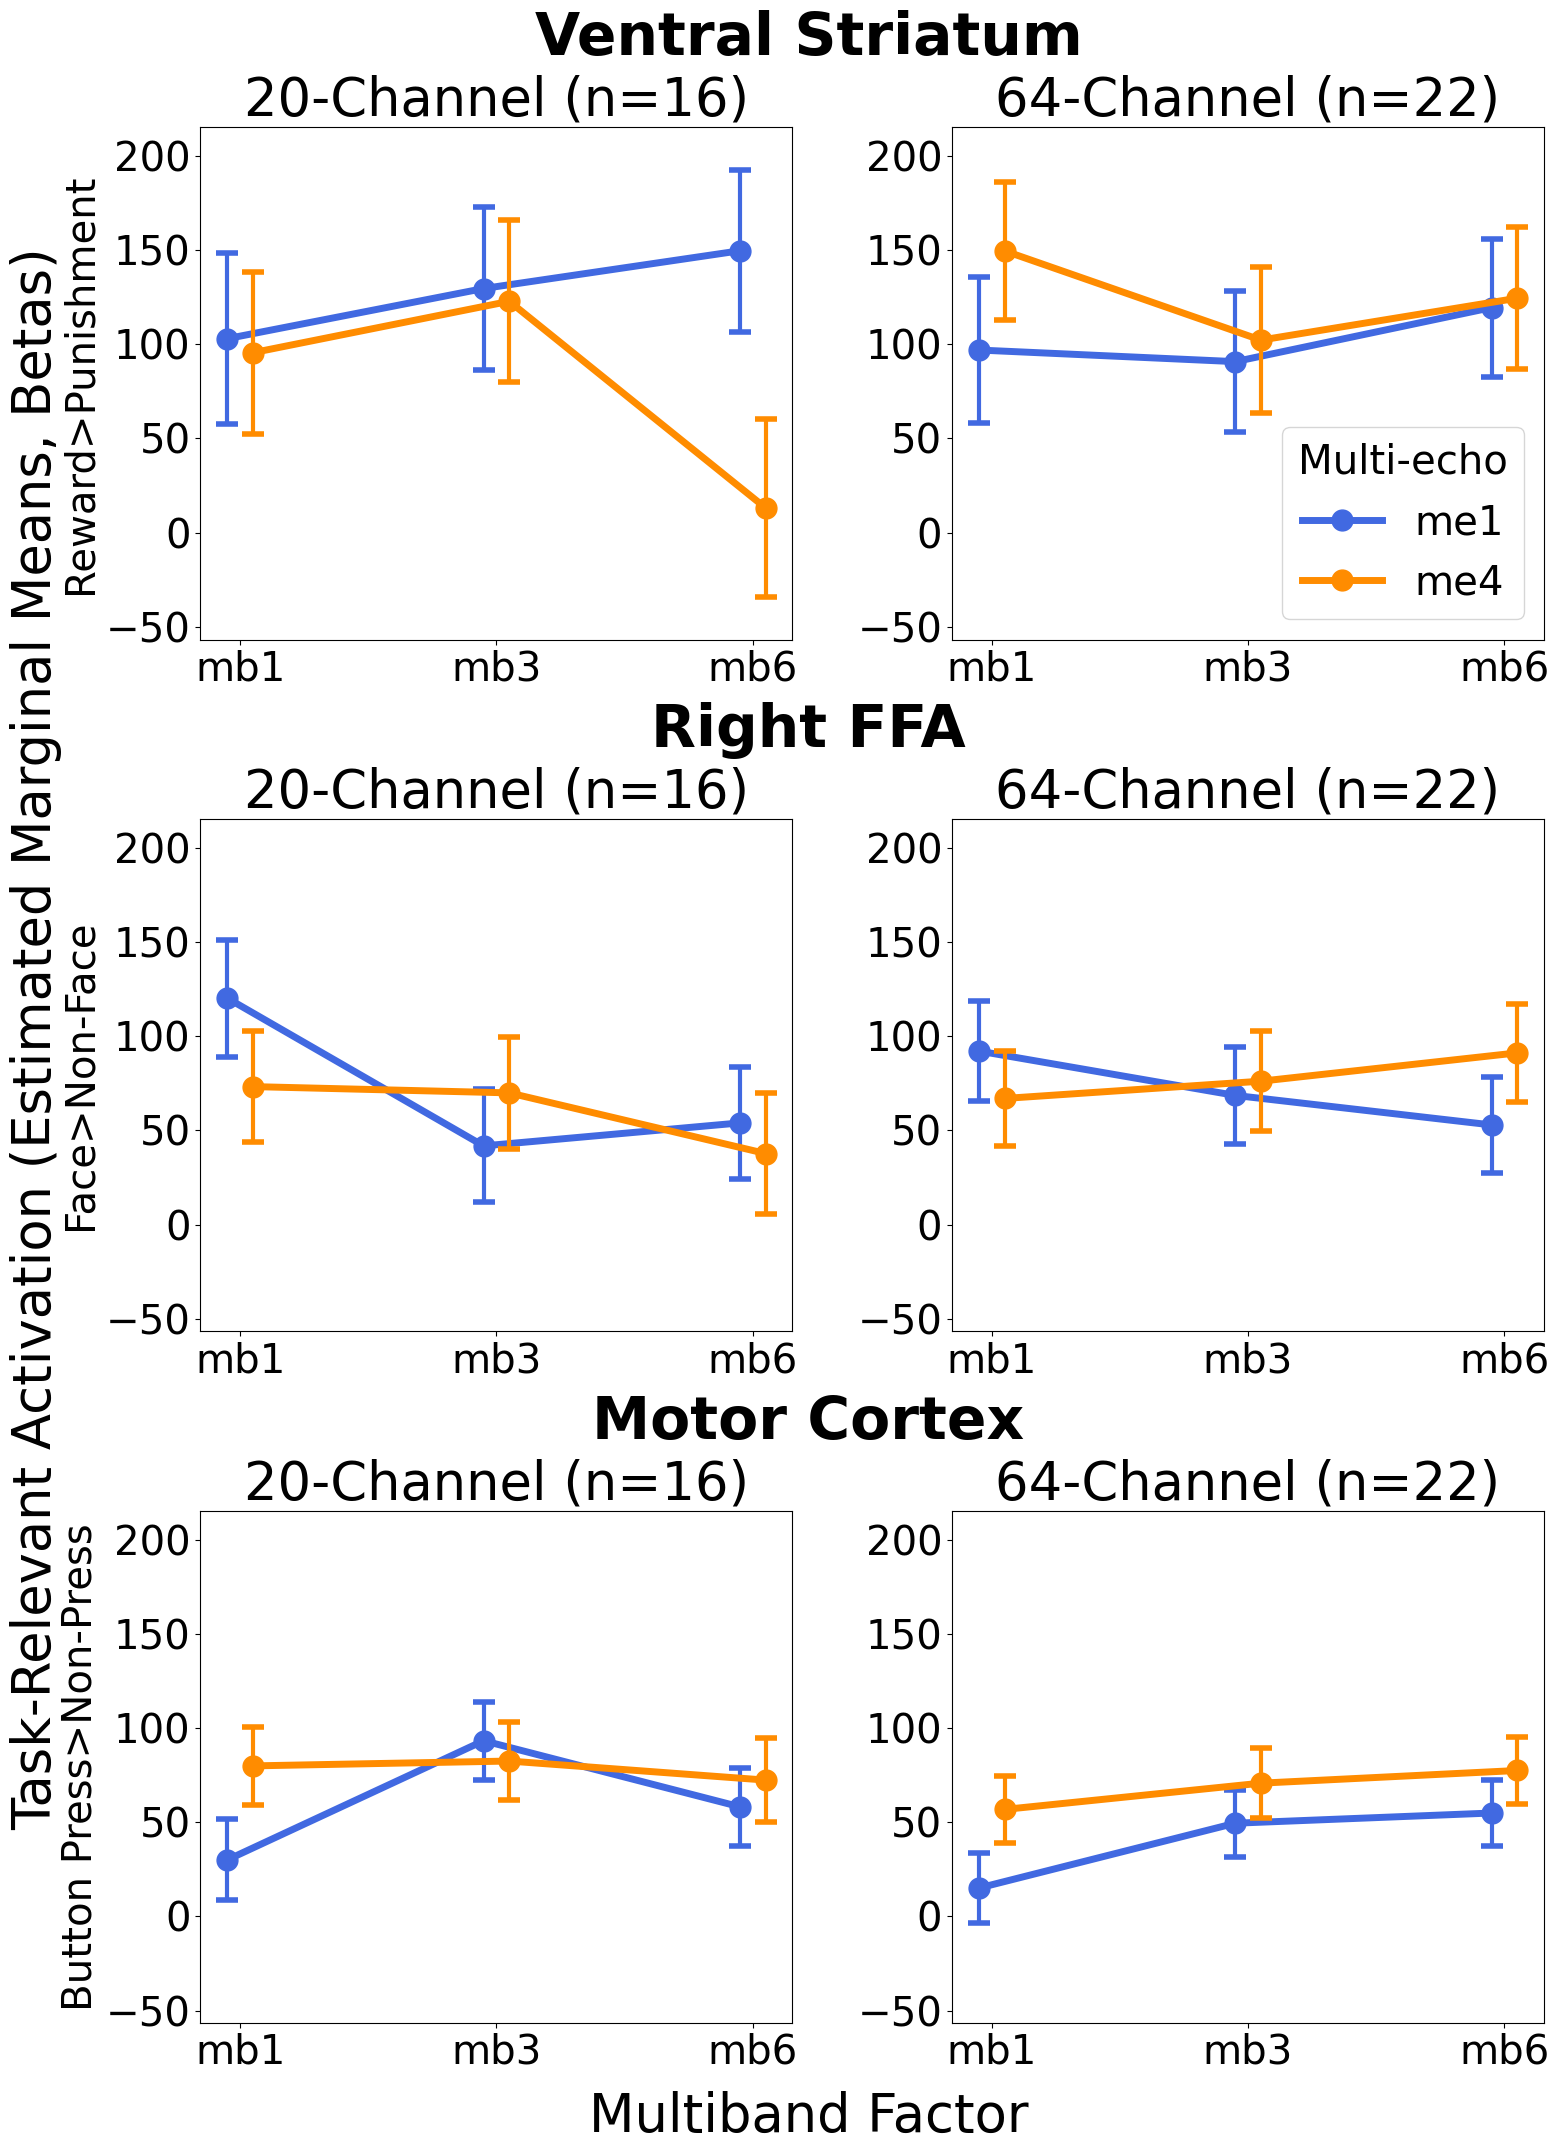


ANALYSIS COMPLETE - SUMMARY
ROIs analyzed: VSconstrained, rFFA, bilateralMotor
  Ventral Striatum: 38 total (16 20-ch, 22 64-ch)
  Right FFA: 38 total (16 20-ch, 22 64-ch)
  Motor Cortex: 38 total (16 20-ch, 22 64-ch)

################################################################################
# Z-STAT ANALYSIS (SUPPLEMENT)
################################################################################

MULTI-ROI Z-STAT ANALYSIS PIPELINE WITH SMOOTHNESS COVARIATE AND EMMs
Processing zstat values for ROIs: VSconstrained, rFFA, bilateralMotor

PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS

Processing VSconstrained...
  Complete VSconstrained subjects: 38
  Common complete subjects: 38

Processing rFFA...
  Complete rFFA subjects: 38
  Common complete subjects: 38

Processing bilateralMotor...
  Complete bilateralMotor subjects: 38
  Common complete subjects: 38

PART 2: LINEAR MIXED EFFECTS ANALYSES

=== Ventral Striatum (VSconstrained) ===
N = 38 subjects (16 20-ch, 22 6

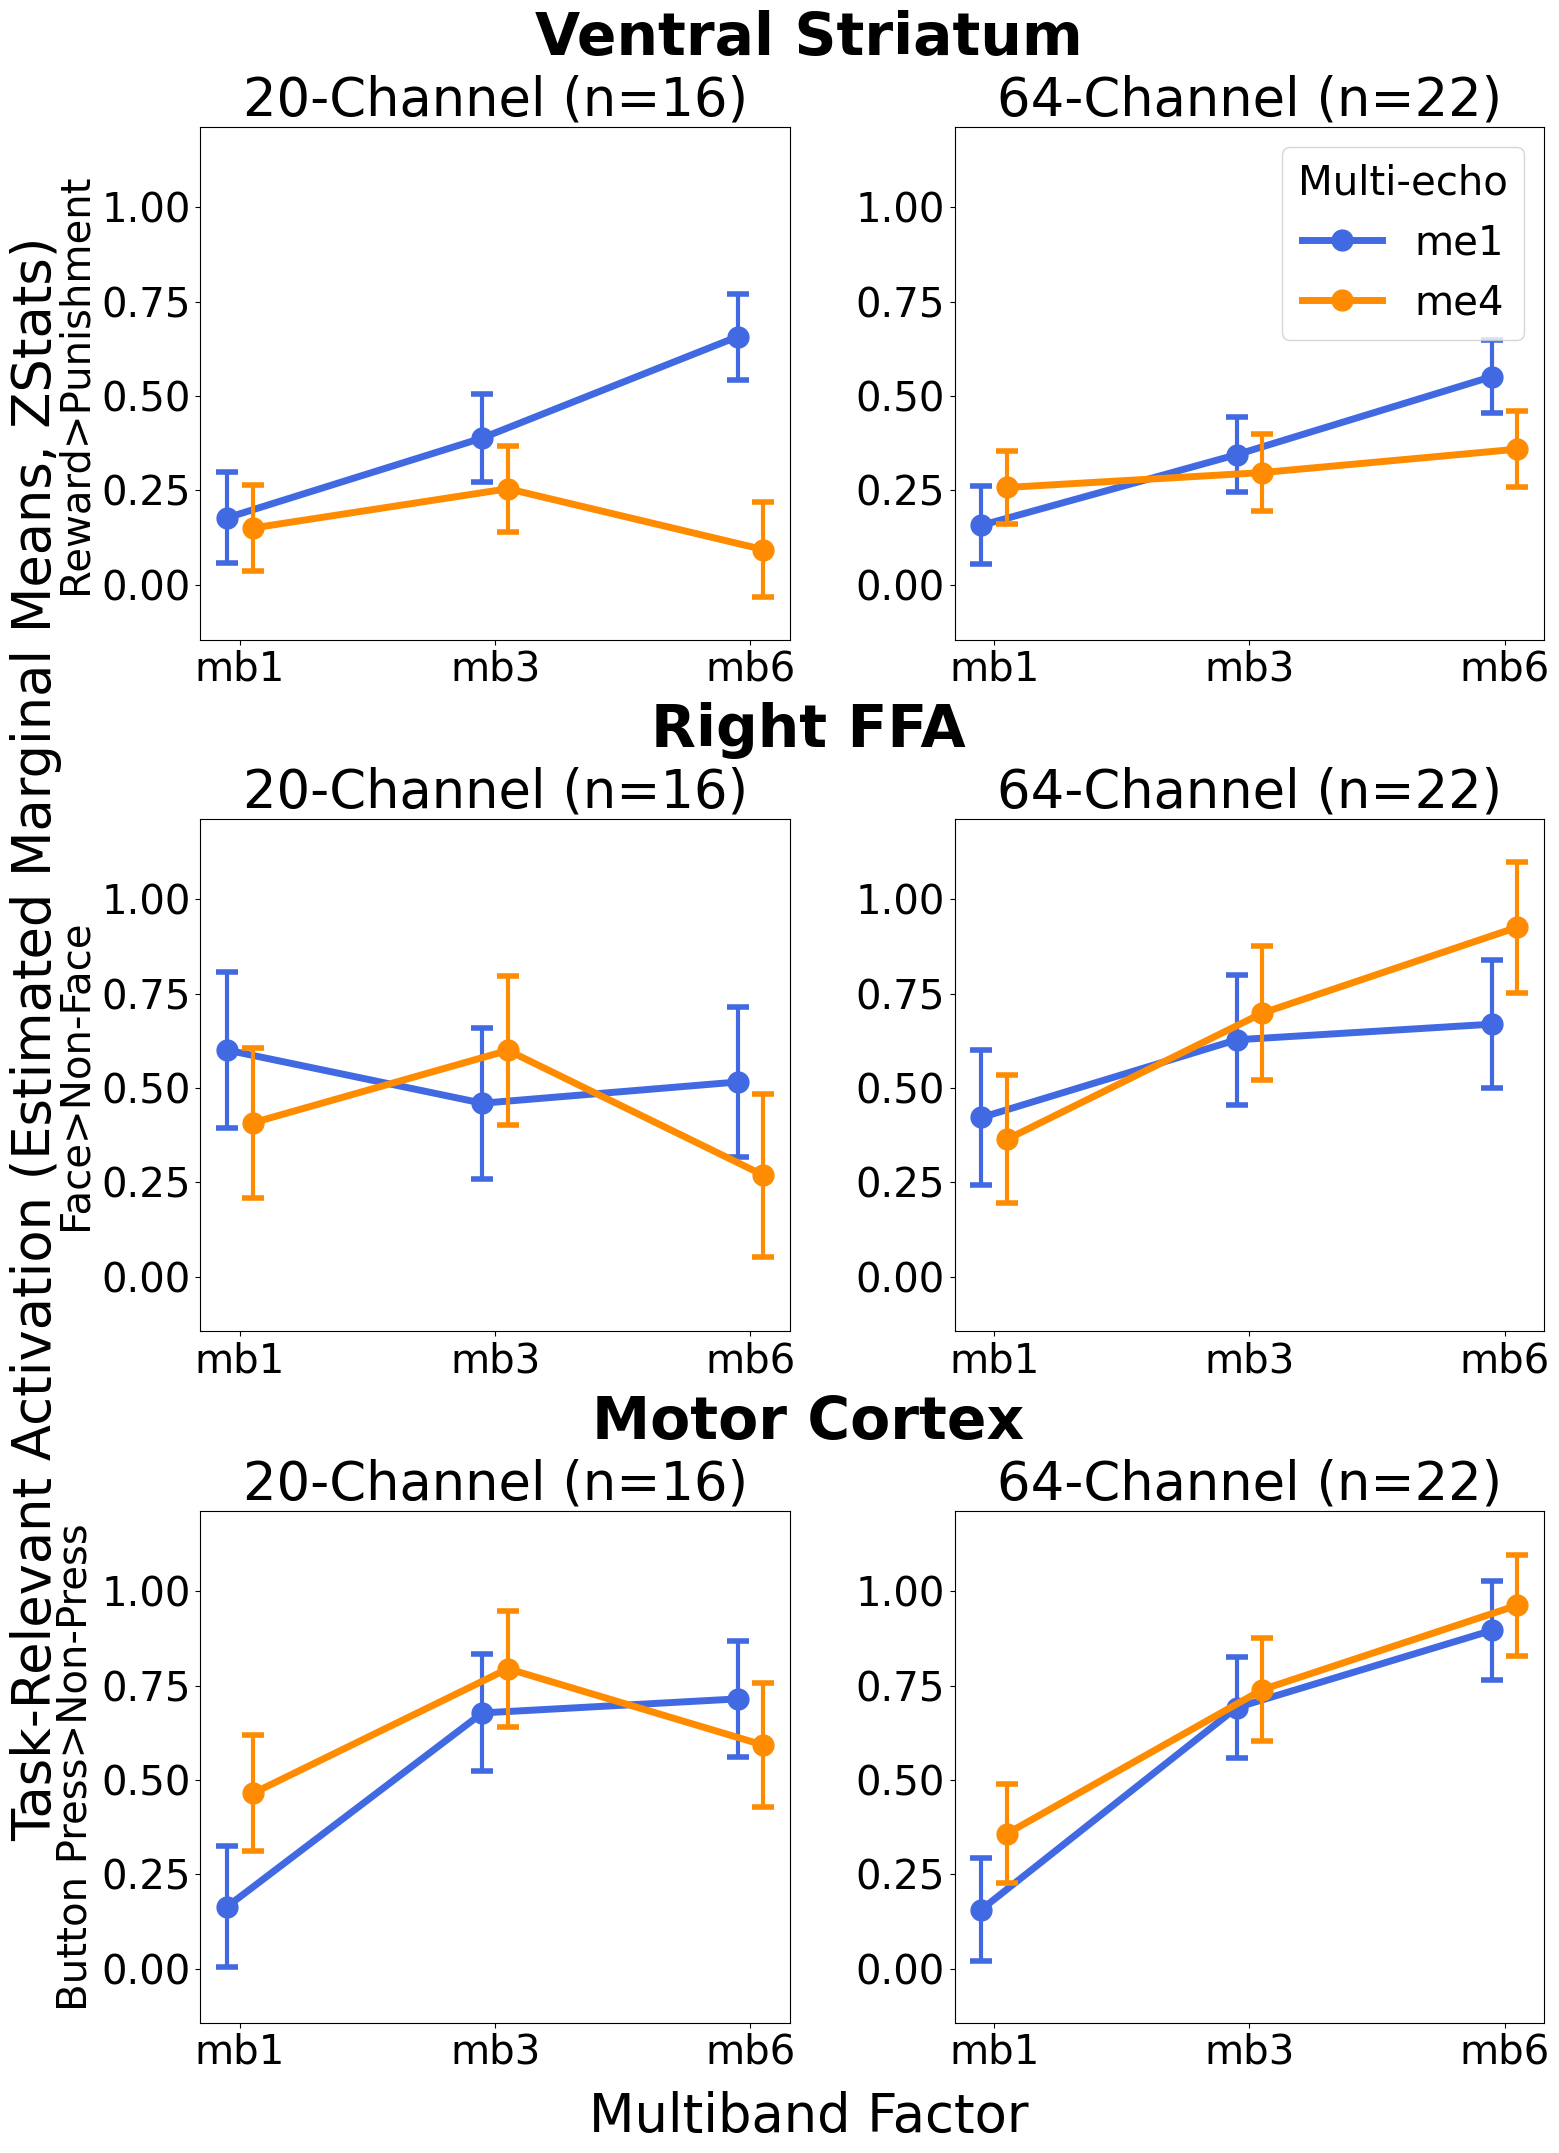


ANALYSIS COMPLETE - SUMMARY
ROIs analyzed: VSconstrained, rFFA, bilateralMotor
  Ventral Striatum: 38 total (16 20-ch, 22 64-ch)
  Right FFA: 38 total (16 20-ch, 22 64-ch)
  Motor Cortex: 38 total (16 20-ch, 22 64-ch)


In [15]:
# =============================================================================
# ROI ACTIVATION ANALYSIS — BETA AND Z-STAT (Fig. 6 + Supplement)
# =============================================================================

# Run beta analysis
print("\n" + "#" * 80)
print("# BETA ANALYSIS")
print("#" * 80 + "\n")

beta_roi_results, beta_emm_results = run_full_roi_analysis(
    img_value='beta',
    roi_config_key='3roi',
    valid_subjects=valid_subjects,
    headcoil_mapping=headcoil_mapping,
    smoothness_data=smoothness_data,
    complete_smoothness=complete_smoothness,
    legend_loc='lower right'
)

# Run z-stat analysis (supplemental)
print("\n" + "#" * 80)
print("# Z-STAT ANALYSIS (SUPPLEMENT)")
print("#" * 80 + "\n")

zstat_roi_results, zstat_emm_results = run_full_roi_analysis(
    img_value='zstat',
    roi_config_key='3roi',
    valid_subjects=valid_subjects,
    headcoil_mapping=headcoil_mapping,
    smoothness_data=smoothness_data,
    complete_smoothness=complete_smoothness,
    legend_loc='upper right'
)


# Motor vs Cerebellum ROI Comparison

Dedicated analysis comparing Motor Cortex and Cerebellum ROIs.
Includes a **combined 4-factor LME** model with ROI as a factor,
plus per-ROI EMM visualization. Runs for both beta and z-stat.


################################################################################
# MOTOR VS CEREBELLUM — BETA
################################################################################

MOTOR VS CEREBELLUM ROI COMPARISON — BETA ANALYSIS WITH EMMs

PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS

Processing bilateralMotor...
  Complete bilateralMotor subjects: 38
  Common complete subjects: 38

Processing bilateralCerebellum...
  Complete bilateralCerebellum subjects: 36
  Common complete subjects: 36
Computing EMMs for bilateralMotor...
Computing EMMs for bilateralCerebellum...

PART 2: COMBINED LINEAR MIXED EFFECTS ANALYSIS (MOTOR VS CEREBELLUM)

Combined dataset: 444 observations
Subjects: 38
ROI breakdown: {'bilateralMotor': 228, 'bilateralCerebellum': 216}
Linear mixed model fit by REML [’lmerMod’]
Formula: beta~headcoil*mb*me*roi+smoothness+(1|subject)

Family: gaussian	 Inference: parametric

Number of observations: 444	 Groups: {'subject': 38.0}

Log-likelihood: -2

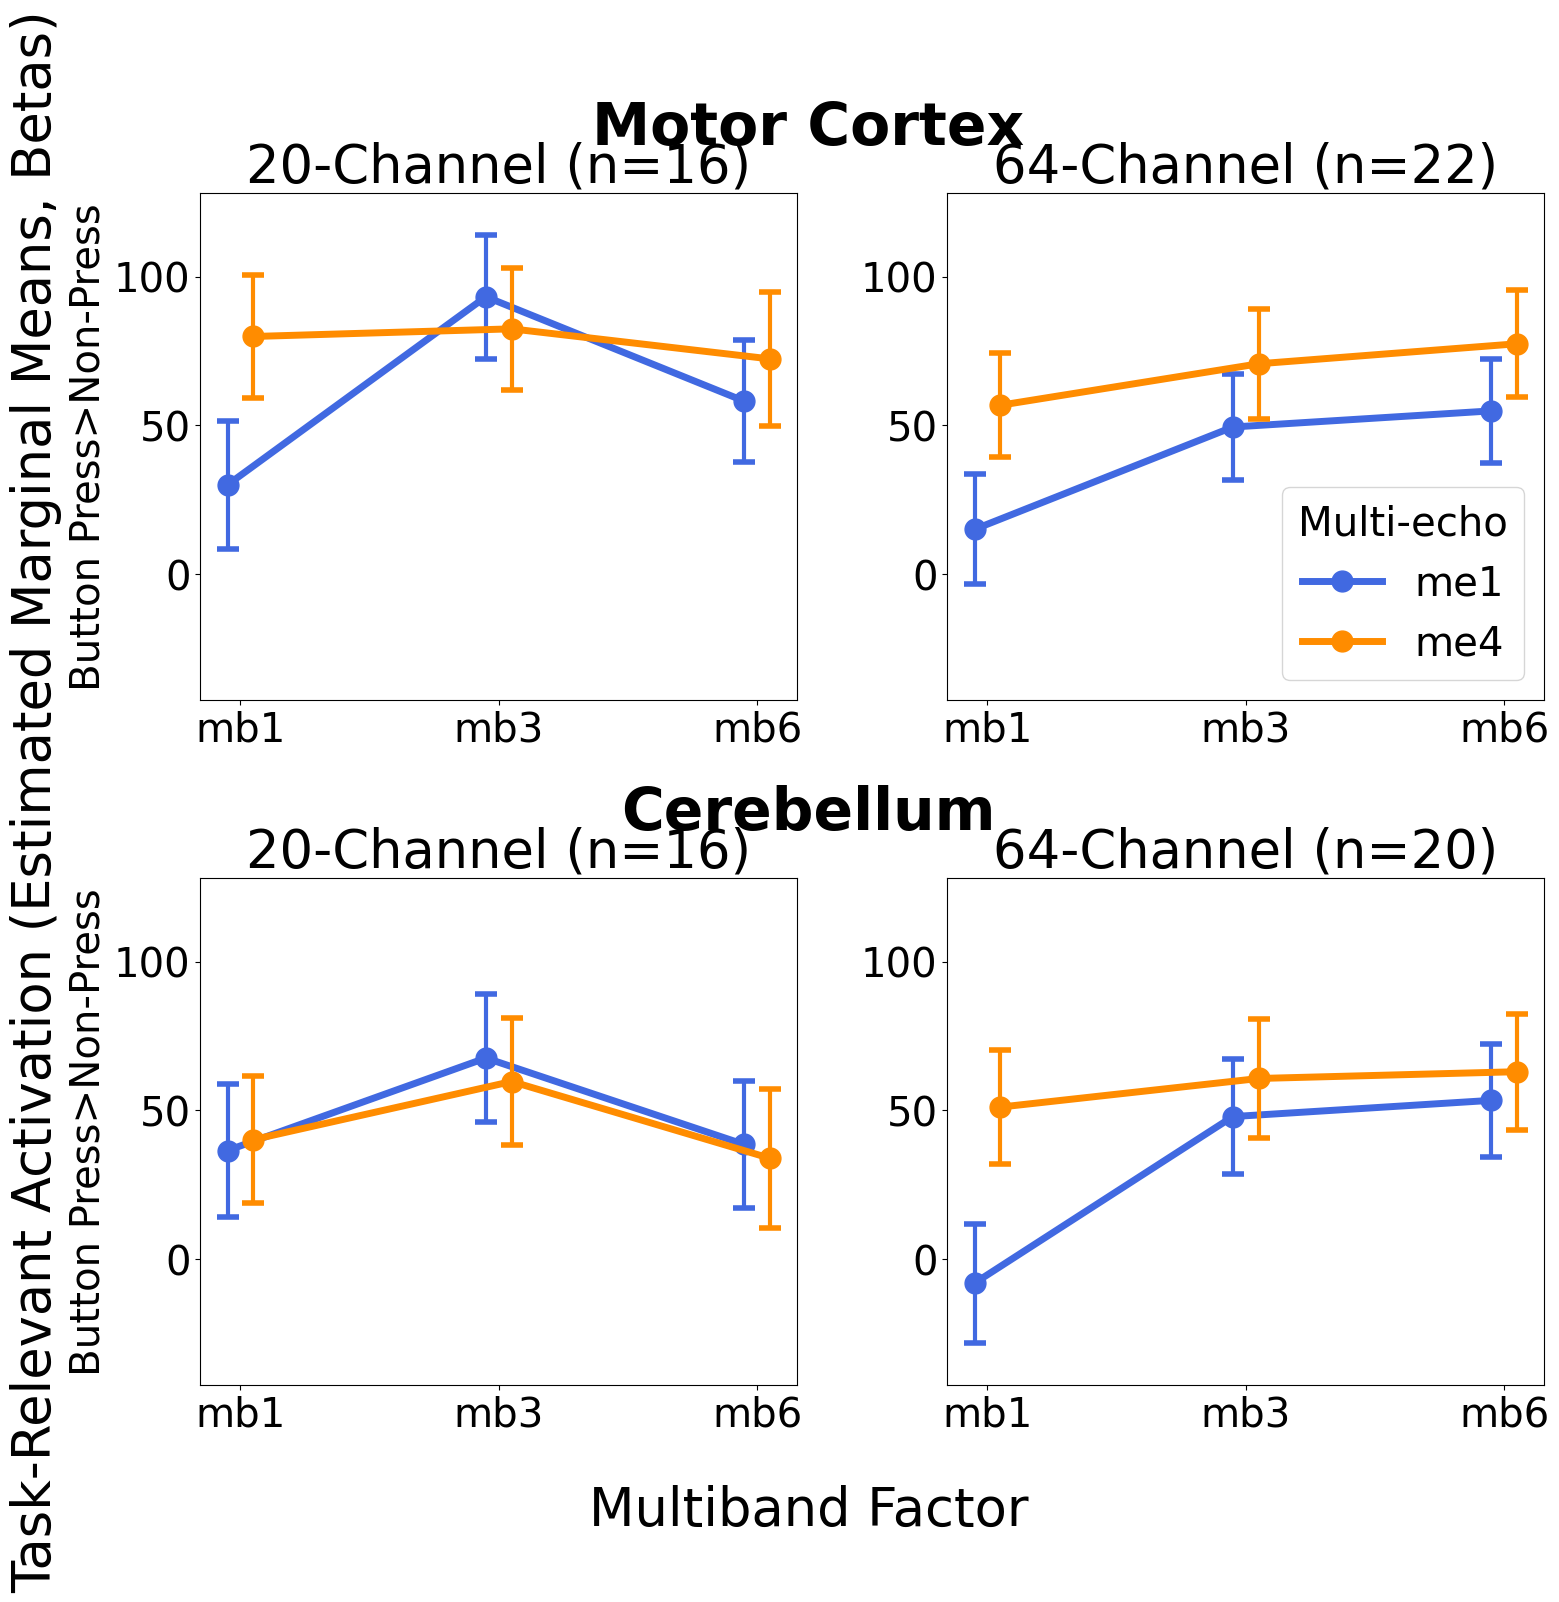


ANALYSIS COMPLETE — SUMMARY
  Motor Cortex: 38 total (16 20-ch, 22 64-ch)
  Cerebellum: 36 total (16 20-ch, 20 64-ch)

################################################################################
# MOTOR VS CEREBELLUM — Z-STAT (SUPPLEMENT)
################################################################################

MOTOR VS CEREBELLUM ROI COMPARISON — Z-STAT ANALYSIS WITH EMMs

PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS

Processing bilateralMotor...
  Complete bilateralMotor subjects: 38
  Common complete subjects: 38

Processing bilateralCerebellum...
  Complete bilateralCerebellum subjects: 36
  Common complete subjects: 36
Computing EMMs for bilateralMotor...
Computing EMMs for bilateralCerebellum...

PART 2: COMBINED LINEAR MIXED EFFECTS ANALYSIS (MOTOR VS CEREBELLUM)

Combined dataset: 444 observations
Subjects: 38
ROI breakdown: {'bilateralMotor': 228, 'bilateralCerebellum': 216}
Linear mixed model fit by REML [’lmerMod’]
Formula: zstat~headcoil*mb*me*roi+sm

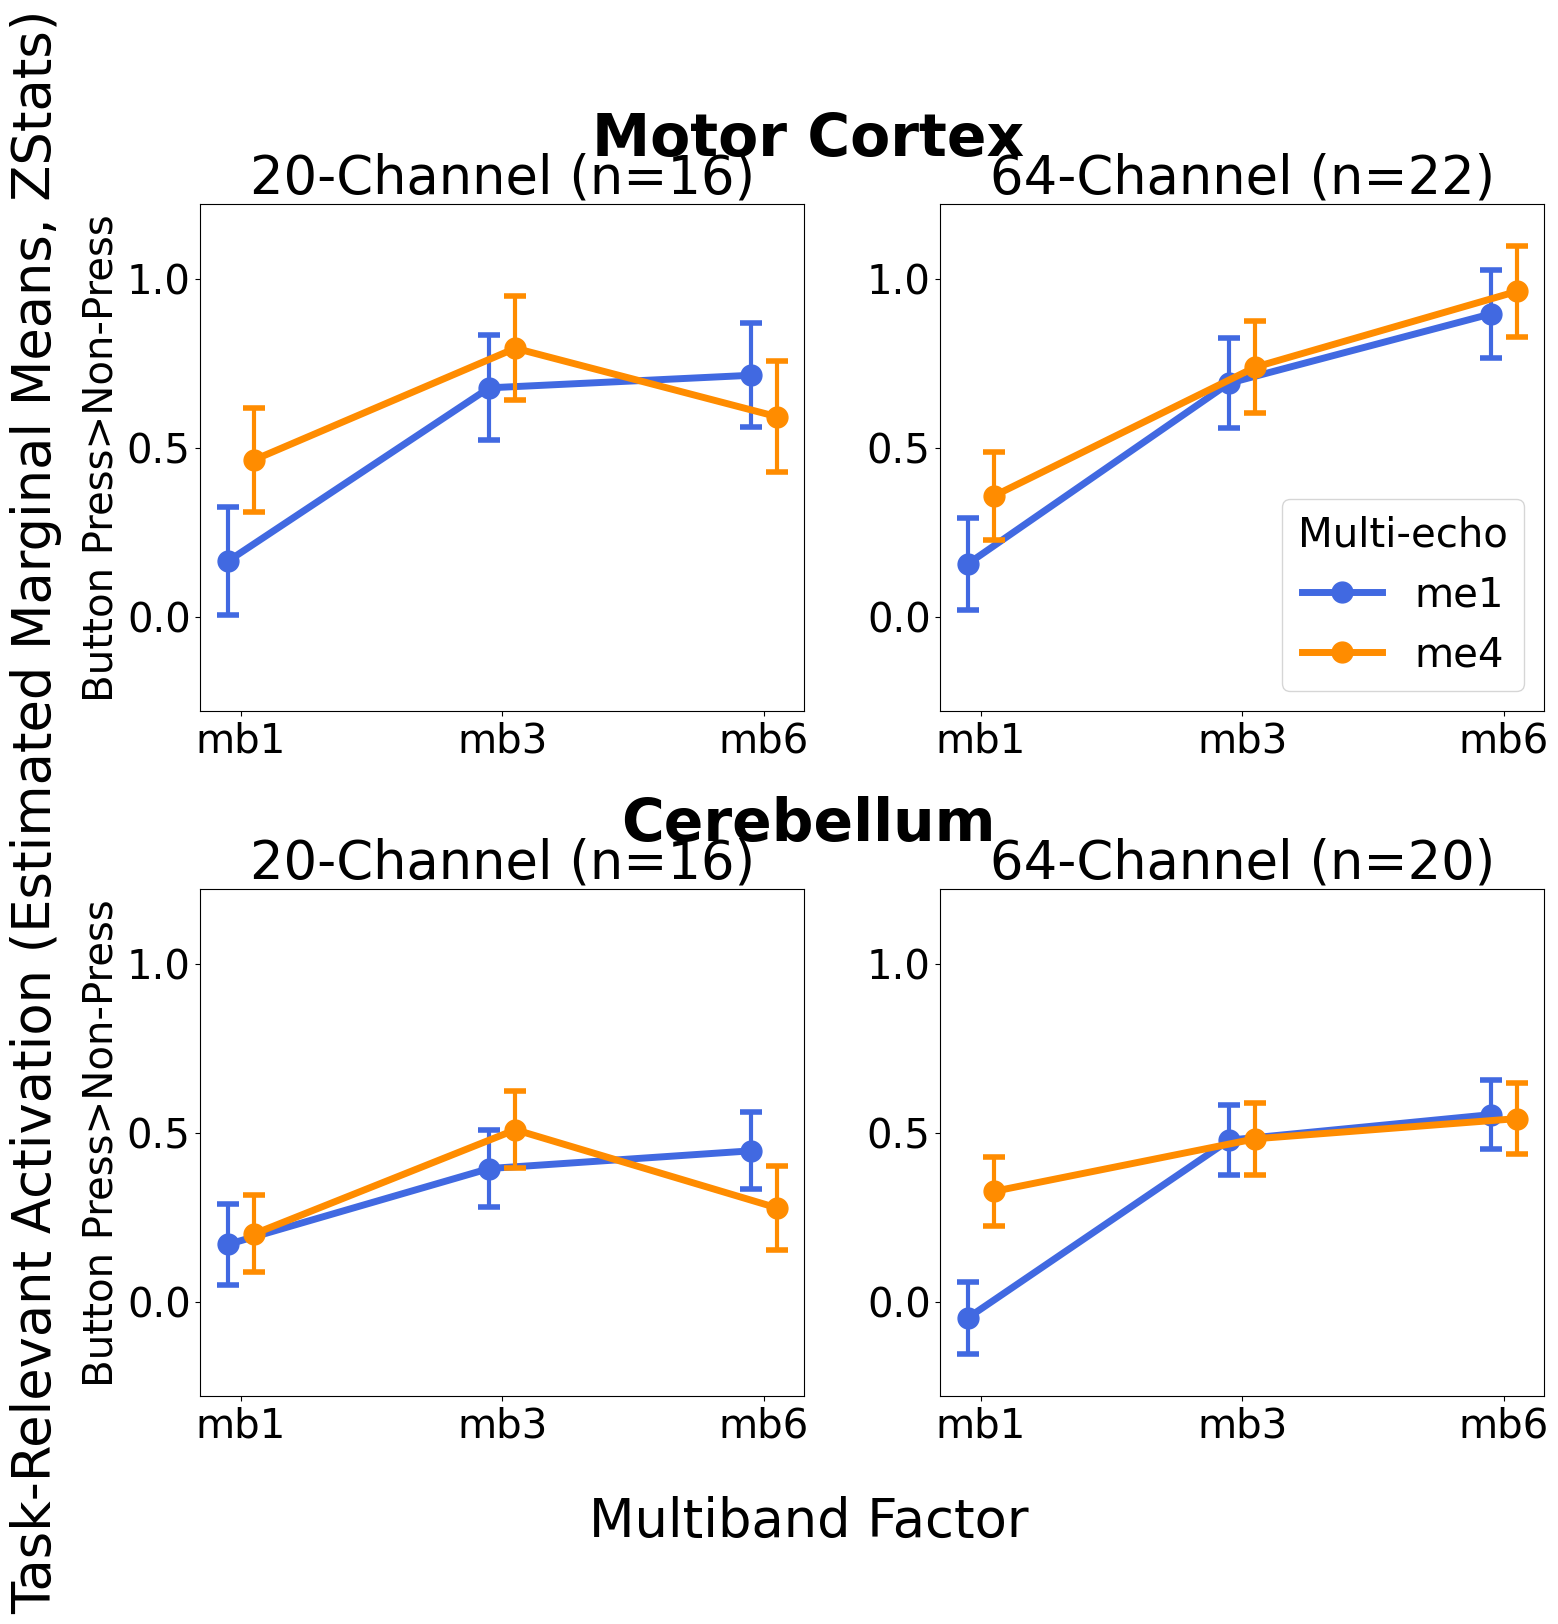


ANALYSIS COMPLETE — SUMMARY
  Motor Cortex: 38 total (16 20-ch, 22 64-ch)
  Cerebellum: 36 total (16 20-ch, 20 64-ch)


In [17]:
# =============================================================================
# MOTOR VS CEREBELLUM ROI COMPARISON — BETA AND Z-STAT
# =============================================================================

def run_motor_cerebellum_comparison(img_value, valid_subjects, headcoil_mapping,
                                    smoothness_data, complete_smoothness):
    """
    Run the Motor vs Cerebellum comparison analysis for a given image type.

    This includes:
    1. Per-ROI data loading and EMM computation
    2. Combined 4-factor LME (HC * MB * ME * ROI + smoothness)
    3. Comparison visualization
    """
    config = ROI_CONFIGS['motor_cerebellum']
    rois = config['rois']
    roi_labels = config['labels']
    roi_ylabels = config['ylabels']

    label_map = {'beta': 'Beta', 'zstat': 'Z-Stat'}
    label = label_map.get(img_value, img_value)

    print("=" * 80)
    print(f"MOTOR VS CEREBELLUM ROI COMPARISON — {label.upper()} ANALYSIS WITH EMMs")
    print("=" * 80)

    # Part 1: Load data and compute per-ROI EMMs
    print("\n" + "=" * 80)
    print("PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS")
    print("=" * 80)

    roi_results = load_and_merge_roi_data(
        rois, img_value, smoothness_data, complete_smoothness,
        valid_subjects, headcoil_mapping
    )

    emm_results = {}
    for roi in rois:
        if roi in roi_results:
            print(f"Computing EMMs for {roi}...")
            emm_results[roi] = compute_emms(roi_results[roi]['data'], img_value, roi)

    # Part 2: Combined ROI LME analysis
    print("\n" + "=" * 80)
    print("PART 2: COMBINED LINEAR MIXED EFFECTS ANALYSIS (MOTOR VS CEREBELLUM)")
    print("=" * 80)

    combined_roi_data = []
    for roi in rois:
        if roi in roi_results:
            rd = roi_results[roi]['data'].copy()
            rd['roi'] = roi
            combined_roi_data.append(rd)

    if len(combined_roi_data) == 2:
        combined_df = pd.concat(combined_roi_data, ignore_index=True)
        combined_df['roi'] = pd.Categorical(combined_df['roi'], categories=rois)

        print(f"\nCombined dataset: {len(combined_df)} observations")
        print(f"Subjects: {combined_df['subject'].nunique()}")
        print(f"ROI breakdown: {combined_df['roi'].value_counts().to_dict()}")

        # Fit 4-factor model
        model = Lmer(f'{img_value} ~ headcoil * mb * me * roi + smoothness + (1 | subject)',
                     data=combined_df)
        model.fit()
        anova_results = model.anova()

        apa_table = build_apa_table(model, anova_results,
                                     ROI_COMPARISON_EFFECT_NAMES, ROI_COMPARISON_DF_DICT)

        print(f"\nAPA-Style ANOVA Table for Motor vs Cerebellum ROI Analysis:")
        print(f"Model: {img_value} ~ headcoil * mb * me * roi + smoothness + (1 | subject)\n")
        print(apa_table.to_string(index=False))

        anova_file = output_dir / f'motor_cerebellum_roi_{img_value}_lme_anova_with_smoothness.csv'
        apa_table.to_csv(anova_file, index=False)
        print(f"\nSaved to '{anova_file.name}'")
    else:
        print("Could not find both Motor and Cerebellum ROI data for combined analysis")

    # Part 3: Visualization
    print("\n" + "=" * 80)
    print("PART 3: GENERATING MOTOR VS CEREBELLUM COMPARISON EMM PLOTS")
    print("=" * 80)

    plot_file = output_dir / f'motor_cerebellum_{img_value}_emm_comparison_plot.png'
    generate_emm_grid_plot(rois, roi_labels, roi_ylabels, roi_results, emm_results,
                           img_value, plot_file, legend_loc='lower right')

    # Summary
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE — SUMMARY")
    print("=" * 80)
    for roi in rois:
        if roi in roi_results:
            r = roi_results[roi]
            print(f"  {roi_labels[roi]}: {r['n_subjects']} total ({r['n_20ch']} 20-ch, {r['n_64ch']} 64-ch)")
    print("=" * 80)

    return roi_results, emm_results


# --- Run for Beta ---
print("\n" + "#" * 80)
print("# MOTOR VS CEREBELLUM — BETA")
print("#" * 80 + "\n")

mc_beta_results, mc_beta_emms = run_motor_cerebellum_comparison(
    'beta', valid_subjects, headcoil_mapping, smoothness_data, complete_smoothness
)

# --- Run for Z-Stat (Supplement) ---
print("\n" + "#" * 80)
print("# MOTOR VS CEREBELLUM — Z-STAT (SUPPLEMENT)")
print("#" * 80 + "\n")

mc_zstat_results, mc_zstat_emms = run_motor_cerebellum_comparison(
    'zstat', valid_subjects, headcoil_mapping, smoothness_data, complete_smoothness
)


# Weighted ROI Beta Activation Analysis (Fig. 8)
Inverse-variance weighted LME (weights = 1/varcope) via R's lmer. Weighted EMMs for three ROIs.

MULTI-ROI WEIGHTED BETA ANALYSIS PIPELINE
(Inverse-Variance Weighting from Varcope Images)
Processing weighted beta values for ROIs: VSconstrained, rFFA, bilateralMotor

PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS

Processing VSconstrained...
Complete beta: 38, varcope: 38
Common complete subjects: 38

Computing inverse-variance weights...
  Capped 3 weights at 99th percentile
  Weight stats: min=0.067, max=3.909, mean=1.000, std=0.845

Processing rFFA...
Complete beta: 38, varcope: 38
Common complete subjects: 38

Computing inverse-variance weights...
  Capped 3 weights at 99th percentile
  Weight stats: min=0.056, max=5.631, mean=1.000, std=1.013

Processing bilateralMotor...
Complete beta: 38, varcope: 38
Common complete subjects: 38

Computing inverse-variance weights...
  Capped 3 weights at 99th percentile
  Weight stats: min=0.020, max=3.955, mean=1.000, std=0.807

PART 2: WEIGHTED LINEAR MIXED EFFECTS ANALYSES

Ventral Striatum (VSconstrained)
N = 38 (16 20-ch, 22 64

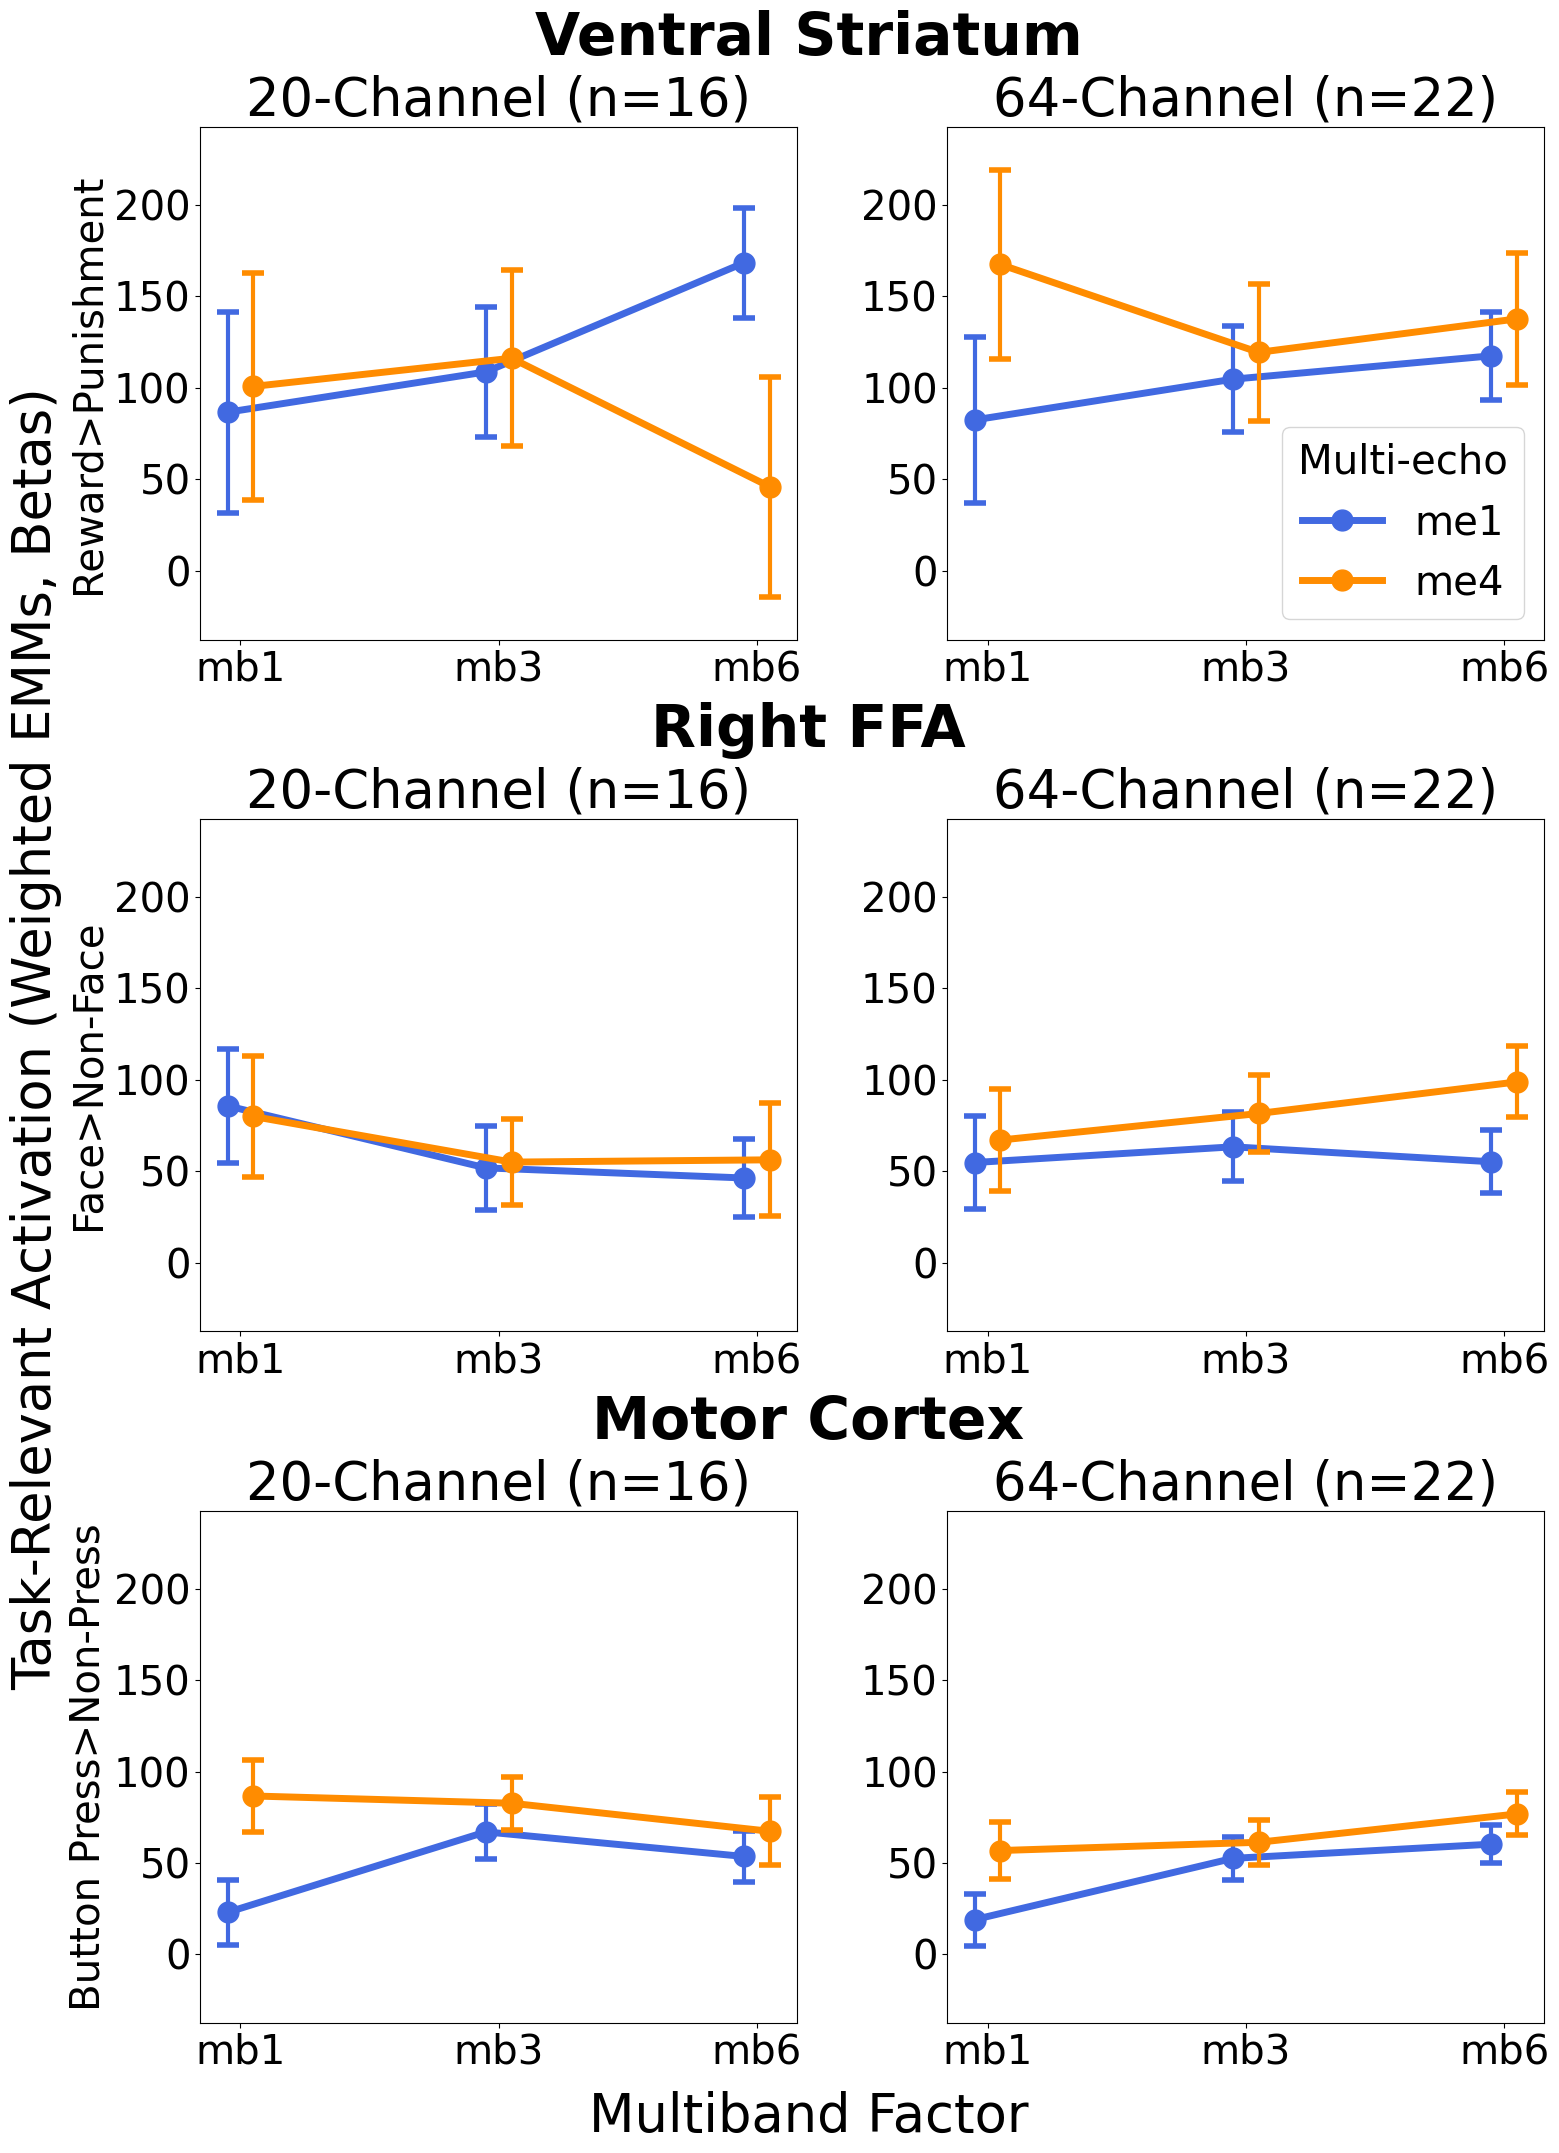


WEIGHT DISTRIBUTION DIAGNOSTICS

Ventral Striatum:
  Varcope range: [17532.746710, 1853866.933000]
  Varcope mean (SD): 243603.699852 (238891.197949)
  Weight range: [0.067, 3.909]

Right FFA:
  Varcope range: [1763.237025, 206262.303200]
  Varcope mean (SD): 26209.352961 (26982.314942)
  Weight range: [0.056, 5.631]

Motor Cortex:
  Varcope range: [2237.140000, 585536.000000]
  Varcope mean (SD): 25166.968904 (44358.807384)
  Weight range: [0.020, 3.955]

ANALYSIS COMPLETE - SUMMARY
Analysis: Inverse-variance weighted mixed effects (weights = 1/varcope)
  Ventral Striatum: 38 total (16 20-ch, 22 64-ch)
  Right FFA: 38 total (16 20-ch, 22 64-ch)
  Motor Cortex: 38 total (16 20-ch, 22 64-ch)

Weights winsorized at 99th percentile, normalized to mean=1.


In [19]:
# =============================================================================
# MULTI-ROI WEIGHTED BETA ANALYSIS (Inverse-Variance Weighting from Varcope)
# =============================================================================
# Dependencies: project_root, output_dir, extractions_dir, valid_subjects,
#               headcoil_mapping, smoothness_data, complete_smoothness,
#               extract_roi_data, identify_complete_subjects, ME_COLORS,
#               ROI_CONFIGS, TYPE_VALUE, DENOISE_VALUE,
#               MB_MAP, ME_MAP, HC_MAP, plot_emm_panel (from Setup)
#
# NOTE: This analysis uses lme4/lmerTest in R directly (not pymer4) because
# pymer4 doesn't support observation weights. Weights = 1/varcope.

print("=" * 80)
print("MULTI-ROI WEIGHTED BETA ANALYSIS PIPELINE")
print("(Inverse-Variance Weighting from Varcope Images)")
print("=" * 80)

# --- Config ---
ROIS_W = ROI_CONFIGS['3roi']['rois']
ROI_LABELS_W = ROI_CONFIGS['3roi']['labels']

combined_emm_plot_file = output_dir / 'multi_roi_weighted_beta_emm_plot.png'

print(f"Processing weighted beta values for ROIs: {', '.join(ROIS_W)}")

# =============================================================================
# LOCAL FUNCTIONS (unique to weighted analysis)
# =============================================================================

def prepare_weights(merged_data, winsorize_percentile=99, normalize=True):
    """
    Compute inverse-variance weights from varcope values.
    Winsorizes at given percentile and optionally normalizes to mean=1.
    """
    weights = 1.0 / merged_data['varcope']

    if winsorize_percentile < 100:
        weight_cap = np.percentile(weights, winsorize_percentile)
        weights = weights.clip(upper=weight_cap)
        n_capped = (weights == weight_cap).sum()
        if n_capped > 0:
            print(f"  Capped {n_capped} weights at {winsorize_percentile}th percentile")

    if normalize:
        weights = weights / weights.mean()

    return weights


def run_weighted_lme_analysis(merged_data, roi_name):
    """
    Fit weighted LME via lme4/lmerTest in R (pymer4 doesn't support weights).
    Returns APA table and the R-ready dataframe.
    """
    data_r = merged_data.rename(columns={
        'subject': 'Subj', 'headcoil': 'HC', 'mb': 'MB', 'me': 'ME',
        'beta': 'BetaValue', 'varcope': 'Varcope', 'weight': 'Weight'
    }).copy()

    data_r = data_r.dropna(subset=['BetaValue', 'Varcope', 'MB', 'ME', 'HC', 'Subj', 'smoothness', 'Weight'])
    for col in ['Subj', 'MB', 'ME', 'HC']:
        data_r[col] = data_r[col].astype(str)

    r_df = pandas2ri.py2rpy(data_r)
    ro.globalenv['model_data'] = r_df
    ro.globalenv['roi_name'] = roi_name

    ro.r('''
    library(lme4)
    library(lmerTest)

    model_data$MB <- factor(model_data$MB, levels = c("mb1", "mb3", "mb6"))
    model_data$ME <- factor(model_data$ME, levels = c("me1", "me4"))
    model_data$HC <- factor(model_data$HC, levels = c("20", "64"))

    weighted_model <- lmer(
        BetaValue ~ HC * MB * ME + smoothness + (1 | Subj),
        data = model_data,
        weights = Weight,
        REML = TRUE
    )

    assign(paste0("weighted_model_", roi_name), weighted_model, envir = .GlobalEnv)
    anova_result <- anova(weighted_model, type = 3, ddf = "Satterthwaite")
    ''')

    anova_r = ro.r('as.data.frame(anova_result)')
    anova_df = pandas2ri.rpy2py(anova_r)

    effect_names = {
        'HC': 'Head Coil', 'MB': 'Multiband', 'ME': 'Multi-echo',
        'smoothness': 'Smoothness',
        'HC:MB': 'Head Coil x Multiband', 'HC:ME': 'Head Coil x Multi-echo',
        'MB:ME': 'Multiband x Multi-echo', 'HC:MB:ME': 'Head Coil x Multiband x Multi-echo'
    }

    apa_data = []
    for effect in anova_df.index:
        effect_name = effect_names.get(effect, effect)
        apa_data.append({
            'Effect': effect_name,
            'Sum Sq': anova_df.loc[effect, 'Sum Sq'] if 'Sum Sq' in anova_df.columns else np.nan,
            'Mean Sq': anova_df.loc[effect, 'Mean Sq'] if 'Mean Sq' in anova_df.columns else np.nan,
            'Num df': anova_df.loc[effect, 'NumDF'] if 'NumDF' in anova_df.columns else (
                      anova_df.loc[effect, 'Df'] if 'Df' in anova_df.columns else np.nan),
            'Den df': anova_df.loc[effect, 'DenDF'] if 'DenDF' in anova_df.columns else np.nan,
            'F': anova_df.loc[effect, 'F value'] if 'F value' in anova_df.columns else (
                 anova_df.loc[effect, 'F.value'] if 'F.value' in anova_df.columns else np.nan),
            'p': anova_df.loc[effect, 'Pr(>F)'] if 'Pr(>F)' in anova_df.columns else (
                 anova_df.loc[effect, 'Pr..F.'] if 'Pr..F.' in anova_df.columns else np.nan)
        })

    apa_table = pd.DataFrame(apa_data)
    for col in ['Sum Sq', 'Mean Sq']:
        apa_table[col] = apa_table[col].round(4)
    apa_table['Num df'] = apa_table['Num df'].round(0).astype('Int64')
    apa_table['Den df'] = apa_table['Den df'].round(2)
    apa_table['F'] = apa_table['F'].round(2)
    apa_table['p'] = apa_table['p'].apply(
        lambda x: '< .001' if pd.notna(x) and x < 0.001 else f'{x:.3f}' if pd.notna(x) else 'N/A'
    )

    return apa_table, data_r


def compute_weighted_emms_for_roi(roi_name):
    """Compute EMMs from the weighted model stored in R's global env."""
    ro.globalenv['roi_name'] = roi_name

    ro.r('''
    library(emmeans)
    weighted_model <- get(paste0("weighted_model_", roi_name))
    emm <- emmeans(weighted_model, "MB", by = c("HC", "ME"))
    emm_df <- as.data.frame(emm)
    ''')

    emm_df = pandas2ri.rpy2py(ro.r('emm_df'))

    # Convert R factor integers back to strings
    if emm_df['MB'].dtype in ['int64', 'int32', 'float64']:
        emm_df['MB'] = emm_df['MB'].map(MB_MAP)
    if emm_df['ME'].dtype in ['int64', 'int32', 'float64']:
        emm_df['ME'] = emm_df['ME'].map(ME_MAP)
    if emm_df['HC'].dtype in ['int64', 'int32', 'float64']:
        emm_df['HC'] = emm_df['HC'].map(HC_MAP)

    return emm_df


# =============================================================================
# PART 1: LOAD DATA AND IDENTIFY COMPLETE SUBJECTS
# =============================================================================

print("\n" + "=" * 80)
print("PART 1: LOADING DATA AND IDENTIFYING COMPLETE SUBJECTS")
print("=" * 80)

# smoothness_data and complete_smoothness from Shared Deps cell

weighted_roi_results = {}
weighted_emm_results = {}

for roi in ROIS_W:
    print(f"\n{'='*60}")
    print(f"Processing {roi}...")
    print(f"{'='*60}")

    # Load beta and varcope data using shared extract_roi_data
    beta_data = extract_roi_data(extractions_dir, TYPE_VALUE, "beta",
                                  roi, DENOISE_VALUE, valid_subjects, headcoil_mapping)
    if beta_data is None:
        print(f"Warning: No beta data found for {roi}")
        continue

    varcope_data = extract_roi_data(extractions_dir, TYPE_VALUE, "varcope",
                                     roi, DENOISE_VALUE, valid_subjects, headcoil_mapping)
    if varcope_data is None:
        print(f"Warning: No varcope data found for {roi}")
        continue

    # Find common complete subjects across beta, varcope, and smoothness
    complete_beta = identify_complete_subjects(beta_data, 'beta')
    complete_varcope = identify_complete_subjects(varcope_data, 'varcope')
    print(f"Complete beta: {len(complete_beta)}, varcope: {len(complete_varcope)}")

    common_complete = sorted(list(
        set(complete_beta) & set(complete_varcope) & set(complete_smoothness)
    ))
    print(f"Common complete subjects: {len(common_complete)}")

    if not common_complete:
        print(f"No common complete subjects for {roi}")
        continue

    # Filter and merge: beta + varcope + smoothness
    beta_filt = beta_data[beta_data['subject'].isin(common_complete)]
    varcope_filt = varcope_data[varcope_data['subject'].isin(common_complete)]
    smooth_filt = smoothness_data[smoothness_data['subject'].isin(common_complete)]

    merged = pd.merge(
        beta_filt[['subject', 'headcoil', 'mb', 'me', 'beta']],
        varcope_filt[['subject', 'mb', 'me', 'varcope']],
        on=['subject', 'mb', 'me'], how='inner'
    )
    merged = pd.merge(
        merged,
        smooth_filt[['subject', 'mb', 'me', 'smoothness']],
        on=['subject', 'mb', 'me'], how='inner'
    ).dropna()

    # Compute weights
    print(f"\nComputing inverse-variance weights...")
    merged['weight'] = prepare_weights(merged, winsorize_percentile=99, normalize=True)

    print(f"  Weight stats: min={merged['weight'].min():.3f}, "
          f"max={merged['weight'].max():.3f}, "
          f"mean={merged['weight'].mean():.3f}, "
          f"std={merged['weight'].std():.3f}")

    n_small = (merged['varcope'] < 1e-6).sum()
    if n_small > 0:
        print(f"  Warning: {n_small} observations with very small varcope values")

    weighted_roi_results[roi] = {
        'data': merged,
        'n_subjects': merged['subject'].nunique(),
        'n_20ch': len(merged[merged['headcoil'] == '20']['subject'].unique()),
        'n_64ch': len(merged[merged['headcoil'] == '64']['subject'].unique()),
        'n_observations': len(merged)
    }

# =============================================================================
# PART 2: RUN WEIGHTED LME ANALYSES FOR ALL ROIS
# =============================================================================

print("\n" + "=" * 80)
print("PART 2: WEIGHTED LINEAR MIXED EFFECTS ANALYSES")
print("=" * 80)

for roi in ROIS_W:
    if roi not in weighted_roi_results:
        continue

    print(f"\n{'='*60}")
    print(f"{ROI_LABELS_W[roi]} ({roi})")
    print(f"{'='*60}")

    rd = weighted_roi_results[roi]
    print(f"N = {rd['n_subjects']} ({rd['n_20ch']} 20-ch, {rd['n_64ch']} 64-ch), "
          f"{rd['n_observations']} observations")

    print("\nFitting weighted mixed model...")
    apa_table, model_data = run_weighted_lme_analysis(rd['data'], roi)

    print(f"\nAPA-Style ANOVA Table (Weighted LME):")
    print(f"Model: beta ~ HC * MB * ME + smoothness + (1 | Subj), weights = 1/varcope")
    print(f"Data: {ROI_LABELS_W[roi]} ROI\n")
    print(apa_table.to_string(index=False))

    anova_file = output_dir / f'{roi}_weighted_beta_lme_anova.csv'
    apa_table.to_csv(anova_file, index=False)
    print(f"Saved to '{anova_file.name}'")

    print("\nComputing estimated marginal means...")
    emm_df = compute_weighted_emms_for_roi(roi)
    weighted_emm_results[roi] = emm_df

    emm_file = output_dir / f'{roi}_weighted_beta_emm.csv'
    emm_df.to_csv(emm_file, index=False)
    print(f"EMMs saved to '{emm_file.name}'")

# =============================================================================
# PART 3: COMBINED EMM VISUALIZATION
# =============================================================================

print("\n" + "=" * 80)
print("PART 3: GENERATING COMBINED EMM PLOTS")
print("=" * 80)

plt.rcParams.update({'font.size': 38})
fig, axes = plt.subplots(len(ROIS_W), 2, figsize=(16, 8 * len(ROIS_W)))

roi_ylabels_w = ROI_CONFIGS['3roi']['ylabels']

# Global y-limits across all ROIs
all_y, all_e = [], []
for roi in ROIS_W:
    if roi in weighted_emm_results:
        edf = weighted_emm_results[roi]
        all_y.extend(edf['emmean'].values)
        all_e.extend(edf['SE'].values)

if all_y:
    ymax = max(v + e for v, e in zip(all_y, all_e))
    ymin = min(v - e for v, e in zip(all_y, all_e))
    margin = (ymax - ymin) * 0.1
    y_limits_w = (ymin - margin, ymax + margin)
else:
    y_limits_w = (-1, 1)

for roi_idx, roi in enumerate(ROIS_W):
    if roi not in weighted_emm_results:
        continue

    emm_df = weighted_emm_results[roi]
    rd = weighted_roi_results[roi]

    # Use shared plot_emm_panel for each headcoil
    plot_emm_panel(axes[roi_idx, 0], emm_df, '20', rd['n_20ch'])
    axes[roi_idx, 0].set_ylim(y_limits_w)
    plot_emm_panel(axes[roi_idx, 1], emm_df, '64', rd['n_64ch'])
    axes[roi_idx, 1].set_ylim(y_limits_w)

    axes[roi_idx, 0].set_ylabel(roi_ylabels_w.get(roi, ''), fontsize=29)

axes[0, 1].legend(title='Multi-echo', fontsize=29, title_fontsize=29, loc='lower right')
fig.text(0.001, 0.5, 'Task-Relevant Activation (Weighted EMMs, Betas)',
         va='center', rotation='vertical', fontsize=38)
fig.supxlabel('Multiband Factor', fontsize=38, y=0.04)

plt.tight_layout()
fig.subplots_adjust(top=0.88, left=0.12, hspace=0.35)

for roi_idx, roi in enumerate(ROIS_W):
    if roi in weighted_emm_results:
        bbox = axes[roi_idx, 0].get_position()
        fig.text(0.5, bbox.y1 + 0.03, ROI_LABELS_W[roi],
                 ha='center', fontsize=42, fontweight='bold', transform=fig.transFigure)

plt.savefig(combined_emm_plot_file, dpi=300, bbox_inches='tight')
print(f"Combined weighted EMM plot saved to '{combined_emm_plot_file.name}'")
plt.show()

# =============================================================================
# PART 4: WEIGHT DISTRIBUTION DIAGNOSTICS
# =============================================================================

print("\n" + "=" * 80)
print("WEIGHT DISTRIBUTION DIAGNOSTICS")
print("=" * 80)

for roi in ROIS_W:
    if roi not in weighted_roi_results:
        continue
    data = weighted_roi_results[roi]['data']
    print(f"\n{ROI_LABELS_W[roi]}:")
    print(f"  Varcope range: [{data['varcope'].min():.6f}, {data['varcope'].max():.6f}]")
    print(f"  Varcope mean (SD): {data['varcope'].mean():.6f} ({data['varcope'].std():.6f})")
    print(f"  Weight range: [{data['weight'].min():.3f}, {data['weight'].max():.3f}]")

    if data['varcope'].min() < 1e-6:
        print(f"  Warning: Very small varcope values detected")
    ratio = data['weight'].max() / data['weight'].min()
    if ratio > 100:
        print(f"  Warning: Large weight ratio ({ratio:.1f}x)")

# =============================================================================
# SUMMARY
# =============================================================================

print(f"\n{'=' * 80}")
print("ANALYSIS COMPLETE - SUMMARY")
print(f"{'=' * 80}")
print(f"Analysis: Inverse-variance weighted mixed effects (weights = 1/varcope)")
for roi in ROIS_W:
    if roi in weighted_roi_results:
        r = weighted_roi_results[roi]
        print(f"  {ROI_LABELS_W[roi]}: {r['n_subjects']} total ({r['n_20ch']} 20-ch, {r['n_64ch']} 64-ch)")
print(f"\nWeights winsorized at 99th percentile, normalized to mean=1.")
print("=" * 80)

# Statistical Mask Analyses — PPI Beta & Z-stat (9 ROIs)
LME on PPI connectivity (seed: VS) within 9 statistical mask regions. Both beta and z-stat versions.

STATISTICAL MASKS ANALYSIS — BETA AND Z-STATS (9 PPI ROIs)
Timeseries directory: /Users/jameswyngaarden/Documents/GitHub/multiecho-pilot/derivatives/extractions
Processing 9 statistical masks x 2 image types (beta, zstat)

STATISTICAL MASKS BETA ANALYSIS - 9 ROIs

MASK 1/9: LME_output_FWER_3way_FINAL (beta)
Found 240 files
Parsed 228 observations, 38 subjects
Headcoil breakdown: {64: 132, 20: 96}
SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
ANOVA Results:
                       SS         MS  NumDF     DenomDF     F-stat     P-val  \
headcoil         5.246477   5.246477      1   35.999997   3.230956  0.080651   
mb              11.234122   5.617061      2  179.999995   3.459174  0.033562   
me               0.950226   0.950226      1  179.999995   0.585181  0.445290   
headcoil:mb      4.689543   2.344771      2  179.999995   1.443989  0.238705   
headcoil:me     12.430488

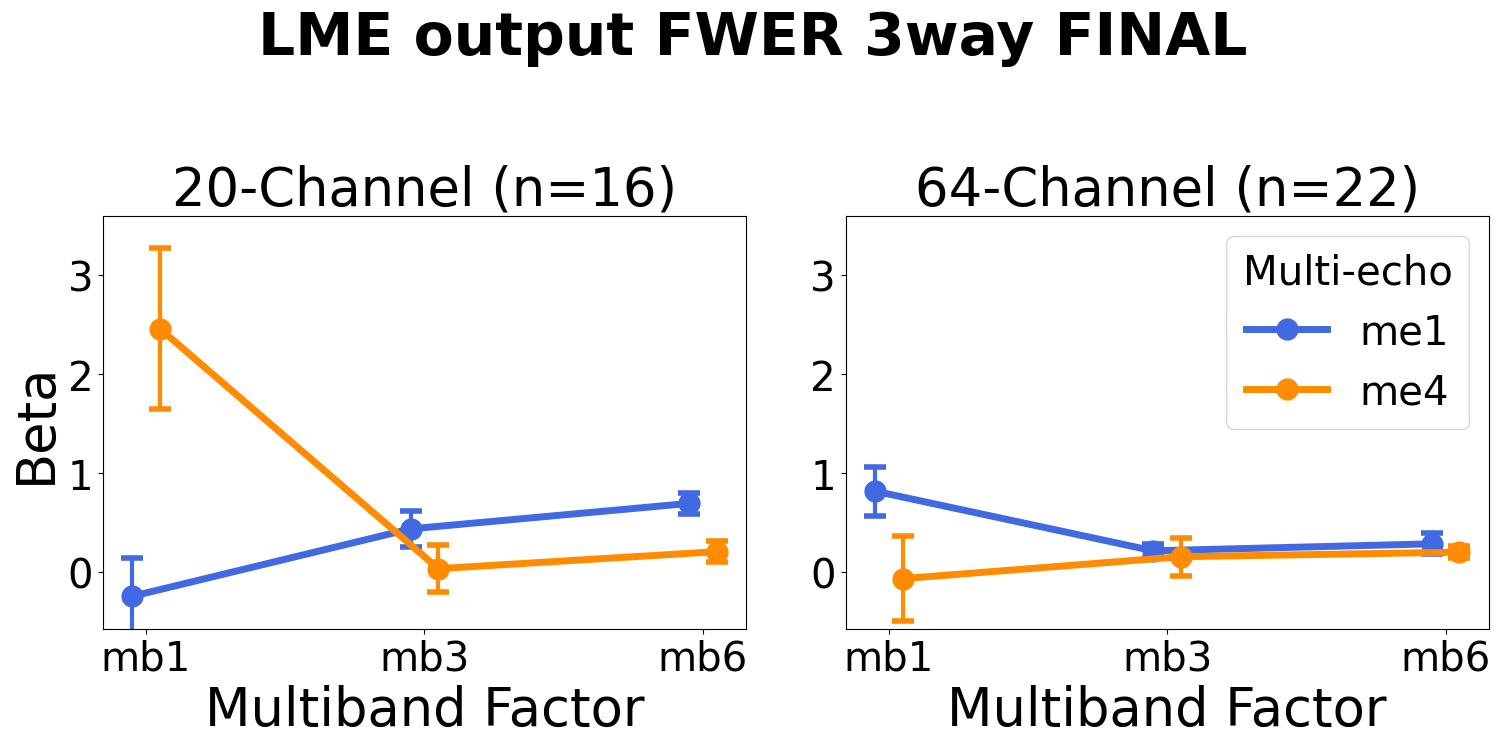

Completed LME_output_FWER_3way_FINAL (beta)

MASK 2/9: LME_output_FWER_HCxME_bonf (beta)
Found 240 files
Parsed 228 observations, 38 subjects
Headcoil breakdown: {64: 132, 20: 96}
SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
ANOVA Results:
                      SS        MS  NumDF  DenomDF     F-stat         P-val  \
headcoil        0.128809  0.128809      1     36.0   1.036558  3.154170e-01   
mb              0.503545  0.251773      2    180.0   2.026073  1.348484e-01   
me              2.144109  2.144109      1    180.0  17.254146  5.044940e-05   
headcoil:mb     2.508550  1.254275      2    180.0  10.093443  7.003564e-05   
headcoil:me     7.069207  7.069207      1    180.0  56.887557  2.197533e-12   
mb:me           0.269955  0.134977      2    180.0   1.086195  3.397000e-01   
headcoil:mb:me  2.487289  1.243645      2    180.0  10.007899  7.563776e-05   

            

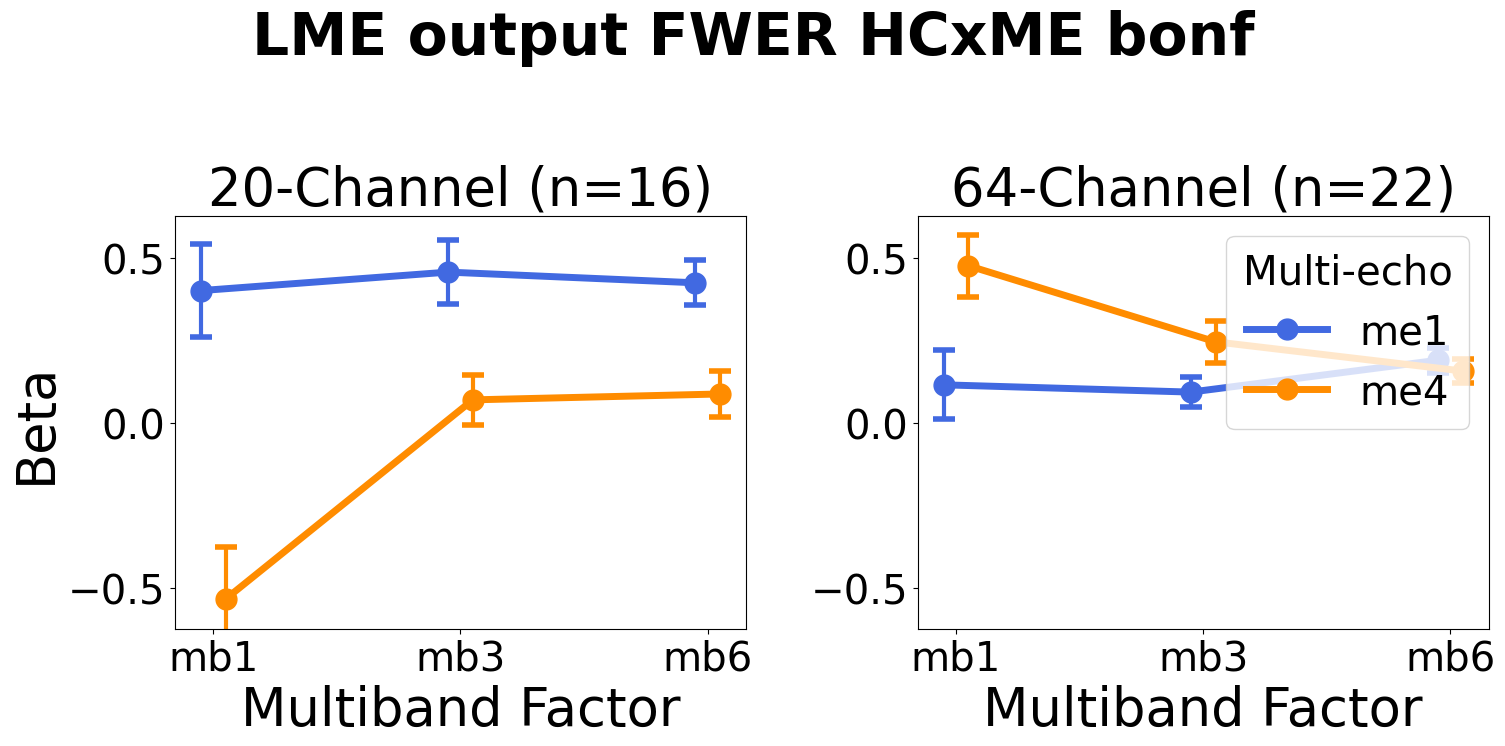

Completed LME_output_FWER_HCxME_bonf (beta)

MASK 3/9: LME_output_FWER_MBxME (beta)
Found 240 files
Parsed 228 observations, 38 subjects
Headcoil breakdown: {64: 132, 20: 96}
SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
ANOVA Results:
                       SS         MS  NumDF  DenomDF     F-stat         P-val  \
headcoil         1.348109   1.348109      1     36.0   2.914511  9.639847e-02   
mb              31.697269  15.848635      2    180.0  34.263568  2.459700e-13   
me              22.699947  22.699947      1    180.0  49.075596  4.746071e-11   
headcoil:mb      5.721557   2.860779      2    180.0   6.184790  2.524931e-03   
headcoil:me      3.266239   3.266239      1    180.0   7.061366  8.584808e-03   
mb:me           48.181861  24.090931      2    180.0  52.082798  1.422626e-18   
headcoil:mb:me  10.045218   5.022609      2    180.0  10.858507  3.529374e-05   

 

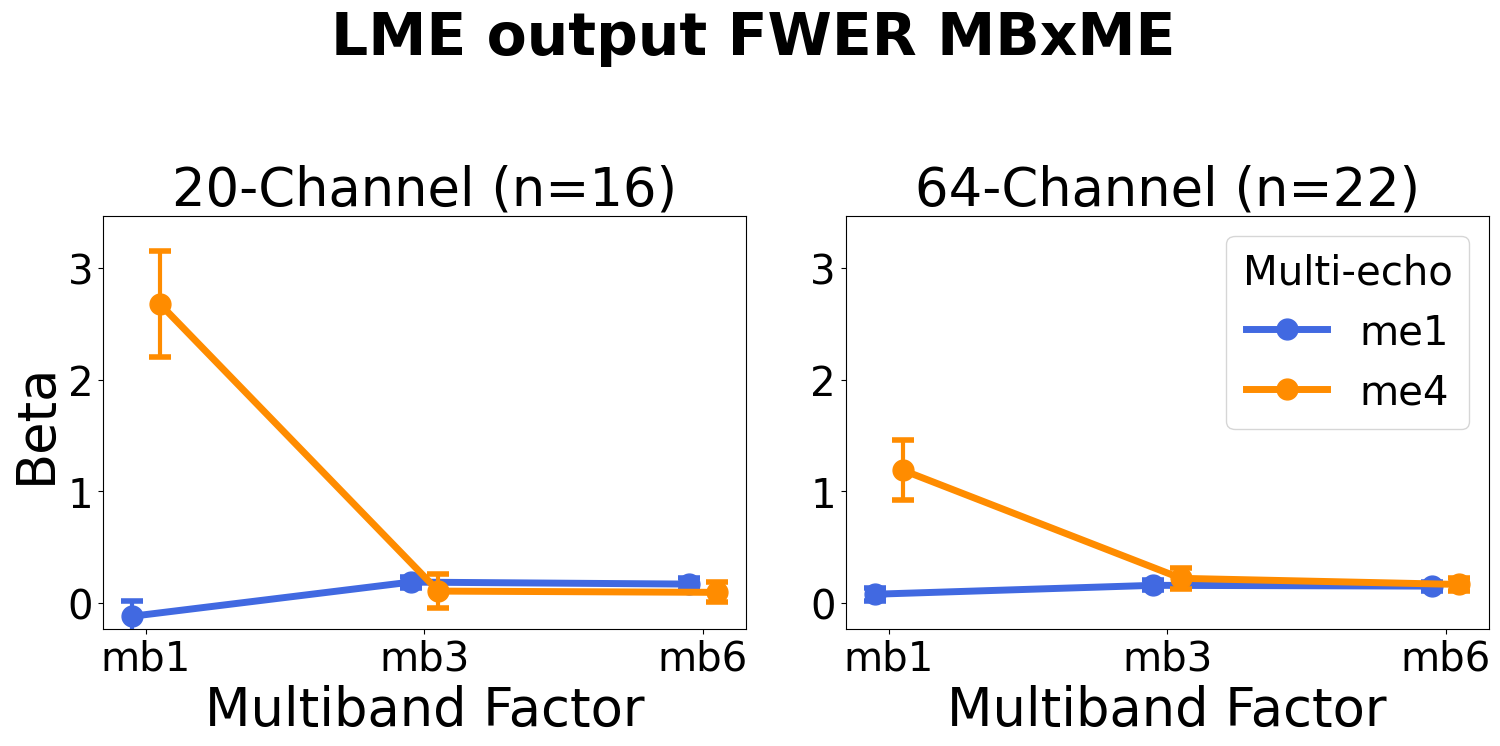

Completed LME_output_FWER_MBxME (beta)

MASK 4/9: LME_output_tsnr_MB3_vs_MB1_FDR (beta)
Found 240 files
Parsed 228 observations, 38 subjects
Headcoil breakdown: {64: 132, 20: 96}
SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
ANOVA Results:
                      SS        MS  NumDF  DenomDF    F-stat     P-val Sig
headcoil        0.038252  0.038252      1     36.0  0.830652  0.368147    
mb              0.025261  0.012630      2    180.0  0.274273  0.760442    
me              0.010709  0.010709      1    180.0  0.232561  0.630217    
headcoil:mb     0.003417  0.001709      2    180.0  0.037104  0.963583    
headcoil:me     0.005558  0.005558      1    180.0  0.120699  0.728684    
mb:me           0.309016  0.154508      2    180.0  3.355214  0.037098   *
headcoil:mb:me  0.278680  0.139340      2    180.0  3.025837  0.050992   .
ANOVA saved: anova_beta_LME_output_tsnr_MB3_vs

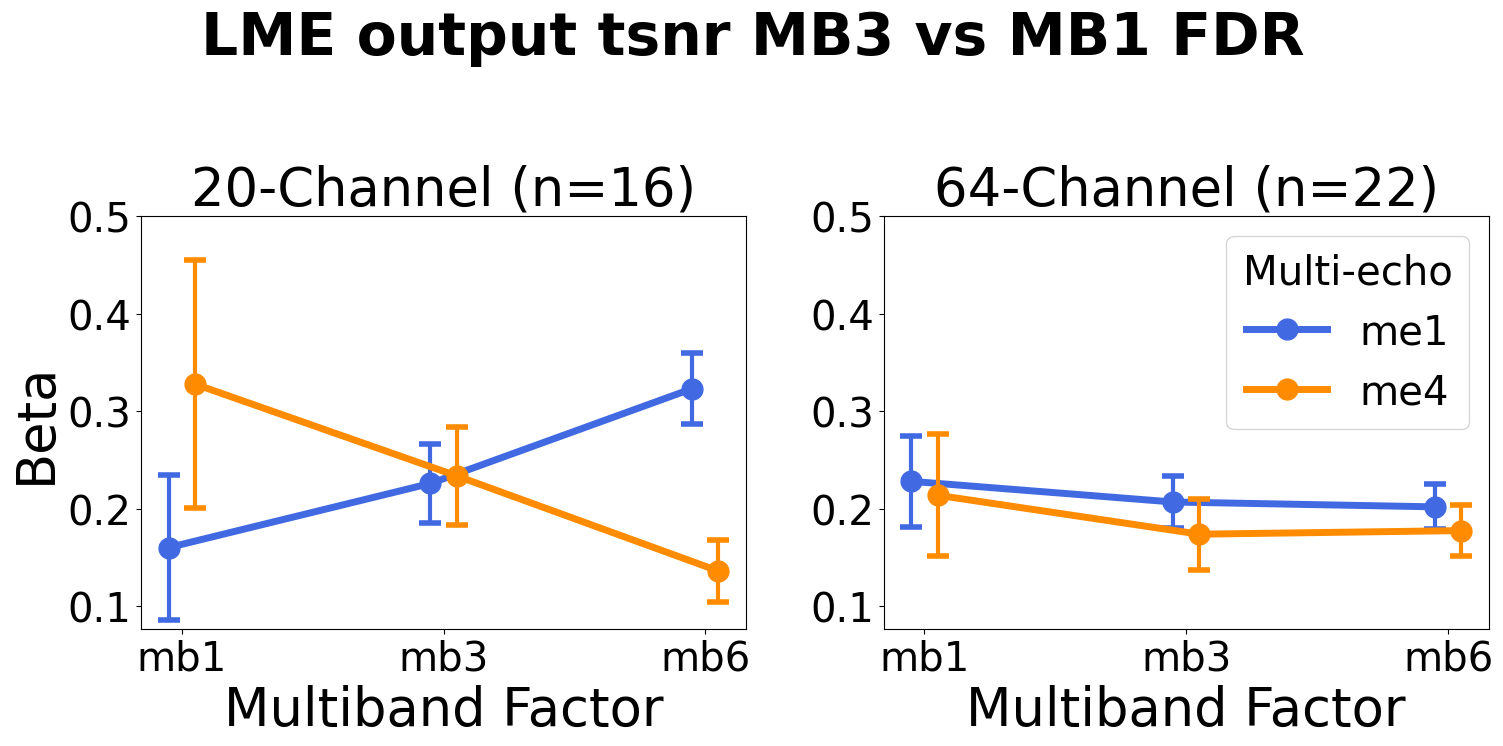

Completed LME_output_tsnr_MB3_vs_MB1_FDR (beta)

MASK 5/9: LME_output_FWER_ME_bonf (beta)
Found 240 files
Parsed 228 observations, 38 subjects
Headcoil breakdown: {64: 132, 20: 96}


In [ ]:
# =============================================================================
# STATISTICAL MASKS ANALYSIS — BETA AND Z-STATS (9 PPI ROIs)
# =============================================================================
# Consolidates original Cells 19 + 21 (600 lines -> ~200 lines)
# Dependencies: project_root, output_dir, main_df_final, valid_subjects,
#               headcoil_mapping, ME_COLORS (from Setup)

print("=" * 80)
print("STATISTICAL MASKS ANALYSIS — BETA AND Z-STATS (9 PPI ROIs)")
print("=" * 80)

# --- Config ---
timeseries_dir = project_root / 'derivatives' / 'extractions'

STAT_MASKS = [
    "LME_output_FWER_3way_FINAL",
    "LME_output_FWER_HCxME_bonf",
    "LME_output_FWER_MBxME",
    "LME_output_tsnr_MB3_vs_MB1_FDR",
    "LME_output_FWER_ME_bonf",
    "MB_main_ppi_zstat17_thresh",
    "MBxME_ppi_zstat17_thresh",
    "ME_main_ppi_zstat17_thresh",
    "overlap_ppi_zstat17_thr"
]

print(f"Timeseries directory: {timeseries_dir}")
print(f"Processing {len(STAT_MASKS)} statistical masks x 2 image types (beta, zstat)")


# =============================================================================
# CORE FUNCTION: run analysis for one image type across all masks
# =============================================================================

def run_stat_mask_analysis(img_type, stat_masks, timeseries_dir, valid_subjects,
                           headcoil_mapping, output_dir):
    """
    Run LME + visualization for all statistical masks for a given image type.

    Parameters
    ----------
    img_type : str
        'beta' or 'zstat'
    """
    print(f"\n{'='*80}")
    print(f"STATISTICAL MASKS {img_type.upper()} ANALYSIS - {len(stat_masks)} ROIs")
    print(f"{'='*80}")

    for mask_idx, mask in enumerate(stat_masks, 1):
        print(f"\n{'='*60}")
        print(f"MASK {mask_idx}/{len(stat_masks)}: {mask} ({img_type})")
        print(f"{'='*60}")

        # Find matching files
        pattern = f"ts_sub-*_acq_*_type-ppi_seed-VS_thr5_img-{img_type}_mask-{mask}_denoise_base.txt"
        files = list(timeseries_dir.glob(pattern))
        print(f"Found {len(files)} files")

        if not files:
            print(f"No {img_type} files found for mask: {mask}")
            continue

        # Parse filenames and extract data
        data_rows = []
        for file_path in files:
            parts = file_path.name.split('_')
            try:
                subject = parts[1].replace('sub-', '')
                acq_part = parts[3].replace('acq-', '')

                mb = next((f'mb{i}' for i in [1, 3, 6] if f'mb{i}' in acq_part), None)
                me = next((f'me{i}' for i in [1, 4] if f'me{i}' in acq_part), None)
                if not mb or not me:
                    continue

                if subject not in valid_subjects:
                    continue

                headcoil = headcoil_mapping.get(subject)
                if headcoil is None:
                    continue

                with open(file_path, 'r') as f:
                    value = float(f.read().strip())

                data_rows.append({
                    'subject': subject, 'mb': mb, 'me': me,
                    'headcoil': int(headcoil), img_type: value, 'mask': mask
                })
            except Exception as e:
                print(f"Error parsing {file_path.name}: {e}")
                continue

        if not data_rows:
            print(f"No valid data for mask: {mask}")
            continue

        df_mask = pd.DataFrame(data_rows)
        print(f"Parsed {len(df_mask)} observations, {df_mask['subject'].nunique()} subjects")
        print(f"Headcoil breakdown: {df_mask['headcoil'].value_counts().to_dict()}")

        # --- LME ---
        try:
            from pymer4.models import Lmer

            df_lme = df_mask.copy()
            for col in ['headcoil', 'mb', 'me', 'subject']:
                df_lme[col] = df_lme[col].astype('category')

            model = Lmer(f'{img_type} ~ headcoil * mb * me + (1|subject)', data=df_lme)
            model.fit(summarize=False)
            anova_results = model.anova()

            print("ANOVA Results:")
            print(anova_results)

            anova_file = output_dir / f"anova_{img_type}_{mask}.csv"
            anova_results.to_csv(anova_file)
            print(f"ANOVA saved: {anova_file.name}")

            summary_file = output_dir / f"lme_summary_{img_type}_{mask}.txt"
            with open(summary_file, 'w') as f:
                f.write(f"LME Analysis Results for {mask} ({img_type})\n")
                f.write("=" * 50 + "\n\n")
                f.write(f"Model: {img_type} ~ headcoil * mb * me + (1|subject)\n\n")
                f.write("ANOVA Results:\n")
                f.write(str(anova_results))
                f.write("\n\nModel Summary:\n")
                f.write(str(model))
            print(f"Summary saved: {summary_file.name}")

        except Exception as e:
            print(f"Error in LME analysis: {e}")

        # --- Visualization ---
        summary_stats = df_mask.groupby(['headcoil', 'mb', 'me'])[img_type].agg(['mean', 'sem']).reset_index()

        plt.rcParams.update({'font.size': 38})
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        headcoils = sorted(df_mask['headcoil'].unique())

        for i, hc in enumerate(headcoils):
            ax = axes[i]
            hc_data = summary_stats[summary_stats['headcoil'] == hc]

            x_positions = {'mb1': 0, 'mb3': 1, 'mb6': 2}
            jitter = {'me1': -0.05, 'me4': 0.05}

            for me_val in ['me1', 'me4']:
                me_data = hc_data[hc_data['me'] == me_val].sort_values('mb')
                x_vals = [x_positions[mb] + jitter[me_val] for mb in me_data['mb']]

                ax.plot(x_vals, me_data['mean'], marker='o', color=ME_COLORS[me_val],
                        label=me_val, linewidth=5, markersize=15)
                ax.errorbar(x_vals, me_data['mean'], yerr=me_data['sem'],
                            fmt='none', color=ME_COLORS[me_val],
                            capsize=8, capthick=4, elinewidth=3)

            n_subj = df_mask[df_mask['headcoil'] == hc]['subject'].nunique()
            ax.set_title(f'{hc}-Channel (n={n_subj})', fontsize=38)
            ax.set_xlabel('Multiband Factor', fontsize=38)
            ax.set_xticks([0, 1, 2])
            ax.set_xticklabels(['mb1', 'mb3', 'mb6'])
            ax.tick_params(axis='both', which='major', labelsize=29)

            if i == 0:
                ax.set_ylabel(img_type.capitalize(), fontsize=38)

        # Matched y-limits
        all_m = summary_stats['mean'].values
        all_s = summary_stats['sem'].values
        y_max = max(all_m + all_s) * 1.1
        y_min = min(all_m - all_s) * 0.9
        axes[0].set_ylim(y_min, y_max)
        axes[1].set_ylim(y_min, y_max)

        axes[1].legend(title='Multi-echo', fontsize=29, title_fontsize=29, loc='upper right')
        fig.suptitle(mask.replace("_", " "), fontsize=42, fontweight='bold', y=0.98)
        plt.tight_layout()

        plot_file = output_dir / f"{img_type}_{mask}.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved: {plot_file.name}")
        plt.show()

        # Save raw data
        data_file = output_dir / f"data_{img_type}_{mask}.csv"
        df_mask.to_csv(data_file, index=False)

        print(f"Completed {mask} ({img_type})")

    print(f"\n{'='*80}")
    print(f"ALL STATISTICAL MASKS {img_type.upper()} ANALYSIS COMPLETED")
    print(f"{'='*80}")


# =============================================================================
# RUN BOTH ANALYSES
# =============================================================================

run_stat_mask_analysis("beta", STAT_MASKS, timeseries_dir, valid_subjects,
                       headcoil_mapping, output_dir)

run_stat_mask_analysis("zstat", STAT_MASKS, timeseries_dir, valid_subjects,
                       headcoil_mapping, output_dir)

print(f"\nFiles per mask: anova_[type]_[mask].csv, lme_summary_[type]_[mask].txt, "
      f"[type]_[mask].png, data_[type]_[mask].csv")

# Design Matrix Preparation (Cells 11–14)
FD loading and echo consolidation, smoothness table generation, per-acquisition design matrices with proper de-meaning, and pairwise contrast matrices for FSL randomise.

In [ ]:
# =============================================================================
# FD MEAN DATA LOADING & MULTI-ECHO CONSOLIDATION
# =============================================================================
# Merges original Cells 23 + 24 (202 lines -> ~90 lines by removing duplicate loads)
# Produces: filtered_fd_df, consolidated_df (used by downstream design matrix cells)
# Dependencies: project_root (from Setup)

print("=" * 80)
print("LOADING FD_MEAN DATA AND CONSOLIDATING MULTI-ECHO ECHOES")
print("=" * 80)

BASE_CODE_DIR = project_root / 'code'
SUBLIST_PATH = BASE_CODE_DIR / 'sublist-complete.txt'
FD_TSV_PATH = project_root / 'derivatives' / 'Task-sharedreward_Level-Acq_Outlier-info_mriqc-0.16.1.tsv'

print(f"FD TSV data path: {FD_TSV_PATH}")
print(f"Subject list path: {SUBLIST_PATH}")

# --- Step 1: Load Master Subject List ---
with open(SUBLIST_PATH, 'r') as f:
    all_subjects_raw = sorted([line.strip() for line in f if line.strip()])
all_subjects_formatted = [f"sub-{s}" for s in all_subjects_raw]
print(f"Loaded {len(all_subjects_raw)} subjects")

# --- Step 2: Load and Truncate FD TSV ---
fd_new_df_raw = pd.read_csv(FD_TSV_PATH, sep=r'\s+')
print(f"Loaded {len(fd_new_df_raw)} records from FD TSV")

filtered_fd_df = fd_new_df_raw[fd_new_df_raw['Sub'].isin(all_subjects_formatted)].copy()
print(f"Truncated to {len(filtered_fd_df)} records for our subjects")

# Clean outlier column
filtered_fd_df['outlier_acq_Custom1'] = pd.to_numeric(
    filtered_fd_df['outlier_acq_Custom1'], errors='coerce'
).fillna(False).astype(bool)

# --- Step 3: Outlier Summary ---
outlier_runs = filtered_fd_df[filtered_fd_df['outlier_acq_Custom1'] == True]
print(f"\nOutlier runs: {len(outlier_runs)}")
if len(outlier_runs) > 0:
    print(outlier_runs)

# --- Step 4: Consolidate Multi-Echo Data ---
print("\n--- Consolidating Multi-Echo Data ---")

def get_consolidated_acq(acq_str):
    match = re.match(r'(mb\dme\d+)(_echo-\d+_part-mag)?', acq_str)
    return match.group(1) if match else acq_str

filtered_fd_df['consolidated_acq'] = filtered_fd_df['acq'].apply(get_consolidated_acq)

consolidated_df = filtered_fd_df.groupby(
    ['Sub', 'task', 'consolidated_acq'], as_index=False
).agg({
    'tsnr': 'mean',
    'fd_mean': 'mean',
    'outlier_acq_Custom1': 'any'
})
consolidated_df = consolidated_df.rename(columns={'consolidated_acq': 'acq'})
consolidated_df = consolidated_df[['Sub', 'task', 'acq', 'tsnr', 'fd_mean', 'outlier_acq_Custom1']]

print(f"Original rows: {len(filtered_fd_df)}")
print(f"Consolidated rows: {len(consolidated_df)}")

print("\n" + "=" * 80)
print("FD DATA LOADING AND CONSOLIDATION COMPLETE")
print("=" * 80)

In [ ]:
# =============================================================================
# SMOOTHNESS TABLE FOR MULTI-ECHO ACQUISITIONS
# =============================================================================
# Original Cell 25 (258 lines -> ~180 lines, stripped duplicate imports/config)
# Produces: smoothness_df (used by design matrix cells)
# Dependencies: project_root (from Setup)

print("=" * 80)
print("GENERATING SMOOTHNESS TABLE FOR MULTI-ECHO ACQUISITIONS")
print("=" * 80)

# --- Config ---
csv_path_smoothness_table = project_root / 'code' / 'smoothness-all.csv'
SUBLIST_PATH_ON = project_root / 'code' / 'sublist-openneuro.txt'

HEADCOIL_64_SUBJECTS = [
    "10015", "10017", "10024", "10028", "10035", "10041", "10043", "10046",
    "10054", "10059", "10069", "10074", "10078", "10080", "10085", "10094",
    "10108", "10125", "10130", "10136", "10137", "10142", "10150", "10154",
    "10186", "10188", "10221"
]

MULTI_ECHO_ACQS = ['mb1me4', 'mb3me4', 'mb6me4']
SMOOTHNESS_OUTPUT_CSV = project_root / 'code' / 'smoothness_multi_echo_table.csv'

print(f"Input smoothness file: {csv_path_smoothness_table}")
print(f"Subject list path: {SUBLIST_PATH_ON}")

# --- Step 1: Load Subject List (excluding SP) ---
with open(SUBLIST_PATH_ON, 'r') as f:
    all_subjects_raw_on = [line.strip() for line in f if line.strip()]

all_subjects_on = sorted([s for s in all_subjects_raw_on if not s.endswith('sp')])
print(f"Loaded {len(all_subjects_raw_on)} subjects, filtered to {len(all_subjects_on)} (excluding 'sp')")

# --- Step 2: Load and Process Smoothness Data ---
print("\n--- Processing Smoothness Data ---")

def get_consolidated_acq_name(acq_str):
    match = re.match(r'(mb\dme\d+)(?:_echo-\d+_part-mag)?', acq_str)
    return match.group(1) if match else acq_str

def load_and_process_smoothness_for_table(csv_path, subjects_list):
    """Load smoothness CSV with shift-up correction, filter to subjects, deduplicate."""
    raw_data = pd.read_csv(csv_path)
    data = raw_data.rename(columns={raw_data.columns[0]: 'path', 'Unnamed: 3': 'smoothness'})
    data['file_path'] = data['path'].shift(1)
    data['smoothness'] = pd.to_numeric(data['smoothness'], errors='coerce')
    data = data[data['smoothness'].notna() & data['file_path'].notna()].copy()
    data['file_path'] = data['file_path'].astype(str)

    path_pattern = r'sub-(\d+).*acq-([a-zA-Z0-9_.-]+)'
    records = []
    for _, row in data.iterrows():
        if row['file_path'] == 'nan' or not row['file_path'].strip():
            continue
        match = re.search(path_pattern, row['file_path'])
        if match:
            subject = match.group(1)
            acq = get_consolidated_acq_name(match.group(2))
            if subject in subjects_list:
                records.append({'subject': subject, 'acq': acq, 'smoothness': row['smoothness']})

    if not records:
        print("  No valid smoothness records found.")
        return pd.DataFrame(columns=['subject', 'headcoil', 'acq', 'smoothness'])

    df = pd.DataFrame(records)
    df['subject'] = df['subject'].astype(str)
    df['acq'] = df['acq'].astype(str)
    df['headcoil'] = df['subject'].apply(lambda x: '64' if x in HEADCOIL_64_SUBJECTS else '20')
    df = df[['subject', 'headcoil', 'acq', 'smoothness']].copy()

    # Deduplicate by averaging
    initial = len(df)
    df = df.groupby(['subject', 'headcoil', 'acq'], as_index=False)['smoothness'].mean()
    print(f"  Extracted {initial} records, deduplicated to {len(df)}")
    return df

smoothness_df = load_and_process_smoothness_for_table(csv_path_smoothness_table, all_subjects_on)

# --- Step 3: Create Display Table ---
print("\n--- Creating Final Smoothness Table ---")

if not smoothness_df.empty:
    smoothness_filtered_display = smoothness_df[smoothness_df['acq'].isin(MULTI_ECHO_ACQS)].copy()

    base_combos = pd.MultiIndex.from_product(
        [all_subjects_on, MULTI_ECHO_ACQS], names=['subject', 'acq']
    ).to_frame(index=False)

    final_display = pd.merge(
        base_combos,
        smoothness_filtered_display[['subject', 'acq', 'smoothness']],
        on=['subject', 'acq'], how='left'
    )

    smoothness_pivot_display = final_display.pivot_table(
        values='smoothness', index='subject', columns='acq', aggfunc='first'
    ).reindex(columns=MULTI_ECHO_ACQS)

    hc_info = pd.DataFrame({
        'subject': all_subjects_on,
        'headcoil': ['64' if s in HEADCOIL_64_SUBJECTS else '20' for s in all_subjects_on]
    }).set_index('subject')

    smoothness_pivot_display = smoothness_pivot_display.merge(hc_info, left_index=True, right_index=True, how='left')
    smoothness_pivot_display = smoothness_pivot_display[['headcoil'] + MULTI_ECHO_ACQS].sort_index()
    smoothness_pivot_display[MULTI_ECHO_ACQS] = smoothness_pivot_display[MULTI_ECHO_ACQS].round(3)

    pd.set_option('display.max_rows', None)
    print(f"\nFinal Smoothness Table:")
    print(smoothness_pivot_display.to_string())
    pd.reset_option('display.max_rows')

    smoothness_pivot_display.to_csv(SMOOTHNESS_OUTPUT_CSV)
    print(f"\nSaved to '{SMOOTHNESS_OUTPUT_CSV}'")

    # Missing data summary
    print(f"\nMissing smoothness data:")
    for acq in MULTI_ECHO_ACQS:
        missing = smoothness_pivot_display[acq].isna().sum()
        if missing > 0:
            subs = smoothness_pivot_display[smoothness_pivot_display[acq].isna()].index.tolist()
            print(f"  {acq}: {missing} subjects: {subs}")
        else:
            print(f"  {acq}: None missing")
else:
    print("Error: Smoothness data could not be loaded.")

print("\n" + "=" * 80)
print("SMOOTHNESS TABLE GENERATION COMPLETE")
print("=" * 80)

In [ ]:
# =============================================================================
# GROUP-LEVEL DESIGN MATRICES FOR RANDOMISE
# =============================================================================
# Original Cell 27 (411 lines -> ~340 lines, stripped duplicate imports/config)
# This is the CORRECTED version with proper de-meaning after all filtering.
# Dependencies: project_root, smoothness_df (from Cell 12), consolidated_df (from Cell 11)
# Produces: design_matrices dict (used by TEDANA cells)

print("=" * 80)
print("GENERATING GROUP-LEVEL DESIGN MATRICES FOR RANDOMISE")
print("  (Using Consolidated FD_MEAN and Pre-Processed Smoothness Table)")
print("  *** Ensured proper de-meaning after all filtering ***")
print("=" * 80)

# --- Configuration ---
BASE_CODE_DIR = project_root / 'code'
SUBLIST_PATH_DM = BASE_CODE_DIR / 'sublist-openneuro.txt'
FD_TSV_PATH_DM = project_root / 'derivatives' / 'Task-sharedreward_Level-Acq_Outlier-info_mriqc-0.16.1.tsv'
RECALCULATED_FD_PATH = BASE_CODE_DIR / 'missing_fd_mean_recalculated.csv'
SMOOTHNESS_TABLE_PATH = BASE_CODE_DIR / 'smoothness_multi_echo_table.csv'

HEADCOIL_64_SUBJECTS_DM = [
    "10015", "10017", "10024", "10028", "10035", "10041", "10043", "10046",
    "10054", "10059", "10069", "10074", "10078", "10080", "10085", "10094",
    "10108", "10125", "10130", "10136", "10137", "10142", "10150", "10154",
    "10186", "10188", "10221"
]

ACQ_TYPES_DM = ["mb1me4", "mb3me4", "mb6me4"]
DESIGN_MATRIX_OUTPUT_DIR = BASE_CODE_DIR / 'design_matrices'
DESIGN_MATRIX_OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Subject list: {SUBLIST_PATH_DM}")
print(f"FD TSV: {FD_TSV_PATH_DM}")
print(f"Recalculated FD: {RECALCULATED_FD_PATH}")
print(f"Smoothness table: {SMOOTHNESS_TABLE_PATH}")
print(f"Output: {DESIGN_MATRIX_OUTPUT_DIR}")

# --- Step 1: Load Subject List (excluding SP) ---
with open(SUBLIST_PATH_DM, 'r') as f:
    all_subjects_dm = sorted([s.strip() for s in f if s.strip() and not s.strip().endswith('sp')])
print(f"Loaded {len(all_subjects_dm)} subjects (excluding SP)")

# --- Step 2: Load, Truncate, and Consolidate FD Mean Data ---
print("\n--- Processing FD Mean Data ---")
fd_raw = pd.read_csv(FD_TSV_PATH_DM, sep=r'\s+')
fd_filtered = fd_raw[fd_raw['Sub'].isin([f"sub-{s}" for s in all_subjects_dm])].copy()
fd_filtered['subject'] = fd_filtered['Sub'].str.replace('sub-', '').astype(str)
fd_filtered['outlier_acq_Custom1'] = pd.to_numeric(
    fd_filtered['outlier_acq_Custom1'], errors='coerce'
).fillna(False).astype(bool)

def get_consolidated_acq_dm(acq_str):
    match = re.match(r'(mb\dme\d+)(_echo-\d+_part-mag)?', acq_str)
    return match.group(1) if match else acq_str

fd_filtered['consolidated_acq'] = fd_filtered['acq'].apply(get_consolidated_acq_dm)

temp_consolidated = fd_filtered.groupby(['subject', 'consolidated_acq'], as_index=False).agg({
    'tsnr': 'mean', 'fd_mean': 'mean', 'outlier_acq_Custom1': 'any'
}).rename(columns={'consolidated_acq': 'acq'})

base_combos = pd.MultiIndex.from_product(
    [all_subjects_dm, ACQ_TYPES_DM], names=['subject', 'acq']
).to_frame(index=False)
consolidated_fd_dm = pd.merge(base_combos, temp_consolidated, on=['subject', 'acq'], how='left')

print(f"Consolidated FD: {len(temp_consolidated)} records, padded to {len(consolidated_fd_dm)}")

# --- Step 2a: Incorporate Recalculated Missing FD Mean ---
print("\n--- Incorporating Recalculated FD Mean Data ---")
try:
    recalc_fd = pd.read_csv(RECALCULATED_FD_PATH)
    recalc_fd = recalc_fd.rename(columns={'acquisition': 'acq'})
    recalc_fd['subject'] = recalc_fd['subject'].astype(str)
    recalc_fd['fd_mean_recalc'] = pd.to_numeric(recalc_fd['fd_mean'], errors='coerce')

    nan_before = consolidated_fd_dm['fd_mean'].isna().sum()
    consolidated_fd_dm = pd.merge(
        consolidated_fd_dm,
        recalc_fd[['subject', 'acq', 'fd_mean_recalc']],
        on=['subject', 'acq'], how='left'
    )
    consolidated_fd_dm['fd_mean'] = consolidated_fd_dm['fd_mean'].fillna(consolidated_fd_dm['fd_mean_recalc'])
    consolidated_fd_dm = consolidated_fd_dm.drop(columns=['fd_mean_recalc'])
    nan_after = consolidated_fd_dm['fd_mean'].isna().sum()
    print(f"  NaNs before: {nan_before}, after: {nan_after}, filled: {nan_before - nan_after}")
except FileNotFoundError:
    print(f"  Recalculated FD file not found. Skipping.")

# --- Step 3: Load Pre-Processed Smoothness Table ---
print("\n--- Loading Pre-Processed Smoothness Table ---")
try:
    smoothness_table_dm = pd.read_csv(SMOOTHNESS_TABLE_PATH, index_col=0)
    smoothness_table_dm.index.name = 'subject'
    smoothness_table_dm = smoothness_table_dm.reset_index()
    smoothness_table_dm['subject'] = smoothness_table_dm['subject'].astype(str)

    smoothness_long_dm = smoothness_table_dm.melt(
        id_vars=['subject', 'headcoil'],
        value_vars=[c for c in smoothness_table_dm.columns if c.startswith('mb')],
        var_name='acq', value_name='smoothness'
    )
    smoothness_long_dm['smoothness'] = pd.to_numeric(smoothness_long_dm['smoothness'], errors='coerce')
    print(f"  Loaded {len(smoothness_long_dm)} smoothness records")
except FileNotFoundError:
    print(f"  Smoothness table not found at {SMOOTHNESS_TABLE_PATH}")
    smoothness_long_dm = pd.DataFrame(columns=['subject', 'acq', 'smoothness'])

# --- Step 4: Generate Headcoil Encoded Data ---
print("\n--- Generating Headcoil Data ---")
hc_map_dm = {s: 1 if s in HEADCOIL_64_SUBJECTS_DM else 0 for s in all_subjects_dm}
hc_series_dm = pd.DataFrame({'subject': list(hc_map_dm.keys()), 'headcoil_encoded': list(hc_map_dm.values())})
hc_series_dm['subject'] = hc_series_dm['subject'].astype(str)
print(f"Headcoil encoding for {len(hc_series_dm)} subjects")

# --- Step 5: Create Design Matrices ---
design_matrices = {}

for acq_type in ACQ_TYPES_DM:
    print(f"\n--- Constructing Design Matrix for {acq_type} ---")

    df = pd.DataFrame({'subject': all_subjects_dm})
    df['ones'] = 1

    # Merge FD
    fd_for_acq = consolidated_fd_dm[consolidated_fd_dm['acq'] == acq_type][['subject', 'fd_mean']].copy()
    df = pd.merge(df, fd_for_acq, on='subject', how='left')

    # Merge headcoil
    df = pd.merge(df, hc_series_dm, on='subject', how='left')

    df['fd_mean'] = pd.to_numeric(df['fd_mean'], errors='coerce')
    df['headcoil_encoded'] = pd.to_numeric(df['headcoil_encoded'], errors='coerce')

    # Merge smoothness
    if not smoothness_long_dm.empty:
        smooth_for_acq = smoothness_long_dm[smoothness_long_dm['acq'] == acq_type][['subject', 'smoothness']].copy()
        df = pd.merge(df, smooth_for_acq, on='subject', how='left')
        df['smoothness'] = pd.to_numeric(df['smoothness'], errors='coerce')
    else:
        df['smoothness'] = np.nan

    # Drop NaNs in FD
    missing_fd = df[df['fd_mean'].isna()]['subject'].tolist()
    if missing_fd:
        print(f"  Dropping {len(missing_fd)} subjects with missing FD: {missing_fd}")
        df = df.dropna(subset=['fd_mean']).copy()

    # Drop NaNs in smoothness
    missing_smooth = df[df['smoothness'].isna()]['subject'].tolist()
    if missing_smooth:
        print(f"  Dropping {len(missing_smooth)} subjects with missing smoothness: {missing_smooth}")
        df = df.dropna(subset=['smoothness']).copy()

    # De-mean on FINAL filtered set
    df['fd_mean_demeaned'] = df['fd_mean'] - df['fd_mean'].mean()
    df['headcoil_demeaned'] = df['headcoil_encoded'] - df['headcoil_encoded'].mean()
    df['smoothness_demeaned'] = df['smoothness'] - df['smoothness'].mean()

    interaction_raw = df['fd_mean_demeaned'] * df['headcoil_demeaned']
    df['fd_mean_x_headcoil_demeaned'] = interaction_raw - interaction_raw.mean()

    design_matrix_df = df[['subject', 'ones', 'fd_mean_demeaned', 'headcoil_demeaned',
                            'fd_mean_x_headcoil_demeaned', 'smoothness_demeaned']].copy()

    design_matrices[acq_type] = design_matrix_df
    print(f"  Created: {len(design_matrix_df)} subjects")
    print(f"  NaN check — FD: {design_matrix_df['fd_mean_demeaned'].isna().sum()}, "
          f"Smoothness: {design_matrix_df['smoothness_demeaned'].isna().sum()}")

# --- Display Sample ---
print("\n" + "=" * 80)
print("SAMPLE DESIGN MATRICES")
print("=" * 80)
for acq_type, df in design_matrices.items():
    print(f"\n--- {acq_type} (first 5 rows) ---")
    print(df.head().to_string())

# --- Save ---
print("\n" + "=" * 80)
print(f"SAVING TO: {DESIGN_MATRIX_OUTPUT_DIR}")
print("=" * 80)
for acq_type, df in design_matrices.items():
    out_file = DESIGN_MATRIX_OUTPUT_DIR / f'design_matrix_{acq_type}.csv'
    df.to_csv(out_file, index=False)
    print(f"Saved '{out_file.name}' ({len(df)} rows)")

print("\nAll design matrices generated and saved.")
print("=" * 80)

In [ ]:
# =============================================================================
# PAIRWISE CONTRAST DESIGN MATRICES (FROM SCRATCH)
# =============================================================================
# Original Cell 35 (347 lines -> ~280 lines, stripped duplicate imports)
# Produces: Per-acq design matrices AND pairwise contrast matrices for randomise
# Dependencies: project_root (from Setup)
# NOTE: This cell is self-contained — loads its own subject list, FD, smoothness,
#       and headcoil data independently of the LME pipeline cells.

print("=" * 80)
print("GENERATING ALL DESIGN MATRICES FROM SCRATCH")
print("=" * 80)

CODE_DIR = project_root / 'code'
OUTPUT_DIR_PW = Path.home() / 'Desktop' / 'projects' / 'multiecho-pilot' / 'randomise' / 'models'

SUBJECT_LIST = CODE_DIR / 'sublist-randomise.txt'
FD_EXCEL = CODE_DIR / 'outputs' / 'tables' / 'fd_mean_averages.xlsx'
FD_MISSING = CODE_DIR / 'outputs' / 'tables' / 'missing_fd_mean_recalculated.csv'
SMOOTHNESS_CSV_PW = CODE_DIR / 'smoothness-all.csv'
HEADCOIL_20CH = CODE_DIR / 'sublist-20ch.txt'
HEADCOIL_64CH = CODE_DIR / 'sublist-64ch.txt'

print(f"Code directory: {CODE_DIR}")
print(f"Output directory: {OUTPUT_DIR_PW}")

# --- Step 1: Load Subject List ---
print("\n--- Loading Subject List ---")
with open(SUBJECT_LIST, 'r') as f:
    subjects_pw = [line.strip() for line in f if line.strip()]
print(f"Loaded {len(subjects_pw)} subjects")
subjects_formatted_pw = [f'sub-{s}' for s in subjects_pw]

# --- Step 2: Load and Combine FD Mean Data ---
print("\n--- Loading FD Mean Data ---")
fd_excel = pd.read_excel(FD_EXCEL)
fd_excel.columns = fd_excel.columns.str.strip()
print(f"  Excel: {len(fd_excel)} rows")

fd_missing = pd.read_csv(FD_MISSING)
fd_missing.columns = fd_missing.columns.str.strip()
fd_missing = fd_missing.rename(columns={'subject': 'Sub', 'acquisition': 'acq_base'})
fd_missing['Sub'] = 'sub-' + fd_missing['Sub'].astype(str)
fd_missing = fd_missing[fd_missing['fd_mean'].notna()]
print(f"  CSV (missing): {len(fd_missing)} rows")

fd_combined = pd.concat([fd_excel, fd_missing], ignore_index=True)
fd_combined = fd_combined.sort_values('Sub').drop_duplicates(subset=['Sub', 'acq_base'], keep='first')

fd_filtered_pw = fd_combined[fd_combined['Sub'].isin(subjects_formatted_pw)]
fd_pivot_pw = fd_filtered_pw.pivot(index='Sub', columns='acq_base', values='fd_mean')
fd_pivot_pw = fd_pivot_pw.reindex(subjects_formatted_pw)
print(f"  Combined: {len(fd_pivot_pw)} subjects x {len(fd_pivot_pw.columns)} acquisitions")

# --- Step 3: Load Smoothness Data ---
print("\n--- Loading Smoothness Data ---")
smoothness_raw_pw = pd.read_csv(SMOOTHNESS_CSV_PW)
smoothness_raw_pw = smoothness_raw_pw.rename(columns={
    smoothness_raw_pw.columns[0]: 'path', 'Unnamed: 3': 'smoothness'
})
smoothness_raw_pw['file_path'] = smoothness_raw_pw['path'].shift(1)
smoothness_data_pw = smoothness_raw_pw[
    smoothness_raw_pw['smoothness'].notna() & smoothness_raw_pw['file_path'].notna()
].reset_index(drop=True).copy()
print(f"  Loaded {len(smoothness_data_pw)} rows after shift-up correction")

def parse_smoothness_path_pw(path):
    try:
        if not isinstance(path, str):
            return pd.Series({'subject': None, 'acq': None})
        sub_match = re.search(r'sub-(\d+)', path)
        acq_match = re.search(r'acq-(mb\dme\d)', path)
        return pd.Series({
            'subject': sub_match.group(1) if sub_match else None,
            'acq': acq_match.group(1) if acq_match else None
        })
    except Exception:
        return pd.Series({'subject': None, 'acq': None})

parsed_pw = smoothness_data_pw['file_path'].apply(parse_smoothness_path_pw)
smoothness_data_pw[['subject', 'acq']] = parsed_pw
smoothness_data_pw = smoothness_data_pw.dropna(subset=['subject', 'acq']).reset_index(drop=True)
smoothness_data_pw = smoothness_data_pw[smoothness_data_pw['subject'].isin(subjects_pw)].reset_index(drop=True)
smoothness_data_pw = smoothness_data_pw[
    smoothness_data_pw['acq'].isin(['mb1me4', 'mb3me4', 'mb6me4'])
].reset_index(drop=True)

smoothness_data_pw['subject_formatted'] = 'sub-' + smoothness_data_pw['subject']
smoothness_data_pw = smoothness_data_pw.drop_duplicates(subset=['subject_formatted', 'acq'], keep='first')

smoothness_pivot_pw = smoothness_data_pw.pivot(
    index='subject_formatted', columns='acq', values='smoothness'
).reindex(subjects_formatted_pw)
print(f"  Pivoted: {len(smoothness_pivot_pw)} subjects x {len(smoothness_pivot_pw.columns)} acquisitions")

missing_count_pw = smoothness_pivot_pw.isna().sum().sum()
if missing_count_pw > 0:
    print(f"  WARNING: {missing_count_pw} missing smoothness values")

# --- Step 4: Load Headcoil Assignments ---
print("\n--- Loading Headcoil Assignments ---")
with open(HEADCOIL_20CH, 'r') as f:
    subjects_20ch = set(line.strip() for line in f if line.strip())
with open(HEADCOIL_64CH, 'r') as f:
    subjects_64ch = set(line.strip() for line in f if line.strip())
print(f"  20-channel: {len(subjects_20ch)}, 64-channel: {len(subjects_64ch)}")

headcoil_map_pw = {}
for sub in subjects_pw:
    if sub in subjects_64ch:
        headcoil_map_pw[f'sub-{sub}'] = 1
    elif sub in subjects_20ch:
        headcoil_map_pw[f'sub-{sub}'] = 0
    else:
        print(f"  WARNING: {sub} not in either headcoil list!")
        headcoil_map_pw[f'sub-{sub}'] = np.nan

headcoil_series_pw = pd.Series(headcoil_map_pw, name='hc').reindex(subjects_formatted_pw)

# --- Helper: Save FSL .mat ---
def save_fsl_mat(df, filepath):
    df_mat = df.drop(columns=['subject']) if 'subject' in df.columns else df
    with open(filepath, 'w') as f:
        f.write(f'/NumWaves\t{len(df_mat.columns)}\n')
        f.write(f'/NumPoints\t{len(df_mat)}\n')
        f.write('/Matrix\n')
        for _, row in df_mat.iterrows():
            f.write(' '.join(f'{val:.10f}' for val in row.values) + '\n')

# --- Step 5: Create Original Design Matrices ---
print("\n" + "=" * 80)
print("CREATING ORIGINAL DESIGN MATRICES")
print("=" * 80)

def create_design_matrix_pw(acq_name, fd_values, hc_values, smoothness_values):
    df = pd.DataFrame({'subject': subjects_formatted_pw})
    df['intercept'] = 1.0
    fd_dm = fd_values - fd_values.mean()
    df['fd_mean'] = fd_dm.values
    hc_dm = hc_values - hc_values.mean()
    df['hc'] = hc_dm.values
    interaction = df['fd_mean'] * df['hc']
    df['fd_mean_x_hc'] = (interaction - interaction.mean()).values
    smooth_dm = smoothness_values - smoothness_values.mean()
    df['smoothness'] = smooth_dm.values
    return df

acquisition_matrices_pw = {}
for acq in ['mb1me4', 'mb3me4', 'mb6me4']:
    print(f"\n{acq.upper()}:")
    fd_data = fd_pivot_pw[acq]
    smooth_data = smoothness_pivot_pw[acq]
    print(f"  FD: {fd_data.notna().sum()}/{len(fd_data)}, Smoothness: {smooth_data.notna().sum()}/{len(smooth_data)}")

    df = create_design_matrix_pw(acq, fd_data, headcoil_series_pw, smooth_data)
    acquisition_matrices_pw[acq] = df

    print(f"  Mean checks: fd={df['fd_mean'].mean():.10f}, hc={df['hc'].mean():.10f}, "
          f"interaction={df['fd_mean_x_hc'].mean():.10f}, smooth={df['smoothness'].mean():.10f}")

    acq_dir = OUTPUT_DIR_PW / acq
    acq_dir.mkdir(exist_ok=True)

    tsv_file = acq_dir / f'{acq}_design_matrix.tsv'
    df.drop(columns=['subject']).to_csv(tsv_file, sep='\t', index=False)
    print(f"  Saved TSV: {tsv_file.name}")

    mat_file = acq_dir / f'{acq}_design_matrix.mat'
    save_fsl_mat(df, mat_file)
    print(f"  Saved MAT: {mat_file.name}")

# --- Step 6: Create Contrast Design Matrices ---
print("\n" + "=" * 80)
print("CREATING CONTRAST DESIGN MATRICES")
print("=" * 80)

def create_contrast_matrix_pw(df_high, df_low, contrast_name):
    print(f"\n{contrast_name}:")
    n = len(df_high)
    cdf = pd.DataFrame({'intercept': np.ones(n)})
    cdf['fd_mean'] = df_high['fd_mean'].values - df_low['fd_mean'].values
    cdf['hc'] = df_high['hc'].values  # Same across acquisitions
    cdf['fd_mean_x_hc'] = df_high['fd_mean_x_hc'].values - df_low['fd_mean_x_hc'].values
    cdf['smoothness'] = df_high['smoothness'].values - df_low['smoothness'].values

    print(f"  fd_mean std: {cdf['fd_mean'].std():.6f}, smoothness std: {cdf['smoothness'].std():.6f}")
    return cdf

contrasts_pw = {
    'mb6me4_vs_mb1me4': (acquisition_matrices_pw['mb6me4'], acquisition_matrices_pw['mb1me4']),
    'mb3me4_vs_mb1me4': (acquisition_matrices_pw['mb3me4'], acquisition_matrices_pw['mb1me4']),
    'mb6me4_vs_mb3me4': (acquisition_matrices_pw['mb6me4'], acquisition_matrices_pw['mb3me4'])
}

for contrast_name, (df_high, df_low) in contrasts_pw.items():
    cdf = create_contrast_matrix_pw(df_high, df_low, contrast_name)
    contrast_dir = OUTPUT_DIR_PW / contrast_name
    contrast_dir.mkdir(exist_ok=True)

    tsv_file = contrast_dir / f'{contrast_name}_design_matrix.tsv'
    cdf.to_csv(tsv_file, sep='\t', index=False)
    print(f"  Saved TSV: {tsv_file.name}")

    mat_file = contrast_dir / f'{contrast_name}_design_matrix.mat'
    save_fsl_mat(cdf, mat_file)
    print(f"  Saved MAT: {mat_file.name}")

print("\n" + "=" * 80)
print("COMPLETE — 12 files total (6 TSV + 6 MAT)")
print("=" * 80)

# TEDANA Denoising Efficacy — Per-Acquisition ROI Analyses
ΔR² (tedana > base) vs. head motion for three ROIs, separately for MB1ME4, MB3ME4, and MB6ME4.

In [ ]:
# =============================================================================
# TEDANA BENEFIT ANALYSIS — DELTA R² BY ROI (PER ACQUISITION)
# =============================================================================
# Consolidates original Cells 29+30+31+32+33 (484 lines -> ~130 lines)
# Cells 29+30 were single-ROI explorations; 31+32+33 were identical 3-ROI
# analyses differing only in acquisition (mb1me4/mb3me4/mb6me4).
# Dependencies: project_root (from Setup)

from scipy import stats as sp_stats

print("=" * 80)
print("TEDANA BENEFIT ANALYSIS — DELTA R² BY ROI (PER ACQUISITION)")
print("=" * 80)

# --- Config ---
MODELS_DIR = Path.home() / 'Desktop' / 'projects' / 'multiecho-pilot' / 'randomise' / 'models'

TEDANA_ACQS = ['mb1me4', 'mb3me4', 'mb6me4']

TEDANA_ROIS = {
    'VS': {'label': 'Ventral Striatum', 'ylabel': 'Reward>Punishment'},
    'rFFA': {'label': 'Right FFA', 'ylabel': 'Face>Non-Face'},
    'bilateralMotor': {'label': 'Motor Cortex', 'ylabel': 'Button Press>Non-Press'}
}

HC_COLORS_TEDANA = {'64': '#2E86AB', '20': '#A23B72'}

# --- Process each acquisition ---
for acq in TEDANA_ACQS:
    print(f"\n{'='*60}")
    print(f"Processing {acq.upper()}")
    print(f"{'='*60}")

    data_dir = MODELS_DIR / acq
    design_matrix_path = data_dir / f'{acq}_design_matrix.tsv'

    print(f"Loading design matrix: {design_matrix_path}")
    design_matrix = pd.read_csv(design_matrix_path, sep='\t')
    design_matrix.columns = design_matrix.columns.str.strip()
    print(f"  {len(design_matrix)} observations, columns: {design_matrix.columns.tolist()}")

    # Load signal data for each ROI
    roi_data_tedana = {}
    for roi_name, roi_info in TEDANA_ROIS.items():
        signal_file = data_dir / f'combined_r_square_diff_{acq}_mask-{roi_name}.txt'
        print(f"  Loading {roi_name}: {signal_file}")
        with open(signal_file, 'r') as f:
            signal_values = [float(line.strip()) for line in f if line.strip()]
        print(f"    {len(signal_values)} values")
        df = design_matrix.copy()
        df[f'{roi_name}_signal'] = signal_values
        roi_data_tedana[roi_name] = df

    # Create 3x1 subplot
    plt.rcParams.update({'font.size': 32})
    fig, axes = plt.subplots(3, 1, figsize=(14, 24))

    for idx, (roi_name, roi_info) in enumerate(TEDANA_ROIS.items()):
        ax = axes[idx]
        df = roi_data_tedana[roi_name]
        sig_col = f'{roi_name}_signal'

        hc_64 = df[df['hc'] > 0]
        hc_20 = df[df['hc'] < 0]

        # Scatter by headcoil (multiply signal by -1)
        ax.scatter(hc_64['fd_mean'], hc_64[sig_col] * -1,
                   color=HC_COLORS_TEDANA['64'], s=200, alpha=0.7, label='64-channel',
                   edgecolors='black', linewidth=2)
        ax.scatter(hc_20['fd_mean'], hc_20[sig_col] * -1,
                   color=HC_COLORS_TEDANA['20'], s=200, alpha=0.7, label='20-channel',
                   edgecolors='black', linewidth=2)

        # Regression line
        slope, intercept, r_val, p_val, _ = sp_stats.linregress(df['fd_mean'], df[sig_col] * -1)
        line_x = np.array([df['fd_mean'].min(), df['fd_mean'].max()])
        ax.plot(line_x, slope * line_x + intercept, 'k--', alpha=0.5, linewidth=4,
                label=f'r = {r_val:.3f}, p = {p_val:.3f}')

        ax.set_xlabel('Mean Framewise Displacement', fontsize=34)
        ax.set_ylabel(f'{roi_info["ylabel"]}\n\u0394R\u00B2 tedana > base', fontsize=34)
        ax.set_title(f'{roi_info["label"]} ({acq.upper()})', fontsize=38, fontweight='bold')
        ax.legend(frameon=True, shadow=True, fontsize=28, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='both', which='major', labelsize=28)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        print(f"  {roi_info['label']}: r={r_val:.4f}, p={p_val:.4f}")

    plt.tight_layout()
    out_file = data_dir / f'tedana_benefit_multi_roi_{acq}.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"  Saved: {out_file}")
    plt.show()

print("\n" + "=" * 80)
print("TEDANA PER-ACQUISITION ANALYSIS COMPLETE")
print("=" * 80)

# TEDANA Whole-Brain Exploratory Results: dlPFC & Left IPL
Whole-brain randomise identified two clusters: a main effect of motion in dlPFC (MB6ME4) and a motion × headcoil interaction in left IPL (MB1ME4). Signal extracted via fslmeants.

In [ ]:
# =============================================================================
# TEDANA BENEFIT — SINGLE-ROI EXPLORATIONS (dlPFC & leftIPL)
# =============================================================================
# Restored from original Cells 29+30, adapted to load signal from separate
# text files rather than design matrix columns (which get overwritten on rerun).
# Dependencies: project_root (from Setup)

from scipy import stats as sp_stats

print("=" * 80)
print("TEDANA BENEFIT — SINGLE-ROI EXPLORATIONS (dlPFC & leftIPL)")
print("=" * 80)

RANDOMISE_DIR = Path.home() / 'Desktop' / 'projects' / 'multiecho-pilot' / 'randomise' / 'models'

HC_COLORS_SINGLE = {'64': '#2E86AB', '20': '#A23B72'}

SINGLE_ROI_ANALYSES = [
    {
        'acq': 'mb6me4',
        'signal_file': 'dlpfc_cluster_signal.txt',
        'roi_label': 'dlPFC',
        'ylabel': 'dlPFC Signal\n\u0394R\u00B2 tedana > base',
        'title': 'Motion-Related TEDANA Benefit* in dlPFC (MB6ME4)',
        'output': 'dlpfc_motion_tedana_mb6me4.png',
        'split_regression': False  # Single overall regression line
    },
    {
        'acq': 'mb1me4',
        'signal_file': 'leftIPL_cluster_signal.txt',
        'roi_label': 'Left IPL',
        'ylabel': 'Left IPL Signal\n\u0394R\u00B2 tedana > base',
        'title': 'Motion-Related TEDANA Benefit* in Left IPL (MB1ME4)',
        'output': 'leftIPL_motion_tedana_mb1me4.png',
        'split_regression': True  # Separate regression lines per headcoil
    }
]

for analysis in SINGLE_ROI_ANALYSES:
    print(f"\n{'='*60}")
    print(f"Processing {analysis['roi_label']} ({analysis['acq'].upper()})")
    print(f"{'='*60}")

    acq_dir = RANDOMISE_DIR / analysis['acq']

    # Load design matrix
    dm_path = acq_dir / f"{analysis['acq']}_design_matrix.tsv"
    print(f"Design matrix: {dm_path}")
    df = pd.read_csv(dm_path, sep='\t')
    df.columns = df.columns.str.strip()
    print(f"  {len(df)} observations")

    # Load signal from separate text file
    signal_path = acq_dir / analysis['signal_file']
    print(f"Signal file: {signal_path}")
    with open(signal_path, 'r') as f:
        signal_values = [float(line.strip()) for line in f if line.strip()]
    print(f"  {len(signal_values)} values loaded")

    df['signal'] = signal_values

    # Split by headcoil
    hc_64 = df[df['hc'] > 0]
    hc_20 = df[df['hc'] < 0]

    # Plot
    plt.rcParams.update({'font.size': 32})
    fig, ax = plt.subplots(figsize=(14, 10))

    ax.scatter(hc_64['fd_mean'], hc_64['signal'] * -1,
               color=HC_COLORS_SINGLE['64'], s=200, alpha=0.7, label='64-channel',
               edgecolors='black', linewidth=2)
    ax.scatter(hc_20['fd_mean'], hc_20['signal'] * -1,
               color=HC_COLORS_SINGLE['20'], s=200, alpha=0.7, label='20-channel',
               edgecolors='black', linewidth=2)

    # Regression lines
    if analysis['split_regression']:
        # Separate regression lines per headcoil (interaction plot)
        for hc_label, hc_subset, color in [('64-ch', hc_64, HC_COLORS_SINGLE['64']),
                                             ('20-ch', hc_20, HC_COLORS_SINGLE['20'])]:
            if len(hc_subset) >= 2:
                sl, ic, rv, pv, _ = sp_stats.linregress(hc_subset['fd_mean'], hc_subset['signal'] * -1)
                lx = np.array([hc_subset['fd_mean'].min(), hc_subset['fd_mean'].max()])
                ax.plot(lx, sl * lx + ic, '--', color=color, alpha=0.7, linewidth=4,
                        label=f'{hc_label}: r = {rv:.3f}, p = {pv:.3f}')
                print(f"  {hc_label}: r = {rv:.4f}, p = {pv:.4f}, slope = {sl:.4f}")
    else:
        # Single overall regression line
        slope, intercept, r_val, p_val, _ = sp_stats.linregress(df['fd_mean'], df['signal'] * -1)
        line_x = np.array([df['fd_mean'].min(), df['fd_mean'].max()])
        ax.plot(line_x, slope * line_x + intercept, 'k--', alpha=0.5, linewidth=4,
                label=f'r = {r_val:.3f}, p = {p_val:.3f}')
        print(f"  Correlation: r = {r_val:.4f}, p = {p_val:.4f}")
        print(f"  Regression: y = {slope:.4f}x + {intercept:.4f}")

    ax.set_xlabel('Mean Framewise Displacement (fd_mean)', fontsize=34)
    ax.set_ylabel(analysis['ylabel'], fontsize=34)
    ax.set_title(analysis['title'], fontsize=38, fontweight='bold')
    ax.legend(frameon=True, shadow=True, fontsize=28, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    out_file = acq_dir / analysis['output']
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"  Saved: {out_file}")
    plt.show()

print("\n" + "=" * 80)
print("SINGLE-ROI EXPLORATIONS COMPLETE")
print("=" * 80)

# TEDANA Denoising Efficacy — Pairwise Acquisition Comparisons
ΔΔR² vs. Δ Mean FD for pairwise contrasts (MB3−MB1, MB6−MB3) across three ROIs.

In [ ]:
# =============================================================================
# TEDANA BENEFIT ANALYSIS — DELTA R² PAIRWISE COMPARISONS
# =============================================================================
# Consolidates original Cells 47+48 (234 lines -> ~90 lines)
# MB3ME4 vs MB1ME4 and MB6ME4 vs MB3ME4
# Dependencies: project_root, TEDANA_ROIS, HC_COLORS_TEDANA (from Cell 15)

from scipy import stats as sp_stats

print("=" * 80)
print("TEDANA BENEFIT ANALYSIS — PAIRWISE COMPARISONS")
print("=" * 80)

MODELS_DIR_PW = Path.home() / 'Desktop' / 'projects' / 'multiecho-pilot' / 'randomise' / 'models'

PAIRWISE_COMPARISONS = [
    {'dir': 'mb3me4_vs_mb1me4', 'label': 'MB3ME4 vs MB1ME4',
     'x_label': '\u0394Mean FD (MB3ME4 - MB1ME4)',
     'y_suffix': '\u0394\u0394R\u00B2 (MB3ME4 - MB1ME4)'},
    {'dir': 'mb6me4_vs_mb3me4', 'label': 'MB6ME4 vs MB3ME4',
     'x_label': '\u0394Mean FD (MB6ME4 - MB3ME4)',
     'y_suffix': '\u0394\u0394R\u00B2 (MB6ME4 - MB3ME4)'},
]

TEDANA_ROIS_PW = {
    'VS': {'label': 'Ventral Striatum', 'ylabel': 'Reward>Punishment'},
    'rFFA': {'label': 'Right FFA', 'ylabel': 'Face>Non-Face'},
    'bilateralMotor': {'label': 'Motor Cortex', 'ylabel': 'Button Press>Non-Press'}
}

for comp in PAIRWISE_COMPARISONS:
    print(f"\n{'='*60}")
    print(f"Processing {comp['label']}")
    print(f"{'='*60}")

    data_dir = MODELS_DIR_PW / comp['dir']
    dm_path = data_dir / f"design_matrix_{comp['dir']}.csv"

    design_matrix = pd.read_csv(dm_path)
    design_matrix.columns = design_matrix.columns.str.strip()
    print(f"  {len(design_matrix)} observations")

    # Load signal data
    roi_data = {}
    for roi_name, roi_info in TEDANA_ROIS_PW.items():
        sig_file = data_dir / f"combined_r_square_diff_{comp['dir']}_mask-{roi_name}.txt"
        with open(sig_file, 'r') as f:
            vals = [float(line.strip()) for line in f if line.strip()]
        df = design_matrix.copy()
        df[f'{roi_name}_signal'] = vals
        roi_data[roi_name] = df

    # Plot 3x1
    plt.rcParams.update({'font.size': 32})
    fig, axes = plt.subplots(3, 1, figsize=(14, 24))

    for idx, (roi_name, roi_info) in enumerate(TEDANA_ROIS_PW.items()):
        ax = axes[idx]
        df = roi_data[roi_name]
        sig_col = f'{roi_name}_signal'

        hc_64 = df[df['headcoil_demeaned'] > 0]
        hc_20 = df[df['headcoil_demeaned'] < 0]

        ax.scatter(hc_64['fd_mean_demeaned'], hc_64[sig_col] * -1,
                   color='#2E86AB', s=200, alpha=0.7, label='64-channel',
                   edgecolors='black', linewidth=2)
        ax.scatter(hc_20['fd_mean_demeaned'], hc_20[sig_col] * -1,
                   color='#A23B72', s=200, alpha=0.7, label='20-channel',
                   edgecolors='black', linewidth=2)

        slope, intercept, r_val, p_val, _ = sp_stats.linregress(
            df['fd_mean_demeaned'], df[sig_col] * -1)
        line_x = np.array([df['fd_mean_demeaned'].min(), df['fd_mean_demeaned'].max()])
        ax.plot(line_x, slope * line_x + intercept, 'k--', alpha=0.5, linewidth=4,
                label=f'r = {r_val:.3f}, p = {p_val:.3f}')

        ax.set_xlabel(comp['x_label'], fontsize=34)
        ax.set_ylabel(f'{roi_info["ylabel"]}\n{comp["y_suffix"]}', fontsize=34)
        ax.set_title(f'{roi_info["label"]} ({comp["label"]})', fontsize=38, fontweight='bold')
        ax.legend(frameon=True, shadow=True, fontsize=28, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='both', which='major', labelsize=28)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        print(f"  {roi_info['label']}: r={r_val:.4f}, p={p_val:.4f}")

    plt.tight_layout()
    out_file = data_dir / f"tedana_benefit_multi_roi_{comp['dir']}.png"
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"  Saved: {out_file}")
    plt.show()

print("\n" + "=" * 80)
print("TEDANA PAIRWISE ANALYSIS COMPLETE")
print("=" * 80)

# Whole-Brain Cluster Analysis: MB6ME4 vs MB1ME4
ΔΔR² extracted from 4 significant clusters (tstat1, cluster-corrected) plotted against Δ Mean FD.

In [ ]:
# =============================================================================
# TEDANA BENEFIT — WHOLE-BRAIN CLUSTERS (MB6ME4 vs MB1ME4)
# =============================================================================
# Plots ΔΔR² (tedana > base, mb6me4 − mb1me4) against Δfd_mean for 4 clusters
# identified from whole-brain randomise analysis of tstat1.
# Dependencies: project_root (from Setup)

from scipy import stats as sp_stats

print("=" * 80)
print("TEDANA BENEFIT — WHOLE-BRAIN CLUSTERS (MB6ME4 vs MB1ME4)")
print("=" * 80)

CONTRAST_DIR = Path.home() / 'Desktop' / 'projects' / 'multiecho-pilot' / 'randomise' / 'mb6me4_vs_mb1me4'
HC_COLORS_CL = {'64': '#2E86AB', '20': '#A23B72'}

# Load pairwise design matrix (TSV from Cell 14, contains actual difference scores)
dm_path = CONTRAST_DIR / 'mb6me4_vs_mb1me4_design_matrix.tsv'
print(f"Design matrix: {dm_path}")
dm = pd.read_csv(dm_path, sep='\t')
dm.columns = dm.columns.str.strip()
print(f"  {len(dm)} observations, columns: {dm.columns.tolist()}")

# Identify clusters
N_CLUSTERS = 4
CLUSTER_LABELS = {i: f'Cluster {i}' for i in range(1, N_CLUSTERS + 1)}

# Load cluster signals
cluster_signals = {}
for i in range(1, N_CLUSTERS + 1):
    sig_path = CONTRAST_DIR / f'combined_r_square_diff_mb6me4_vs_mb1me4_cluster{i}.txt'
    print(f"  Loading {CLUSTER_LABELS[i]}: {sig_path}")
    with open(sig_path, 'r') as f:
        vals = [float(line.strip()) for line in f if line.strip()]
    print(f"    {len(vals)} values")
    cluster_signals[i] = vals

# Plot 2x2 grid
plt.close('all')
plt.rcParams.update({'font.size': 32})
fig, axes = plt.subplots(2, 2, figsize=(28, 20))
axes_flat = axes.flatten()

for idx, cluster_id in enumerate(range(1, N_CLUSTERS + 1)):
    ax = axes_flat[idx]
    df = dm.copy()
    df['signal'] = cluster_signals[cluster_id]

    hc_64 = df[df['hc'] > 0]
    hc_20 = df[df['hc'] < 0]

    ax.scatter(hc_64['fd_mean'], hc_64['signal'] * -1,
               color=HC_COLORS_CL['64'], s=200, alpha=0.7, label='64-channel',
               edgecolors='black', linewidth=2)
    ax.scatter(hc_20['fd_mean'], hc_20['signal'] * -1,
               color=HC_COLORS_CL['20'], s=200, alpha=0.7, label='20-channel',
               edgecolors='black', linewidth=2)

    # Overall regression
    slope, intercept, r_val, p_val, _ = sp_stats.linregress(
        df['fd_mean'], df['signal'] * -1)
    line_x = np.array([df['fd_mean'].min(), df['fd_mean'].max()])
    ax.plot(line_x, slope * line_x + intercept, 'k--', alpha=0.5, linewidth=4,
            label=f'r = {r_val:.3f}, p = {p_val:.3f}')

    ax.set_xlabel('\u0394 Mean FD (MB6ME4 \u2212 MB1ME4)', fontsize=34)
    ax.set_ylabel('\u0394\u0394R\u00B2 (MB6ME4 \u2212 MB1ME4)\ntedana > base', fontsize=34)
    ax.set_title(CLUSTER_LABELS[cluster_id], fontsize=38, fontweight='bold')
    ax.legend(frameon=True, shadow=True, fontsize=24, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    print(f"  {CLUSTER_LABELS[cluster_id]}: r = {r_val:.4f}, p = {p_val:.4f}")

plt.tight_layout()
out_file = CONTRAST_DIR / 'wholebrain_clusters_tedana_mb6me4_vs_mb1me4.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight')
print(f"\nSaved: {out_file}")
plt.show()

print("\n" + "=" * 80)
print("WHOLE-BRAIN CLUSTER ANALYSIS COMPLETE")
print("=" * 80)

# Special Protocol (SP) Subject Analysis (Fig. 9)
Beta and z-stat activation in VS for SP subjects across 6 special acquisitions. LMM, Tukey comparisons, and EMM plots.

In [ ]:
# =============================================================================
# SP SUBJECT ANALYSIS — FIGURE 9 (Beta & Zstat for VS)
# =============================================================================
# Consolidates original Cells 50+51+52 (360 lines -> ~280 lines)
# Removed: duplicate code block in create_emm_line_plot (lines 206-212 were
#          unreachable dead code after return statement)
# Dependencies: project_root, output_dir (from Setup)

import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=" * 80)
print("SP SUBJECT ANALYSIS — FIGURE 9 (Beta & Zstat)")
print("=" * 80)

# --- Config ---
SP_BASE_DIR = project_root / 'derivatives' / 'extractions'
SP_ACQ_PARAMS = ["mb3me1fa50", "mb3me3", "mb3me3ip0", "mb2me4", "mb3me4", "mb3me4fa50"]
SP_CUSTOM_LABELS = ["mb3me1fa50", "mb3me3", "mb3me3ip0", "mb2me4", "mb3me4", "mb3me4fa50"]

# =============================================================================
# FUNCTIONS
# =============================================================================

def extract_sp_file_data(base_dir, acq_params, type_value, img_value, mask_value, denoise_value):
    """Extract data from text files for SP subjects only (subject ID contains 'sp')."""
    pattern = re.compile(
        r"ts_sub-(\d+[a-zA-Z]*)_acq_([^_]+)_type-(.+?)_img-([^_]+)_mask-([^_]+)_denoise_([^\.]+)\.txt"
    )
    data_by_subject = {}
    file_paths = glob.glob(str(base_dir / "*.txt"))
    matched = 0

    for fp in file_paths:
        filename = os.path.basename(fp)
        match = pattern.match(filename)
        if match:
            sub_id, acq, file_type, img, mask, denoise = match.groups()
            if 'sp' not in sub_id:
                continue
            if (file_type.lower() == type_value.lower() and
                img.lower() == img_value.lower() and
                mask.lower() == mask_value.lower() and
                denoise.lower() == denoise_value.lower() and
                acq in acq_params):
                try:
                    with open(fp, 'r') as f:
                        value = float(f.read().strip())
                    if sub_id not in data_by_subject:
                        data_by_subject[sub_id] = {a: np.nan for a in acq_params}
                    data_by_subject[sub_id][acq] = value
                    matched += 1
                except (ValueError, IOError) as e:
                    print(f"Error processing {filename}: {e}")

    print(f"  Matched {matched} files")
    return data_by_subject


def create_sp_dataframe(data_by_subject, acq_params):
    """Convert extracted data dict into a tidy DataFrame."""
    df = pd.DataFrame.from_dict(data_by_subject, orient='index').reset_index()
    df = df.rename(columns={'index': 'subject'})
    return df[['subject'] + acq_params].sort_values('subject')


def create_sp_bar_plot(df, acq_params, title, y_label):
    """Bar plot with error bars for SP subject data."""
    fig, ax = plt.subplots(figsize=(12, 8))
    means = [df[acq].mean() for acq in acq_params]
    errors = [df[acq].sem() for acq in acq_params]
    x_pos = np.arange(len(acq_params))

    ax.bar(x_pos, means, color='lavender', yerr=errors, capsize=5, width=0.8)
    ax.set_ylabel(y_label, fontsize=40)
    ax.set_title(title, fontsize=48, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(acq_params, fontsize=32, rotation=45, ha='right')
    ax.set_xlabel('Acquisition', fontsize=40)
    ax.tick_params(axis='both', labelsize=32)

    y_min = min(v - e for v, e in zip(means, errors) if not np.isnan(v))
    y_max = max(v + e for v, e in zip(means, errors) if not np.isnan(v))
    margin = (y_max - y_min) * 0.1
    ax.set_ylim(y_min - margin, y_max + margin)
    plt.tight_layout()
    return fig


def create_sp_emm_line_plot(emm_df, mask_value, out_dir, type_value, img_value, denoise_value):
    """Line plot for estimated marginal means from R."""
    plt.rcParams.update({'font.size': 56})
    fig, ax = plt.subplots(figsize=(12, 8))

    acq_params = sorted(emm_df['acq'].unique())
    color = '#800080'

    for acq in acq_params:
        adf = emm_df[emm_df['acq'] == acq]
        if not adf.empty:
            x = acq_params.index(acq)
            ax.errorbar([x], [adf['emmean'].values[0]], yerr=[adf['SE'].values[0]],
                        fmt='o', color=color, capsize=8, capthick=4, elinewidth=3, markersize=15)

    x_positions = np.arange(len(acq_params))
    emmeans_vals = [emm_df[emm_df['acq'] == a]['emmean'].values[0] for a in acq_params]
    ax.plot(x_positions, emmeans_vals, color=color, linewidth=5, linestyle='-')

    ax.set_ylabel(f"{img_value} EMMs", fontsize=56)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(SP_CUSTOM_LABELS, fontsize=32, rotation=45, ha='right')
    ax.set_xlabel("Acquisition", fontsize=40)
    ax.tick_params(axis='both', which='major', labelsize=32)

    y_vals = emm_df['emmean'].values
    y_errs = emm_df['SE'].values
    if y_vals.size > 0:
        pad = (max(y_vals + y_errs) - min(y_vals - y_errs)) * 0.1
        ax.set_ylim(min(y_vals - y_errs) - pad, max(y_vals + y_errs) + pad)

    plt.tight_layout()
    if out_dir:
        plot_file = os.path.join(str(out_dir),
                                 f"emm_plot_{type_value}_{img_value}_{mask_value}_{denoise_value}.png")
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"  EMM plot saved: {plot_file}")
    plt.show()
    return fig


def process_sp_and_visualize(base_dir, acq_params, type_value, img_value,
                              mask_value, denoise_value, out_dir=None):
    """Full pipeline: extract, analyze, visualize SP subject data."""
    if out_dir is None:
        out_dir = str(output_dir)
    os.makedirs(str(out_dir), exist_ok=True)

    print(f"\nProcessing: type={type_value}, img={img_value}, mask={mask_value}, denoise={denoise_value}")

    # Extract
    data_by_subject = extract_sp_file_data(base_dir, acq_params, type_value, img_value, mask_value, denoise_value)
    if not data_by_subject:
        print("  No matching files found.")
        return pd.DataFrame(columns=['subject'] + acq_params), plt.figure(), plt.figure(), None

    df = create_sp_dataframe(data_by_subject, acq_params)
    csv_out = os.path.join(str(out_dir), f"multiecho_data_{type_value}_{img_value}_{mask_value}_{denoise_value}.csv")
    df.to_csv(csv_out, index=False)
    print(f"  Data saved: {csv_out}")
    print(f"  {len(df)} subjects, missing per col:\n{df.isnull().sum()}")

    # Reshape for stats
    df_long = pd.melt(df, id_vars=['subject'], value_vars=acq_params,
                       var_name='acq', value_name=img_value)
    df_long['acq'] = pd.Categorical(df_long['acq'], categories=acq_params, ordered=True)
    df_long_clean = df_long.dropna(subset=[img_value])

    # Python LMM
    result = None
    if len(df_long_clean) >= 2:
        try:
            model = smf.mixedlm(f"{img_value} ~ acq", df_long_clean, groups=df_long_clean["subject"])
            result = model.fit()
            print(result.summary())
            tukey = pairwise_tukeyhsd(endog=df_long_clean[img_value], groups=df_long_clean['acq'], alpha=0.05)
            print(tukey)
        except Exception as e:
            print(f"  LMM failed: {e}")

    # R-based EMMs
    emm_fig = None
    if len(df_long_clean) >= 2:
        try:
            rdf = pandas2ri.py2rpy(df_long_clean)
            ro.globalenv['rdf'] = rdf
            ro.globalenv['img_value'] = img_value

            ro.r('''
            library(lme4); library(emmeans)
            rdf$subject <- as.factor(rdf$subject)
            rdf$acq <- factor(rdf$acq, levels = c("mb3me1fa50","mb3me3","mb3me3ip0","mb2me4","mb3me4","mb3me4fa50"))
            formula_str <- paste(img_value, "~ acq + (1 | subject)")
            model <- lmer(as.formula(formula_str), data = rdf)
            emm <- emmeans(model, ~ acq)
            emm_df <- as.data.frame(emm)
            ''')

            emm_df = pandas2ri.rpy2py(ro.globalenv['emm_df'])
            emm_fig = create_sp_emm_line_plot(emm_df, mask_value, out_dir, type_value, img_value, denoise_value)
        except Exception as e:
            print(f"  R EMM analysis failed: {e}")

    # Bar plot
    fig = create_sp_bar_plot(df, acq_params, f"SP Subjects (n={len(df)})", f'{mask_value}, {img_value}')
    plot_out = os.path.join(str(out_dir), f"multiecho_plots_{type_value}_{img_value}_{mask_value}_{denoise_value}.png")
    plt.savefig(plot_out, dpi=300, bbox_inches='tight')
    print(f"  Bar plot saved: {plot_out}")
    plt.show()

    return df, fig, emm_fig, result


# =============================================================================
# RUN ANALYSES
# =============================================================================

# Figure 9: Beta estimates for VS in SP subjects
print("\n" + "=" * 80)
print("FIGURE 9: Beta estimates for activation (VS, SP subjects)")
print("=" * 80)
df_beta, fig_beta, emm_fig_beta, result_beta = process_sp_and_visualize(
    base_dir=SP_BASE_DIR, acq_params=SP_ACQ_PARAMS,
    type_value="act", img_value="beta",
    mask_value="VSconstrained", denoise_value="base"
)

# Supp. Figure 9: Zstat for VS in SP subjects
print("\n" + "=" * 80)
print("SUPP. FIGURE 9: Zstat for activation (VS, SP subjects)")
print("=" * 80)
df_zstat, fig_zstat, emm_fig_zstat, result_zstat = process_sp_and_visualize(
    base_dir=SP_BASE_DIR, acq_params=SP_ACQ_PARAMS,
    type_value="act", img_value="zstat",
    mask_value="VSconstrained", denoise_value="base"
)

print("\n" + "=" * 80)
print("SP SUBJECT ANALYSIS COMPLETE")
print("=" * 80)